## MTH9899 - Final Project, Chaithanya Pakala and Tian Tian

## Imports

In [1]:
pip install xgboost


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
from pathlib import Path

# Add project root to path so `src` package is importable
_project_root = Path.cwd().parent  # submission_files -> MTH9899_ProjectFinal
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
from src.config import FEATURE_DATA_DIR, RAW_DATA_DIR, ROOT_DIR

## Feature Visualization

In [25]:
feat_train_path = FEATURE_DATA_DIR / "feature_together" / "features_train.parquet"
df_feat_train = pd.read_parquet(feat_train_path)

In [26]:
df_feat_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502499 entries, 2010-01-04 to 2013-12-31
Data columns (total 20 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Id                                   502499 non-null  object 
 1   intraday_momentum                    501828 non-null  float64
 2   intraday_reversal                    501828 non-null  float64
 3   resid_vol                            501828 non-null  float64
 4   intraday_skewness                    501828 non-null  float64
 5   early_late_volume_mix                501828 non-null  float64
 6   return_volume_corr                   501827 non-null  float64
 7   lag1_autocorr                        501828 non-null  float64
 8   closing_auction_participation_ratio  496637 non-null  float64
 9   intraday_kurtosis                    501828 non-null  float64
 10  intraday_vwap_deviation              501827 non-null  float64
 1

In [27]:
# Lets handle the nulls carefully 
df_feat_train['open_to_close_return'].isnull().sum()

np.int64(1742)

### NaN Diagnosis — Understanding Where NaNs Come From

In [28]:
import numpy as np

feature_cols = [c for c in df_feat_train.columns if c not in ["Id", "target_variable"]]
target_col = "target_variable"

# ── 1. Overall NaN summary per column ──────────────────────────────────
total = len(df_feat_train)
nan_summary = pd.DataFrame({
    "non_null": df_feat_train[feature_cols + [target_col]].count(),
    "null":     df_feat_train[feature_cols + [target_col]].isnull().sum(),
}).assign(null_pct=lambda d: (d["null"] / total * 100).round(2))
nan_summary = nan_summary.sort_values("null", ascending=False)
print(f"Total rows: {total:,}\n")
nan_summary

Total rows: 502,499



,non_null,null,null_pct
mean_reversion_ma,456184,46315,9.22
target_variable,490284,12215,2.43
late_day_trend,495169,7330,1.46
closing_auction_participation_ratio,496637,5862,1.17
bollinger_band,497848,4651,0.93
raw_momentum,498422,4077,0.81
short_term_reversal,499973,2526,0.50
intraday_volume_concentration,500609,1890,0.38
close_position_daily_range,500757,1742,0.35
open_to_close_return,500757,1742,0.35


In [29]:
# ── 2. Classify features by NaN mechanism ──────────────────────────────
#
# Group A  — "Core intraday" (~671 NaNs each, 0.13%)
#   intraday_momentum, intraday_reversal, resid_vol, intraday_skewness,
#   early_late_volume_mix, lag1_autocorr, intraday_kurtosis
#   → NaN when a stock-day was dropped entirely during intraday cleaning
#     (the stock had a NaN in at least one 15-min bar that day).
#     These are "universe NaNs" — the stock simply wasn't available.
#
# Group B  — "Intraday edge cases" (672–5,862 NaNs)
#   return_volume_corr, intraday_vwap_deviation (~672)
#     → same as Group A + div-by-zero when volume or std is exactly 0
#   intraday_volume_concentration (~1,890)
#     → total volume = 0 in the time window
#   closing_auction_participation_ratio (~5,862)
#     → CumVol@15:30 = 0  (no 15:30 volume snapshot)
#
# Group C  — "Rolling lookback warmup" (1,742–46,315 NaNs)
#   open_to_close_return, close_position_daily_range (~1,742)
#     → stock's first appearance in daily data (no T-1 bar)
#   short_term_reversal (~2,526)  — 1-day lag
#   raw_momentum (~4,077)         — 5-day cumret with shift(2)
#   bollinger_band (~4,651)       — SMA(5) + rolling_std(5)
#   late_day_trend (~7,330)       — 10-day rolling mean of late_mom
#   mean_reversion_ma (~46,315)   — SMA(120) needs ~120 days of history!
#
# Group D  — "Target"  (~12,215 NaNs)
#   target_variable
#     → missing when next trading day data doesn't exist
#       (last day of dataset, or stock drops out of universe next day)

# Verify: do the ~671 "Group A" NaN rows share the same (Date, Id)?
intraday_core = ["intraday_momentum", "resid_vol", "intraday_skewness",
                 "intraday_reversal", "early_late_volume_mix", "lag1_autocorr",
                 "intraday_kurtosis"]
mask_core_nan = df_feat_train[intraday_core].isnull().any(axis=1)
mask_core_all_nan = df_feat_train[intraday_core].isnull().all(axis=1)
print(f"Rows where ANY core intraday feature is NaN:  {mask_core_nan.sum()}")
print(f"Rows where ALL core intraday features are NaN: {mask_core_all_nan.sum()}")
print("→ They are identical: these stocks have no intraday data for that day.\n")

# Check if those same rows are NaN across ALL features
all_feat_nan = df_feat_train[feature_cols].isnull().all(axis=1)
print(f"Rows where ALL features are NaN: {all_feat_nan.sum()}")
print(f"Rows where core is NaN but some feature exists: {(mask_core_nan & ~all_feat_nan).sum()}")

Rows where ANY core intraday feature is NaN:  671
Rows where ALL core intraday features are NaN: 671
→ They are identical: these stocks have no intraday data for that day.

Rows where ALL features are NaN: 576
Rows where core is NaN but some feature exists: 95


In [30]:
# ── 3. Prove that mean_reversion_ma NaNs are a rolling-warmup effect ───
# If NaNs come from insufficient history, they should concentrate in the
# first ~120 trading days for each stock.

df = df_feat_train.reset_index().rename(columns={"index": "Date"}) if df_feat_train.index.name is None else df_feat_train.reset_index()

# For each Id, count how many trading days of history exist before each row
df["_day_rank"] = df.groupby("Id")["Date"].rank(method="first").astype(int)

# Where is mean_reversion_ma NaN?
mr_nan = df[df["mean_reversion_ma"].isnull()]
print(f"mean_reversion_ma NaN rows: {len(mr_nan):,}")
print(f"  max _day_rank among NaN rows: {mr_nan['_day_rank'].max()}")
print(f"  median _day_rank:             {mr_nan['_day_rank'].median():.0f}")
print(f"  rows with _day_rank <= 120:   {(mr_nan['_day_rank'] <= 120).sum():,}")
print(f"  rows with _day_rank >  120:   {(mr_nan['_day_rank'] > 120).sum():,}")
print()

# Same check for bollinger_band (K=5) and raw_momentum (K=5, shift=2)
for col, expected_warmup in [("bollinger_band", 5), ("raw_momentum", 7),
                              ("short_term_reversal", 2), ("late_day_trend", 11)]:
    col_nan = df[df[col].isnull()]
    within = (col_nan["_day_rank"] <= expected_warmup).sum()
    beyond = (col_nan["_day_rank"] > expected_warmup).sum()
    print(f"{col} ({len(col_nan):,} NaNs): "
          f"{within:,} within first {expected_warmup} days, "
          f"{beyond:,} beyond  →  "
          f"{'pure warmup ✓' if beyond < 0.02 * len(col_nan) else 'mixed: warmup + missing daily data'}")

mean_reversion_ma NaN rows: 46,315
  max _day_rank among NaN rows: 105
  median _day_rank:             30
  rows with _day_rank <= 120:   46,315
  rows with _day_rank >  120:   0

bollinger_band (4,651 NaNs): 2,039 within first 5 days, 2,612 beyond  →  mixed: warmup + missing daily data
raw_momentum (4,077 NaNs): 3,647 within first 7 days, 430 beyond  →  mixed: warmup + missing daily data
short_term_reversal (2,526 NaNs): 1,626 within first 2 days, 900 beyond  →  mixed: warmup + missing daily data
late_day_trend (7,330 NaNs): 1,357 within first 11 days, 5,973 beyond  →  mixed: warmup + missing daily data


In [31]:
# ── 4. Investigate "beyond warmup" NaNs in daily features ──────────────
# These come from stocks that exist in the intraday universe but are
# missing from the daily panel on T-1 (so the daily→intraday join fails).

# Check: among bollinger_band NaN rows with _day_rank > 5, how many also
# have NaN in ALL daily features?
daily_feat_cols = ["mean_reversion_ma", "short_term_reversal", "bollinger_band",
                   "raw_momentum", "open_to_close_return", "close_position_daily_range"]

beyond_warmup = df[(df["bollinger_band"].isnull()) & (df["_day_rank"] > 5)]
daily_all_nan = beyond_warmup[daily_feat_cols].isnull().all(axis=1)
daily_any_non_nan = ~daily_all_nan

print(f"bollinger_band NaN rows beyond warmup: {len(beyond_warmup):,}")
print(f"  ALL daily features NaN (stock missing from daily panel): {daily_all_nan.sum():,}")
print(f"  Some daily features present (partial NaN):              {daily_any_non_nan.sum():,}")
print()

# Confirm: the "missing daily" rows also have NaN for open_to_close_return
# and close_position_daily_range (which need only 1 day of daily data)
missing_daily_mask = df[daily_feat_cols].isnull().all(axis=1) & (df["_day_rank"] > 1)
print(f"Rows where ALL daily features are NaN (beyond first day): {missing_daily_mask.sum():,}")
print("→ These are (Date, Id) pairs where the stock has intraday data")
print("  but NO daily OHLCV on T-1. The daily→intraday join produced NaN.\n")

# How are these distributed over time?
missing_daily_dates = df.loc[missing_daily_mask, "Date"].value_counts().sort_index()
print(f"Affected dates: {len(missing_daily_dates):,} out of {df['Date'].nunique():,} trading days")
print(f"Affected (Date, Id) pairs: {missing_daily_mask.sum():,}")
print(f"Mean per affected date: {missing_daily_dates.mean():.1f} stocks/day")

bollinger_band NaN rows beyond warmup: 2,612
  ALL daily features NaN (stock missing from daily panel): 493
  Some daily features present (partial NaN):              2,119

Rows where ALL daily features are NaN (beyond first day): 929
→ These are (Date, Id) pairs where the stock has intraday data
  but NO daily OHLCV on T-1. The daily→intraday join produced NaN.

Affected dates: 565 out of 1,006 trading days
Affected (Date, Id) pairs: 929
Mean per affected date: 1.6 stocks/day


In [32]:
# ── 5. Target NaN diagnosis ─────────────────────────────────────────────
# target = ResidReturn(T, 16:00) + CumReturnResid(T+1_next_trading_day, 15:30)
# NaN when: (a) no next trading day data, or (b) stock drops out of universe.

target_nan = df[df["target_variable"].isnull()]
target_ok  = df[df["target_variable"].notna()]

# Is it the last trading day per stock?
last_day = df.groupby("Id")["Date"].transform("max")
is_last_day = df["Date"] == last_day

print(f"Target NaN rows: {len(target_nan):,}")
print(f"  On stock's last available day:          {(target_nan['Date'] == last_day[target_nan.index]).sum():,}")
print(f"  On other days (stock drops out briefly): {(target_nan['Date'] != last_day[target_nan.index]).sum():,}")
print()

# Does the NaN cluster at the end of the training set?
last_train_date = df["Date"].max()
print(f"Last training date: {last_train_date.date()}")
print(f"Target NaN on {last_train_date.date()}: {(target_nan['Date'] == last_train_date).sum():,}")
print(f"Target NaN on other dates:          {(target_nan['Date'] != last_train_date).sum():,}")

Target NaN rows: 12,215
  On stock's last available day:          822
  On other days (stock drops out briefly): 11,393

Last training date: 2013-12-31
Target NaN on 2013-12-31: 500
Target NaN on other dates:          11,715


In [33]:
# ── 6. late_day_trend "beyond warmup" NaNs ─────────────────────────────
# late_day_trend = late_mom(today) - rolling_mean(late_mom, K=10, shift=1)
# The rolling mean uses .shift(1).rolling(10, min_periods=1).mean()
# So NaN only on the very first day per stock (no shifted history).
# But we see 5,973 NaNs beyond day 11 — why?
#
# Likely cause: late_day_trend is computed from ResidReturn 15:00-15:30,
# and its rolling mean is per-Id in the unstack→stack path.
# If a stock is missing for a stretch (no intraday data), the unstacked
# column has NaN for those dates, causing the rolling mean to be NaN.

ldt_nan_beyond = df[(df["late_day_trend"].isnull()) & (df["_day_rank"] > 11)]
# Check: do these stocks have gaps in their trading calendar?
gap_check = []
for _, row in ldt_nan_beyond.head(20).iterrows():
    stock_dates = df.loc[df["Id"] == row["Id"], "Date"].sort_values()
    idx = stock_dates[stock_dates <= row["Date"]].index
    if len(idx) >= 2:
        prev_date = stock_dates.loc[idx[-2]] if len(idx) >= 2 else None
        gap_days = (row["Date"] - prev_date).days if prev_date is not None else None
        gap_check.append({"Id": row["Id"], "Date": row["Date"].date(),
                          "prev_date": prev_date.date() if prev_date else None,
                          "gap_days": gap_days})

gap_df = pd.DataFrame(gap_check)
print("late_day_trend: sample NaN rows beyond warmup (checking for date gaps):")
print(gap_df.to_string(index=False))
print(f"\nMedian gap between appearances: {gap_df['gap_days'].median():.0f} calendar days")

late_day_trend: sample NaN rows beyond warmup (checking for date gaps):
          Id       Date  prev_date  gap_days
BBG000D2M0Z7 2010-01-26 2010-01-25         1
BBG000D6L294 2010-01-28 2010-01-27         1
BBG000BL5W86 2010-01-29 2010-01-26         3
BBG000BBMT95 2010-02-01 2010-01-27         5
BBG000CPHYL4 2010-02-08 2010-02-05         3
BBG000D2M0Z7 2010-02-08 2010-02-01         7
BBG000HS74G6 2010-02-08 2010-02-05         3
BBG000MQ1SN9 2010-02-09 2010-02-08         1
BBG000BL5W86 2010-02-10 2010-02-03         7
BBG000D6L294 2010-02-12 2010-01-29        14
BBG000J0D904 2010-02-12 2010-02-11         1
BBG000BN1XR3 2010-02-16 2010-02-09         7
BBG000D6L294 2010-02-16 2010-02-12         4
BBG000D2M0Z7 2010-02-17 2010-02-12         5
BBG000J0D904 2010-02-17 2010-02-16         1
BBG000D2M0Z7 2010-02-22 2010-02-19         3
BBG000J0D904 2010-02-22 2010-02-18         4
BBG000BC9938 2010-02-24 2010-02-12        12
BBG000BL5W86 2010-02-24 2010-02-23         1
BBG000BR32C6 2010-03-01 2010

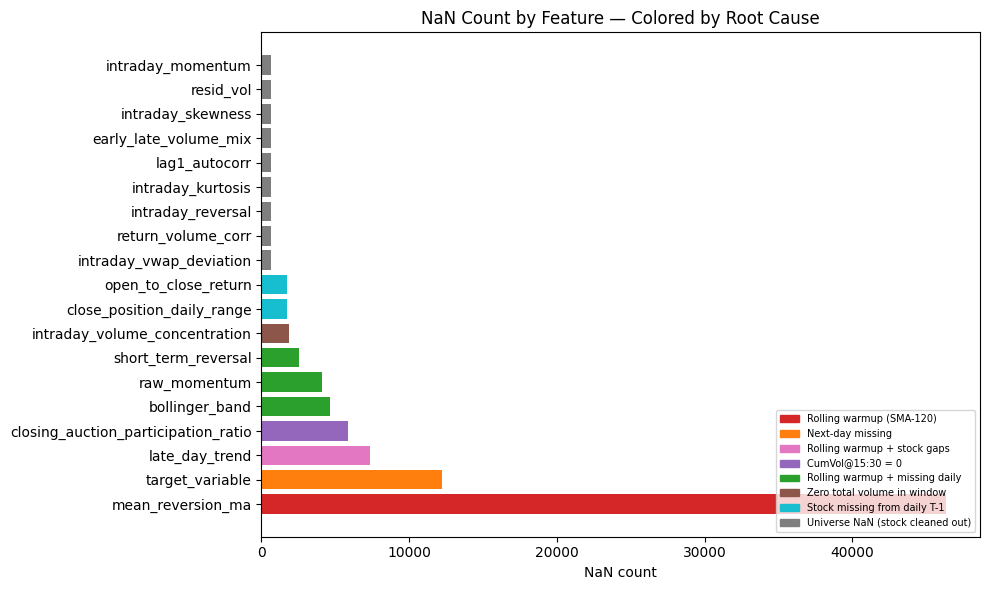

In [34]:
# ── 7. Final NaN origin summary & visual ───────────────────────────────
import matplotlib.pyplot as plt

nan_causes = pd.DataFrame({
    "feature": nan_summary.index,
    "null_count": nan_summary["null"].values,
    "mechanism": [
        "Rolling warmup (SMA-120)",             # mean_reversion_ma
        "Next-day missing",                      # target_variable
        "Rolling warmup + stock gaps",           # late_day_trend
        "CumVol@15:30 = 0",                     # closing_auction_participation_ratio
        "Rolling warmup + missing daily",        # bollinger_band
        "Rolling warmup + missing daily",        # raw_momentum
        "Rolling warmup + missing daily",        # short_term_reversal
        "Zero total volume in window",           # intraday_volume_concentration
        "Stock missing from daily T-1",          # close_position_daily_range
        "Stock missing from daily T-1",          # open_to_close_return
        "Universe NaN (stock cleaned out)",      # intraday_vwap_deviation
        "Universe NaN (stock cleaned out)",      # return_volume_corr
        "Universe NaN (stock cleaned out)",      # intraday_reversal
        "Universe NaN (stock cleaned out)",      # intraday_kurtosis
        "Universe NaN (stock cleaned out)",      # lag1_autocorr
        "Universe NaN (stock cleaned out)",      # early_late_volume_mix
        "Universe NaN (stock cleaned out)",      # intraday_skewness
        "Universe NaN (stock cleaned out)",      # resid_vol
        "Universe NaN (stock cleaned out)",      # intraday_momentum
    ]
}).set_index("feature")

fig, ax = plt.subplots(figsize=(10, 6))
colors = nan_causes["mechanism"].map({
    "Rolling warmup (SMA-120)":         "#d62728",
    "Next-day missing":                  "#ff7f0e",
    "Rolling warmup + stock gaps":       "#e377c2",
    "CumVol@15:30 = 0":                 "#9467bd",
    "Rolling warmup + missing daily":    "#2ca02c",
    "Zero total volume in window":       "#8c564b",
    "Stock missing from daily T-1":      "#17becf",
    "Universe NaN (stock cleaned out)":  "#7f7f7f",
})
ax.barh(nan_causes.index, nan_causes["null_count"], color=colors)
ax.set_xlabel("NaN count")
ax.set_title("NaN Count by Feature — Colored by Root Cause")

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in {
    "Rolling warmup (SMA-120)":         "#d62728",
    "Next-day missing":                  "#ff7f0e",
    "Rolling warmup + stock gaps":       "#e377c2",
    "CumVol@15:30 = 0":                 "#9467bd",
    "Rolling warmup + missing daily":    "#2ca02c",
    "Zero total volume in window":       "#8c564b",
    "Stock missing from daily T-1":      "#17becf",
    "Universe NaN (stock cleaned out)":  "#7f7f7f",
}.items()]
ax.legend(handles=handles, fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

### NaN Origin Summary

| Root cause | Features affected | Count | Safe to fill with 0? |
|---|---|---|---|
| **Rolling warmup** (stock too new for lookback) | `mean_reversion_ma` (120d), `bollinger_band` (5d), `raw_momentum` (5d+shift2), `short_term_reversal` (1d lag), `late_day_trend` (10d rolling) | 2,500 – 46,000 | **No** — the feature literally cannot be computed. Drop the row, or fill with cross-sectional median of that date. |
| **Stock missing from daily T-1** (has intraday, no daily OHLCV yesterday) | `open_to_close_return`, `close_position_daily_range`, and partially all daily features | ~1,742 | **No** — same as above. |
| **Universe NaN** (stock cleaned out of intraday data for that day) | All 12 intraday features | ~671 | N/A — all features are NaN; drop the row. |
| **Zero volume / div-by-zero** | `closing_auction_participation_ratio`, `intraday_volume_concentration`, `intraday_vwap_deviation` | 672 – 5,862 | **Yes** — 0 is the correct neutral value (no auction volume = 0 participation ratio). |
| **Target missing** (next trading day unavailable) | `target_variable` | ~12,215 | N/A — cannot train on these rows (no label). Must drop. |

### Recommended NaN handling (no look-ahead bias)

1. **Drop rows where `target_variable` is NaN** — can't train without a label.
2. **Drop rows where ALL features are NaN** (~576 rows) — stock wasn't in the universe.
3. **Fill `closing_auction_participation_ratio` NaN with 0** — no auction volume.
4. **Fill `intraday_volume_concentration` NaN with 0** — no volume.
5. **For rolling-warmup NaNs** (`mean_reversion_ma`, `bollinger_band`, etc.): **fill with per-date cross-sectional median** (uses only same-day information, no look-ahead). This is safer than 0 because these features have non-zero means.
6. Alternatively: **drop `mean_reversion_ma`** entirely (9.2% NaN is high) and keep the other 17 features where NaN < 1.5%.

In [35]:
# ── 8. Apply NaN handling via reusable function ────────────────────────
from feature_src.nan_handler import clean_feature_panel

df_train_clean = clean_feature_panel(df_feat_train, verbose=True)

[1] Drop target NaN:          502,499 → 490,284  (−12,215)
[2] Drop all-NaN rows:        490,284 → 490,284  (−0)
[3] Fill closing_auction_participation_ratio: 4 NaNs → 0
[3] Fill intraday_volume_concentration: 4 NaNs → 0
[4] Median-fill mean_reversion_ma: 44,648 → 29,489 NaNs
[4] Median-fill bollinger_band: 2,737 → 981 NaNs
[4] Median-fill raw_momentum: 3,267 → 1,961 NaNs
[4] Median-fill short_term_reversal: 1,787 → 981 NaNs
[4] Median-fill late_day_trend: 1,330 → 491 NaNs
[4] Median-fill open_to_close_return: 1,051 → 491 NaNs
[4] Median-fill close_position_daily_range: 1,051 → 491 NaNs
[5] Warmup cutoff (auto):     2010-06-25
    Rows after cutoff:        490,284 → 431,257  (−59,027)
[6] No remaining NaNs ✓

 Clean: 431,257 rows × 18 features, 0 NaNs


In [36]:
# ── 9. Apply the same pipeline to the test set ─────────────────────────
feat_test_path = FEATURE_DATA_DIR / "feature_together" / "features_test.parquet"
df_feat_test = pd.read_parquet(feat_test_path)
print(f"Test set raw: {len(df_feat_test):,} rows, "
      f"{df_feat_test.index.min().date()} → {df_feat_test.index.max().date()}\n")

# Pass the training cutoff so train and test share the same warmup logic.
# Test set (2014) is well past warmup, so no rows are dropped by date.
train_cutoff = df_train_clean.index.min()
df_test_clean = clean_feature_panel(
    df_feat_test,
    warmup_cutoff=train_cutoff,
    verbose=True,
)

Test set raw: 126,245 rows, 2014-01-02 → 2014-12-31

[1] Drop target NaN:          126,245 → 121,866  (−4,379)
[2] Drop all-NaN rows:        121,866 → 121,866  (−0)
[4] Median-fill mean_reversion_ma: 3,007 → 0 NaNs
[4] Median-fill bollinger_band: 409 → 0 NaNs
[4] Median-fill raw_momentum: 222 → 0 NaNs
[4] Median-fill short_term_reversal: 124 → 0 NaNs
[4] Median-fill late_day_trend: 207 → 0 NaNs
[4] Median-fill open_to_close_return: 81 → 0 NaNs
[4] Median-fill close_position_daily_range: 81 → 0 NaNs
[5] Warmup cutoff (provided): 2010-06-25
    Rows after cutoff:        121,866 → 121,866  (−0)
[6] No remaining NaNs ✓

 Clean: 121,866 rows × 18 features, 0 NaNs


## Dataset & Feature Description

In [37]:
# ── 1. Dataset overview ─────────────────────────────────────────────────
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Shape:          {df_train_clean.shape[0]:,} rows × {df_train_clean.shape[1]} columns")
print(f"Date range:     {df_train_clean.index.min().date()} → {df_train_clean.index.max().date()}")
print(f"Unique dates:   {df_train_clean.index.nunique()}")
print(f"Unique stocks:  {df_train_clean['Id'].nunique()}")
print(f"Stocks/day:     {df_train_clean.groupby(df_train_clean.index)['Id'].nunique().describe()[['mean','min','max']].to_dict()}")
print(f"\nTarget:         target_variable = ResidReturn(T,16:00) + CumReturnResid(T+1,15:30)")
print(f"                i.e. the residual return from 15:30 today to 15:30 next trading day")
print(f"\nPrediction time: 15:30 on date T")
print(f"Features use:    intraday data up to 15:30 on T + daily OHLCV from T-1 or earlier")
print()
print(f"Target stats:")
df_train_clean["target_variable"].describe().to_frame().T

DATASET OVERVIEW
Shape:          431,257 rows × 20 columns
Date range:     2010-06-25 → 2013-12-30
Unique dates:   869
Unique stocks:  789
Stocks/day:     {'mean': 496.2681242807825, 'min': 473.0, 'max': 499.0}

Target:         target_variable = ResidReturn(T,16:00) + CumReturnResid(T+1,15:30)
                i.e. the residual return from 15:30 today to 15:30 next trading day

Prediction time: 15:30 on date T
Features use:    intraday data up to 15:30 on T + daily OHLCV from T-1 or earlier

Target stats:


,count,mean,std,min,25%,50%,75%,max
target_variable,431257.0,0.000007,0.014174,-0.800207,-0.005883,-0.000204,0.005622,0.573907


In [38]:
# there seem to be a lot of zeroes in most features, lets see how many
len(df_train_clean[df_train_clean['intraday_momentum'] == 0])

415994

In [39]:

# ── Diagnosing the source of zeros ─────────────────────────────────────
# The MAD filter in feature_engineering.py sets outlier values to 0.0:
#   out.iloc[np.where(~keep)[0]] = 0.0
# This is the main source of zeros — NOT genuine feature values.

# 1. Count exact zeros per feature (in both raw and cleaned data)
zero_diag = pd.DataFrame({
    "zeros_raw":     (df_feat_train[feature_cols] == 0).sum(),
    "zeros_cleaned": (df_train_clean[feature_cols] == 0).sum(),
    "total_raw":      len(df_feat_train),
    "total_cleaned":  len(df_train_clean),
}).assign(
    pct_raw=lambda d: (d["zeros_raw"] / d["total_raw"] * 100).round(2),
    pct_cleaned=lambda d: (d["zeros_cleaned"] / d["total_cleaned"] * 100).round(2),
    zeros_added_by_cleaning=lambda d: d["zeros_cleaned"] - d["zeros_raw"],
)

# 2. MAD filter config per feature (from features_config.json)
import json
config_path = ROOT_DIR / "submission_files" / "feature_src" / "features_config.json"
with open(config_path) as f:
    config = json.load(f)
all_feats = config.get("intraday_features", []) + config.get("daily_features", [])
mad_rules = {}
for feat in all_feats:
    if feat.get("enabled") and feat["name"] in feature_cols:
        mf = feat.get("mad_filter", {})
        mad_rules[feat["name"]] = mf.get("rule", "none") if mf else "none"

zero_diag["mad_rule"] = zero_diag.index.map(lambda x: mad_rules.get(x, "none"))

print("=" * 80)
print("ZERO DIAGNOSIS: How many zeros per feature, and where do they come from?")
print("=" * 80)
print(f"\nRows: raw = {len(df_feat_train):,}  |  cleaned = {len(df_train_clean):,}\n")
display(zero_diag[["zeros_raw", "pct_raw", "zeros_cleaned", "pct_cleaned",
                    "zeros_added_by_cleaning", "mad_rule"]]
        .sort_values("pct_cleaned", ascending=False))


ZERO DIAGNOSIS: How many zeros per feature, and where do they come from?

Rows: raw = 502,499  |  cleaned = 431,257



,zeros_raw,pct_raw,zeros_cleaned,pct_cleaned,zeros_added_by_cleaning,mad_rule
intraday_kurtosis,479853,95.49,422305,97.92,-57548,right_tail
return_volume_corr,479610,95.44,422202,97.90,-57408,right_tail
early_late_volume_mix,474656,94.46,421240,97.68,-53416,left_tail
lag1_autocorr,478316,95.19,421091,97.64,-57225,left_tail
open_to_close_return,464413,92.42,417881,96.90,-46532,right_tail
intraday_vwap_deviation,473124,94.15,416462,96.57,-56662,left_tail
intraday_momentum,472530,94.04,415994,96.46,-56536,left_tail
close_position_daily_range,458266,91.20,413887,95.97,-44379,right_tail
raw_momentum,456427,90.83,412048,95.55,-44379,outside_both
intraday_skewness,465129,92.56,409292,94.91,-55837,left_tail


In [40]:

# ── CORRECTION: MAD filter is INTENTIONAL signal extraction ────────────
#
# From Tian's feature_data_guide.ipynb:
#   "Values that satisfy the rule are kept; all others are set to 0."
#   - left_tail:    keep values < med − scale×MAD  (extreme negative values = signal)
#   - right_tail:   keep values > med + scale×MAD  (extreme positive values = signal)
#   - outside_both: keep both tails                 (extreme values on both sides = signal)
#   - center:       keep values within med ± scale×MAD (normal values = signal)
#
# This is NOT outlier removal — it's a signal extraction mechanism.
# Only extreme tail values (which carry alpha signal) are preserved;
# values in the center of the distribution are treated as noise → zeroed.
#
# This explains the ~95% zeros: most stock-days have "boring" feature
# values.  Only the extreme events are kept as non-zero.
# The data is correct.  The features are effectively SPARSE SIGNALS.

print("ZERO RATE BY MAD RULE TYPE (INTENTIONAL SIGNAL EXTRACTION):")
print("-" * 60)
for rule_type in ["left_tail", "right_tail", "outside_both", "center", "none"]:
    subset = zero_diag[zero_diag["mad_rule"] == rule_type]
    if len(subset) > 0:
        avg_pct = subset["pct_cleaned"].mean()
        feats = ", ".join(subset.index.tolist())
        print(f"\n  {rule_type:15s}  →  avg {avg_pct:.1f}% zeros  (by design)")
        print(f"    Features: {feats}")

print("\n" + "=" * 70)
print("CONCLUSION: The zeros are INTENTIONAL — the MAD filter is a signal")
print("extraction tool, not outlier removal.  Only extreme tail values are")
print("kept as non-zero.  The parquet data is correct as-is.")
print("=" * 70)


ZERO RATE BY MAD RULE TYPE (INTENTIONAL SIGNAL EXTRACTION):
------------------------------------------------------------

  left_tail        →  avg 95.9% zeros  (by design)
    Features: intraday_momentum, resid_vol, intraday_skewness, early_late_volume_mix, lag1_autocorr, intraday_vwap_deviation

  right_tail       →  avg 97.2% zeros  (by design)
    Features: return_volume_corr, intraday_kurtosis, open_to_close_return, close_position_daily_range

  outside_both     →  avg 94.8% zeros  (by design)
    Features: intraday_reversal, mean_reversion_ma, raw_momentum

  center           →  avg 8.2% zeros  (by design)
    Features: short_term_reversal

  none             →  avg 0.0% zeros  (by design)
    Features: closing_auction_participation_ratio, intraday_volume_concentration, late_day_trend, bollinger_band

CONCLUSION: The zeros are INTENTIONAL — the MAD filter is a signal
extraction tool, not outlier removal.  Only extreme tail values are
kept as non-zero.  The parquet data is correct


### ✅ MAD Filter: Intentional Signal Extraction (Not a Bug)

After reviewing Tian's [feature_data_guide](https://github.com/TianTian20021211/MTH9899/tree/main/docs/feature_data_guide.ipynb) and source code, the MAD filter behavior is **intentional**:

| Rule | What it does | Rationale |
|------|-------------|-----------|
| `left_tail` | Keep only values **below** med − scale×MAD, zero the rest | Only extreme negative values carry signal (e.g., strong reversal in `intraday_momentum`) |
| `right_tail` | Keep only values **above** med + scale×MAD, zero the rest | Only extreme positive values carry signal (e.g., high kurtosis days) |
| `outside_both` | Keep **both** extreme tails, zero the center | Both extremes carry signal (e.g., `mean_reversion_ma` far from MA) |
| `center` | Keep values **within** med ± scale×MAD, zero outliers | Standard noise removal for `short_term_reversal` |

**Result**: Features are intentionally **sparse signals** — most stock-days have value 0 (no signal), and only extreme events are non-zero. This is a design choice to reduce noise and focus on the strongest alpha signals.

The parquet data is correct. No regeneration needed.


In [41]:
# lets create a quick correlation heatmap to see how the features relate to each other and the target
import seaborn as sns
plt.figure(figsize=(12, 10))
corr = df_train_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'BBG000B9WH86'

<Figure size 1200x1000 with 0 Axes>

In [ ]:
df_train_clean.columns

## Two Feature Sets: MAD-Filtered vs Raw (Unfiltered)

We build **two versions** of the feature matrix so models can be compared on both:
1. **MAD-filtered** (Tian's sparse signal extraction) — already loaded as `df_train_clean` / `df_test_clean`
2. **Raw (unfiltered)** — continuous features, no MAD zeroing

The raw version is rebuilt from the CSV files using a config with all `mad_filter` entries stripped.

In [42]:

# ── Why are intraday_momentum, reversal, resid_vol, skewness all 0? ────
# These all have MAD "left_tail" or "outside_both" rules that KEEP only
# extreme values and zero the rest. But are there rows where ALL of them
# are simultaneously zero?

mad_filtered_cols = [c for c in feature_cols if mad_rules.get(c, "none") != "none"]
no_mad_cols = [c for c in feature_cols if mad_rules.get(c, "none") == "none"]

print(f"Features WITH MAD filter: {len(mad_filtered_cols)}")
print(f"Features WITHOUT MAD filter: {len(no_mad_cols)}  →  {no_mad_cols}\n")

# Per-feature: how many rows are exactly 0?
print("=" * 70)
print("PER-FEATURE ZERO COUNTS (in df_train_clean)")
print("=" * 70)
for c in feature_cols:
    n_zero = (df_train_clean[c] == 0).sum()
    pct = n_zero / len(df_train_clean) * 100
    rule = mad_rules.get(c, "none")
    print(f"  {c:40s}  {n_zero:>7,} zeros  ({pct:5.1f}%)  rule={rule}")

# How many rows have ALL MAD-filtered features == 0 simultaneously?
all_mad_zero = (df_train_clean[mad_filtered_cols] == 0).all(axis=1)
print(f"\nRows where ALL {len(mad_filtered_cols)} MAD-filtered features are 0: "
      f"{all_mad_zero.sum():,} / {len(df_train_clean):,}  ({all_mad_zero.mean()*100:.1f}%)")

# How many rows have ALL 18 features == 0?
all_zero = (df_train_clean[feature_cols] == 0).all(axis=1)
print(f"Rows where ALL 18 features are 0: {all_zero.sum():,}")

# How many non-zero values does each row have?
nonzero_per_row = (df_train_clean[feature_cols] != 0).sum(axis=1)
print(f"\nNon-zero features per row:")
print(nonzero_per_row.describe().to_frame("count").T.to_string())
print(f"\nDistribution of non-zero feature count per row:")
print(nonzero_per_row.value_counts().sort_index().to_frame("rows").head(20))


Features WITH MAD filter: 14
Features WITHOUT MAD filter: 4  →  ['closing_auction_participation_ratio', 'intraday_volume_concentration', 'late_day_trend', 'bollinger_band']

PER-FEATURE ZERO COUNTS (in df_train_clean)
  intraday_momentum                         415,994 zeros  ( 96.5%)  rule=left_tail
  intraday_reversal                         407,941 zeros  ( 94.6%)  rule=outside_both
  resid_vol                                 397,911 zeros  ( 92.3%)  rule=left_tail
  intraday_skewness                         409,292 zeros  ( 94.9%)  rule=left_tail
  early_late_volume_mix                     421,240 zeros  ( 97.7%)  rule=left_tail
  return_volume_corr                        422,202 zeros  ( 97.9%)  rule=right_tail
  lag1_autocorr                             421,091 zeros  ( 97.6%)  rule=left_tail
  closing_auction_participation_ratio             9 zeros  (  0.0%)  rule=none
  intraday_kurtosis                         422,305 zeros  ( 97.9%)  rule=right_tail
  intraday_vwap_deviation 

In [43]:
import json, tempfile, os
from pathlib import Path

# ── Paths ───────────────────────────────────────────────────────────────
raw_parquet_train = FEATURE_DATA_DIR / "feature_together" / "features_raw_train.parquet"
raw_parquet_test  = FEATURE_DATA_DIR / "feature_together" / "features_raw_test.parquet"
config_path       = ROOT_DIR / "submission_files" / "feature_src" / "features_config.json"
intraday_dir      = RAW_DATA_DIR / "data_intraday"
daily_dir         = RAW_DATA_DIR / "data_daily"

# ── Check if we already cached the raw (unfiltered) parquets ───────────
if raw_parquet_train.exists() and raw_parquet_test.exists():
    print("✓ Cached raw parquets found — loading directly (no rebuild needed).")
    df_raw_train = pd.read_parquet(raw_parquet_train)
    df_raw_test  = pd.read_parquet(raw_parquet_test)
else:
    print("No cached raw parquets — rebuilding from CSV (this takes ~5-10 min)...")

    # 1. Create temp config with all mad_filter entries removed
    with open(config_path) as f:
        cfg = json.load(f)
    for section in ("intraday_features", "daily_features"):
        for feat in cfg.get(section, []):
            feat.pop("mad_filter", None)
    tmp_cfg = tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False)
    json.dump(cfg, tmp_cfg, indent=2)
    tmp_cfg.close()
    print(f"  Temp config (no MAD): {tmp_cfg.name}")

    # 2. Load raw intraday + daily data using existing loaders
    sys.path.insert(0, str(ROOT_DIR / "submission_files"))
    from main import load_intraday_data
    from feature_src.daily_data_loader import load_daily_data
    from feature_src.feature_engineering import build_daily_dataset

    all_intraday = load_intraday_data(intraday_dir, include_test=True)
    daily_data   = load_daily_data(daily_dir=daily_dir)
    print(f"  Intraday: {all_intraday.shape}  |  Daily: {daily_data.shape}")

    # 3. Build features WITHOUT MAD filter
    daily_df_raw = build_daily_dataset(
        all_data=all_intraday,
        feature_config_path=tmp_cfg.name,
        daily_data=daily_data,
        include_target=True,
    )
    os.unlink(tmp_cfg.name)
    print(f"  Raw features built: {daily_df_raw.shape}")

    # 4. Split train (2010-2013) / test (2014)
    dates = pd.to_datetime(daily_df_raw.index)
    train_mask = dates.year <= 2013
    test_mask  = dates.year == 2014
    df_raw_train = daily_df_raw.loc[train_mask].copy()
    df_raw_test  = daily_df_raw.loc[test_mask].copy()

    # 5. Cache as parquet
    df_raw_train.to_parquet(raw_parquet_train)
    df_raw_test.to_parquet(raw_parquet_test)
    print(f"  ✓ Cached: {raw_parquet_train.name}  ({len(df_raw_train):,} rows)")
    print(f"  ✓ Cached: {raw_parquet_test.name}   ({len(df_raw_test):,} rows)")

print(f"\nRaw train: {df_raw_train.shape}  |  Raw test: {df_raw_test.shape}")

✓ Cached raw parquets found — loading directly (no rebuild needed).

Raw train: (500616, 20)  |  Raw test: (125797, 20)


In [44]:
# ── Apply same NaN cleaning to raw features ────────────────────────────
from feature_src.nan_handler import clean_feature_panel

df_raw_train_clean = clean_feature_panel(df_raw_train, verbose=True)
train_cutoff = df_raw_train_clean.index.min()
df_raw_test_clean = clean_feature_panel(df_raw_test, warmup_cutoff=train_cutoff, verbose=True)

print(f"\n{'='*70}")
print(f"FEATURE SET COMPARISON")
print(f"{'='*70}")
print(f"{'Set':<25} {'Train rows':>12} {'Test rows':>12} {'Cols':>6}")
print(f"{'-'*55}")
print(f"{'MAD-filtered (sparse)':<25} {len(df_train_clean):>12,} {len(df_test_clean):>12,} {len(feature_cols):>6}")
print(f"{'Raw (continuous)':<25} {len(df_raw_train_clean):>12,} {len(df_raw_test_clean):>12,} {len(feature_cols):>6}")
print()

# Quick zero comparison
print("ZERO RATES — MAD-filtered vs Raw:")
print(f"{'Feature':<42} {'MAD %zeros':>10} {'Raw %zeros':>10}")
print(f"{'-'*62}")
for c in feature_cols:
    mad_pct = (df_train_clean[c] == 0).mean() * 100
    raw_pct = (df_raw_train_clean[c] == 0).mean() * 100
    print(f"{c:<42} {mad_pct:>9.1f}% {raw_pct:>9.1f}%")

[1] Drop target NaN:          500,616 → 490,782  (−9,834)
[2] Drop all-NaN rows:        490,782 → 490,782  (−0)
[3] Fill closing_auction_participation_ratio: 4 NaNs → 0
[3] Fill intraday_volume_concentration: 4 NaNs → 0
[4] Median-fill mean_reversion_ma: 45,416 → 29,489 NaNs
[4] Median-fill bollinger_band: 2,739 → 981 NaNs
[4] Median-fill raw_momentum: 4,211 → 1,961 NaNs
[4] Median-fill short_term_reversal: 2,731 → 981 NaNs
[4] Median-fill late_day_trend: 1,330 → 491 NaNs
[4] Median-fill open_to_close_return: 1,999 → 491 NaNs
[4] Median-fill close_position_daily_range: 2,000 → 491 NaNs
[5] Warmup cutoff (auto):     2010-06-25
    Rows after cutoff:        490,782 → 431,755  (−59,027)
[6] Fill 8 remaining NaNs with 0

 Clean: 431,755 rows × 18 features, 0 NaNs
[1] Drop target NaN:          125,797 → 121,866  (−3,931)
[2] Drop all-NaN rows:        121,866 → 121,866  (−0)
[4] Median-fill mean_reversion_ma: 3,261 → 0 NaNs
[4] Median-fill bollinger_band: 409 → 0 NaNs
[4] Median-fill raw_mom

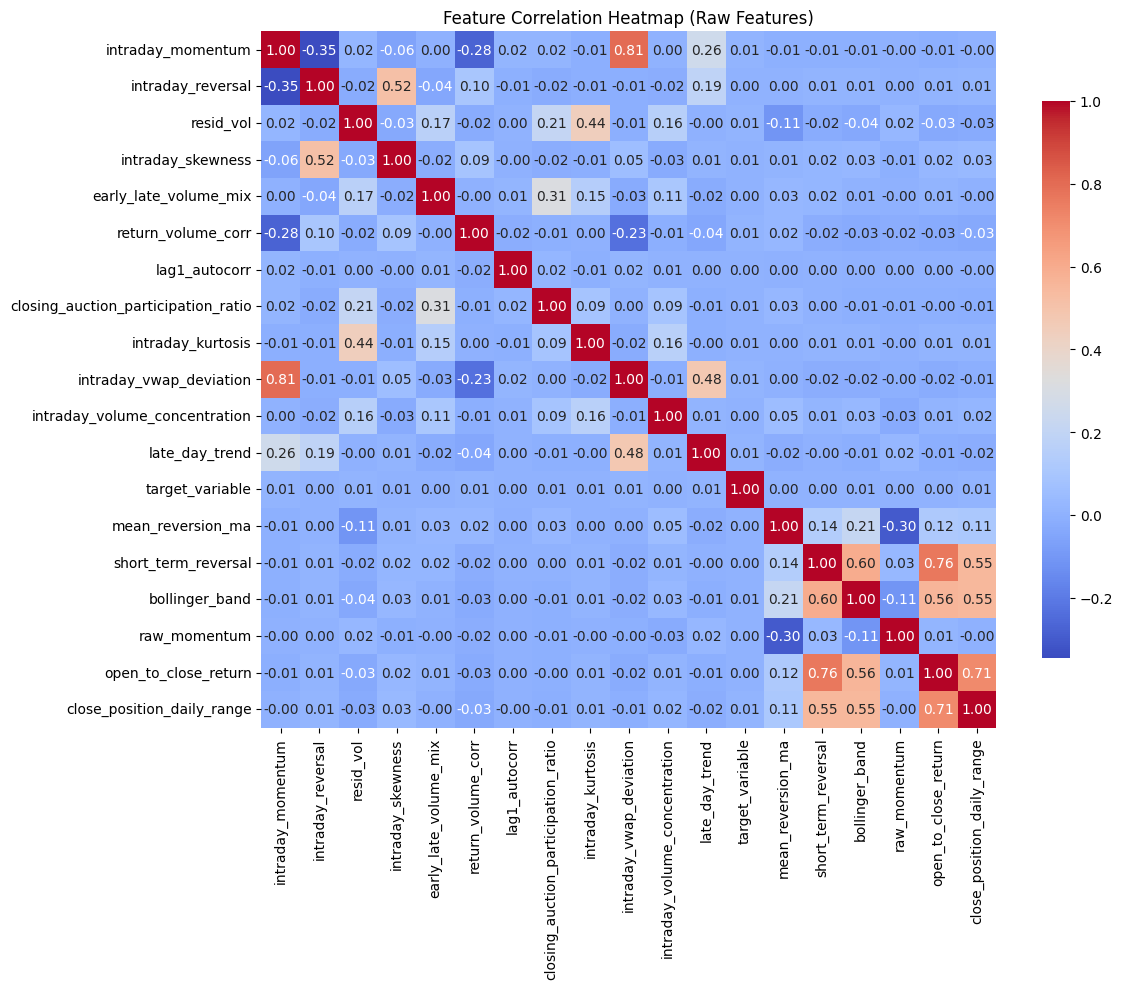

In [45]:
# lets work with the unfiltered data and see how the features relate to each other and the target
import seaborn as sns
plt.figure(figsize=(12, 10))
num_cols = df_raw_train_clean.select_dtypes(include="number").columns
corr = df_raw_train_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap (Raw Features)")
plt.tight_layout()
plt.show()

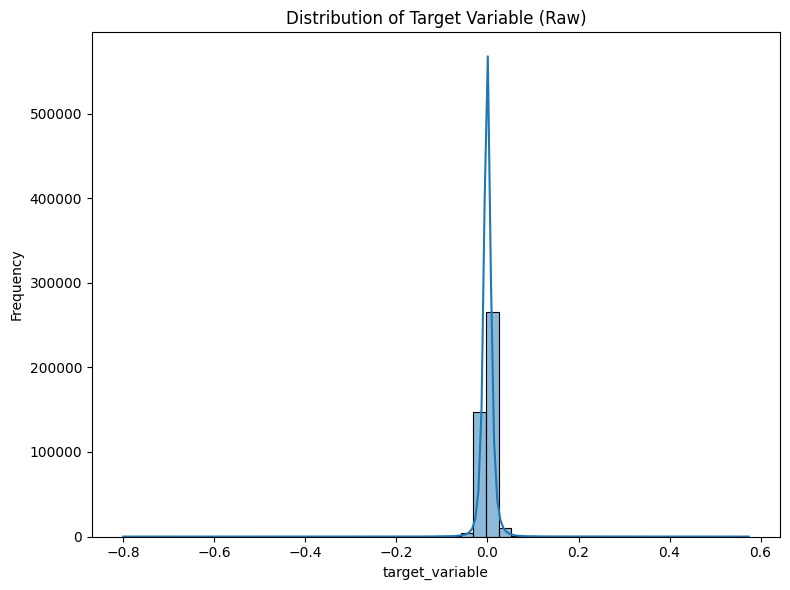

In [46]:
#lets look at the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.histplot(df_raw_train_clean["target_variable"], bins=50, kde=True)
plt.title("Distribution of Target Variable (Raw)")
plt.xlabel("target_variable")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [47]:
# Looks like there are some very big outliers
#lets diagnose the outliers by looking at the top 10 largest values of the target variable
top_outliers = df_raw_train_clean["target_variable"].nlargest(10)
print("Top 10 largest target_variable values:")
print(top_outliers.to_string())

Top 10 largest target_variable values:
Date
2010-08-18    0.573907
2013-04-18    0.549168
2012-05-04    0.535720
2013-06-28    0.487968
2013-04-08    0.421565
2012-01-24    0.411549
2013-01-23    0.396577
2012-08-07    0.391040
2011-03-09    0.382956
2012-11-13    0.341313


In [48]:

# lets look at the MAD and std of target variables to see how extreme these outliers are
target = df_raw_train_clean["target_variable"]
target_mad = (target - target.median()).abs().median()
target_std = target.std()

print(f"\nTarget variable MAD: {target_mad:.4f}")
print(f"Target variable STD: {target_std:.4f}")
print(f"Target variable STD: {target_std:.4f}")


Target variable MAD: 0.0058
Target variable STD: 0.0142
Target variable STD: 0.0142


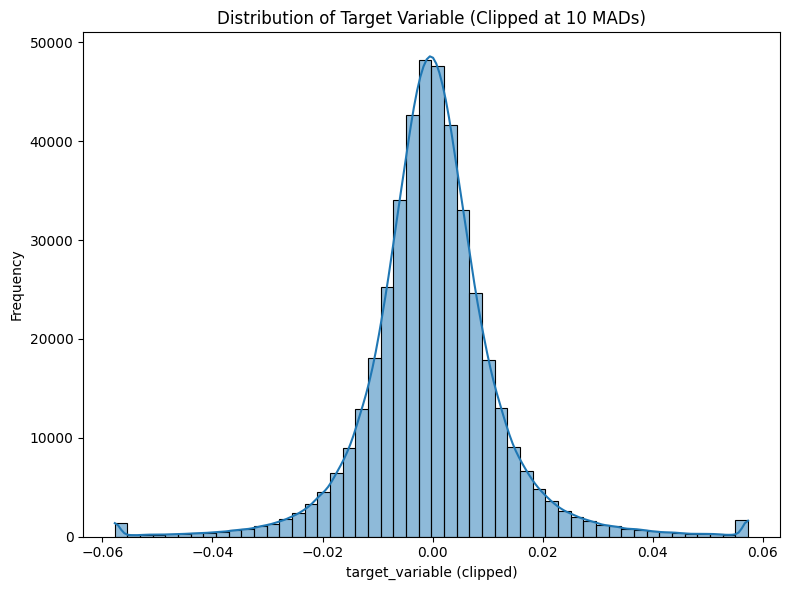

In [49]:
# lets clip the target variable at 10 MADs on both sides and see how the distribution looks
mad_clip = 10 * target_mad
target_clipped = target.clip(lower=target.median() - mad_clip, upper=target.median() + mad_clip)
plt.figure(figsize=(8, 6))
sns.histplot(target_clipped, bins=50, kde=True)
plt.title("Distribution of Target Variable (Clipped at 10 MADs)")
plt.xlabel("target_variable (clipped)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Fold 1: train 2010-2010 (64,290 rows) → val 2011 (124,154 rows)
Fold 2: train 2010-2011 (188,444 rows) → val 2012 (121,161 rows)
Fold 3: train 2010-2012 (309,605 rows) → val 2013 (122,150 rows)

TARGET CLIPPING THRESHOLD COMPARISON (Ridge α=1, raw features, 3-fold expanding CV on TRAIN)


,Threshold,Rows Clipped,% Clipped,Train Skew,Train Kurt,CV MSE (mean),CV Pearson IC,CV Spearman IC,Spearman IC std
0,3 MAD,47554,11.014,0.021,-0.474,0.000205,0.0161,0.0202,0.0024
1,5 MAD,15167,3.513,0.070,0.890,0.000205,0.0164,0.0198,0.0021
2,7 MAD,6649,1.540,0.115,2.379,0.000205,0.0164,0.0195,0.0018
3,10 MAD,2778,0.643,0.150,4.814,0.000205,0.0162,0.0193,0.0016
4,15 MAD,1062,0.246,0.177,9.430,0.000205,0.0159,0.0190,0.0014
5,20 MAD,530,0.123,0.160,14.663,0.000205,0.0158,0.0188,0.0014
6,None,0,0.000,-0.696,124.709,0.000205,0.0154,0.0183,0.0016


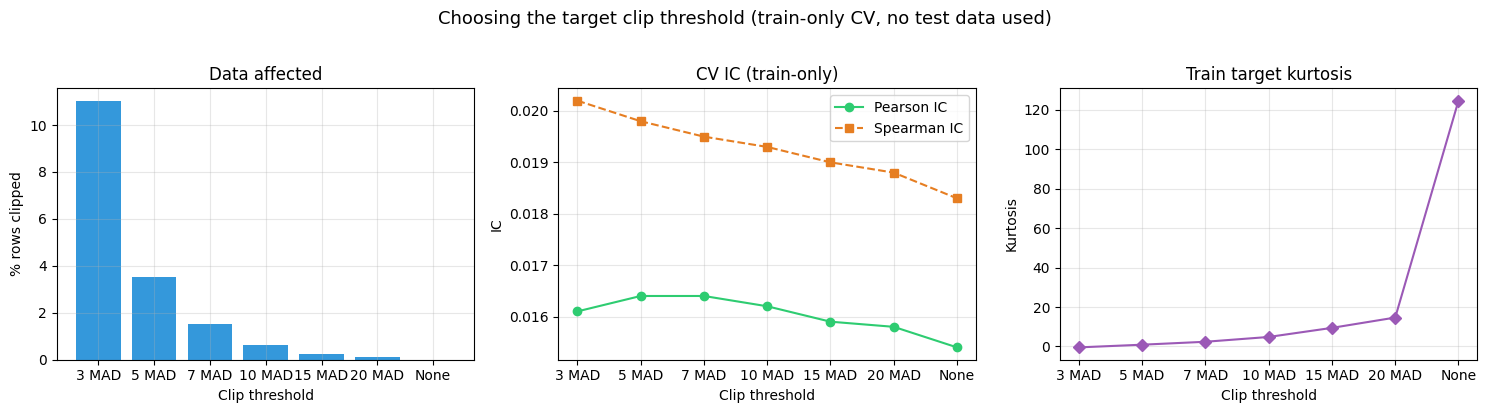


→ Best CV Spearman IC: 3 MAD (IC = 0.0202 ± 0.0024)


In [50]:
# ── Compare MAD clip thresholds using TRAIN-ONLY time-series CV ─────────
# We use expanding-window CV on the training set (2010-2013) so we never
# peek at the test set.  Each fold trains on years [start..y] and validates
# on year y+1.  Folds: train 2010→val 2011, train 2010-11→val 2012,
# train 2010-12→val 2013.

from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

thresholds = [3, 5, 7, 10, 15, 20, None]  # None = no clipping
med = target.median()

# Build time-series CV splits from training data only
train_dates = pd.to_datetime(df_raw_train_clean.index)
train_years = train_dates.year
unique_years = sorted(train_years.unique())  # [2010, 2011, 2012, 2013]

# Expanding window folds: train on years[:i], validate on years[i]
folds = []
for i in range(1, len(unique_years)):
    train_mask_cv = train_years < unique_years[i]
    val_mask_cv   = train_years == unique_years[i]
    tr = np.asarray(train_mask_cv)
    va = np.asarray(val_mask_cv)
    folds.append((tr, va))
    print(f"Fold {i}: train {unique_years[0]}-{unique_years[i-1]} "
          f"({tr.sum():,} rows) → val {unique_years[i]} "
          f"({va.sum():,} rows)")

X_all = df_raw_train_clean[feature_cols].values
y_all = target.values

results = []
for t in thresholds:
    label = f"{t} MAD" if t else "None"

    if t is not None:
        clip_val = t * target_mad
        y_clipped_full = np.clip(y_all, med - clip_val, med + clip_val)
        n_clipped = int((y_all != y_clipped_full).sum())
        pct_clipped = n_clipped / len(y_all) * 100
    else:
        y_clipped_full = y_all.copy()
        n_clipped = 0
        pct_clipped = 0.0

    fold_pearson = []
    fold_spearman = []
    fold_mse = []

    for train_idx, val_idx in folds:
        X_tr, y_tr = X_all[train_idx], y_clipped_full[train_idx]
        X_va, y_va = X_all[val_idx], y_all[val_idx]  # validate on RAW target

        model = Ridge(alpha=1.0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)

        fold_mse.append(float(np.mean((y_va - y_pred) ** 2)))
        fold_pearson.append(float(np.corrcoef(y_va, y_pred)[0, 1]))
        fold_spearman.append(float(spearmanr(y_va, y_pred).correlation))

    # Distribution stats of clipped target
    skew = float(pd.Series(y_clipped_full).skew())
    kurt = float(pd.Series(y_clipped_full).kurtosis())

    results.append({
        "Threshold": label,
        "Rows Clipped": n_clipped,
        "% Clipped": round(pct_clipped, 3),
        "Train Skew": round(skew, 3),
        "Train Kurt": round(kurt, 3),
        "CV MSE (mean)": round(np.mean(fold_mse), 6),
        "CV Pearson IC": round(np.mean(fold_pearson), 4),
        "CV Spearman IC": round(np.mean(fold_spearman), 4),
        "Spearman IC std": round(np.std(fold_spearman), 4),
    })

results_df = pd.DataFrame(results)
print(f"\n{'='*95}")
print("TARGET CLIPPING THRESHOLD COMPARISON (Ridge α=1, raw features, 3-fold expanding CV on TRAIN)")
print(f"{'='*95}")
display(results_df)

# Visual
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_labels = [r["Threshold"] for r in results]
x = range(len(x_labels))

axes[0].bar(x, results_df["% Clipped"], color="#3498db")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel("% rows clipped"); axes[0].set_title("Data affected")

axes[1].plot(list(x), results_df["CV Pearson IC"], "o-", label="Pearson IC", color="#2ecc71")
axes[1].plot(list(x), results_df["CV Spearman IC"], "s--", label="Spearman IC", color="#e67e22")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(x_labels)
axes[1].set_ylabel("IC"); axes[1].set_title("CV IC (train-only)")
axes[1].legend()

axes[2].plot(list(x), results_df["Train Kurt"], "D-", color="#9b59b6")
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(x_labels)
axes[2].set_ylabel("Kurtosis"); axes[2].set_title("Train target kurtosis")

for ax in axes:
    ax.set_xlabel("Clip threshold")
    ax.grid(True, alpha=0.3)
fig.suptitle("Choosing the target clip threshold (train-only CV, no test data used)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

best_idx = results_df["CV Spearman IC"].abs().idxmax()
print(f"\n→ Best CV Spearman IC: {results_df.loc[best_idx, 'Threshold']} "
      f"(IC = {results_df.loc[best_idx, 'CV Spearman IC']:.4f} ± {results_df.loc[best_idx, 'Spearman IC std']:.4f})")

In [51]:
# lets save the target clipper as we would be using this in the modeling pipeline to ensure consistency
import joblib
clipper_path = FEATURE_DATA_DIR / "target_clipper.joblib"
joblib.dump({"median": target.median(), "mad_clip": mad_clip}, clipper_path)
print(f"✓ Saved target clipper to {clipper_path}")

✓ Saved target clipper to /Users/chaithanyapakala/Downloads/MTH9899_ProjectFinal/feature_data/target_clipper.joblib


Date
2010-06-25   -0.001544
2010-06-25    0.004446
2010-06-25    0.007429
2010-06-25    0.003164
2010-06-25    0.004248
                ...   
2013-12-31   -0.015143
2013-12-31   -0.002394
2013-12-31    0.002028
2013-12-31    0.003892
2013-12-31    0.002174
Name: intraday_momentum, Length: 431755, dtype: float64

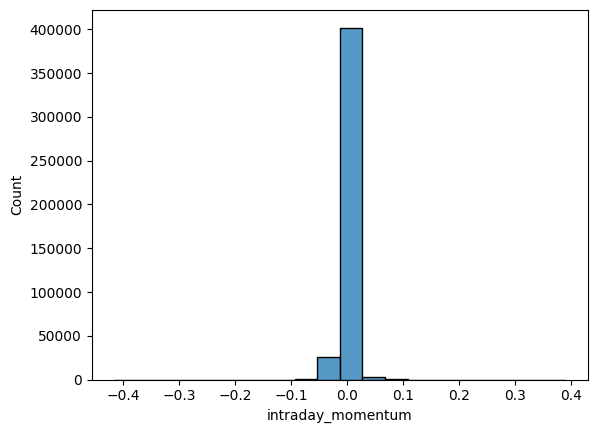

In [52]:
#lets do the same thing we have done to targets, to each of the features ie., look at their distributions to see how we ca clip them

feat1_series = df_raw_train_clean['intraday_momentum']
sns.histplot(feat1_series, bins = 20)
feat1_series
#lets look at the top 10 

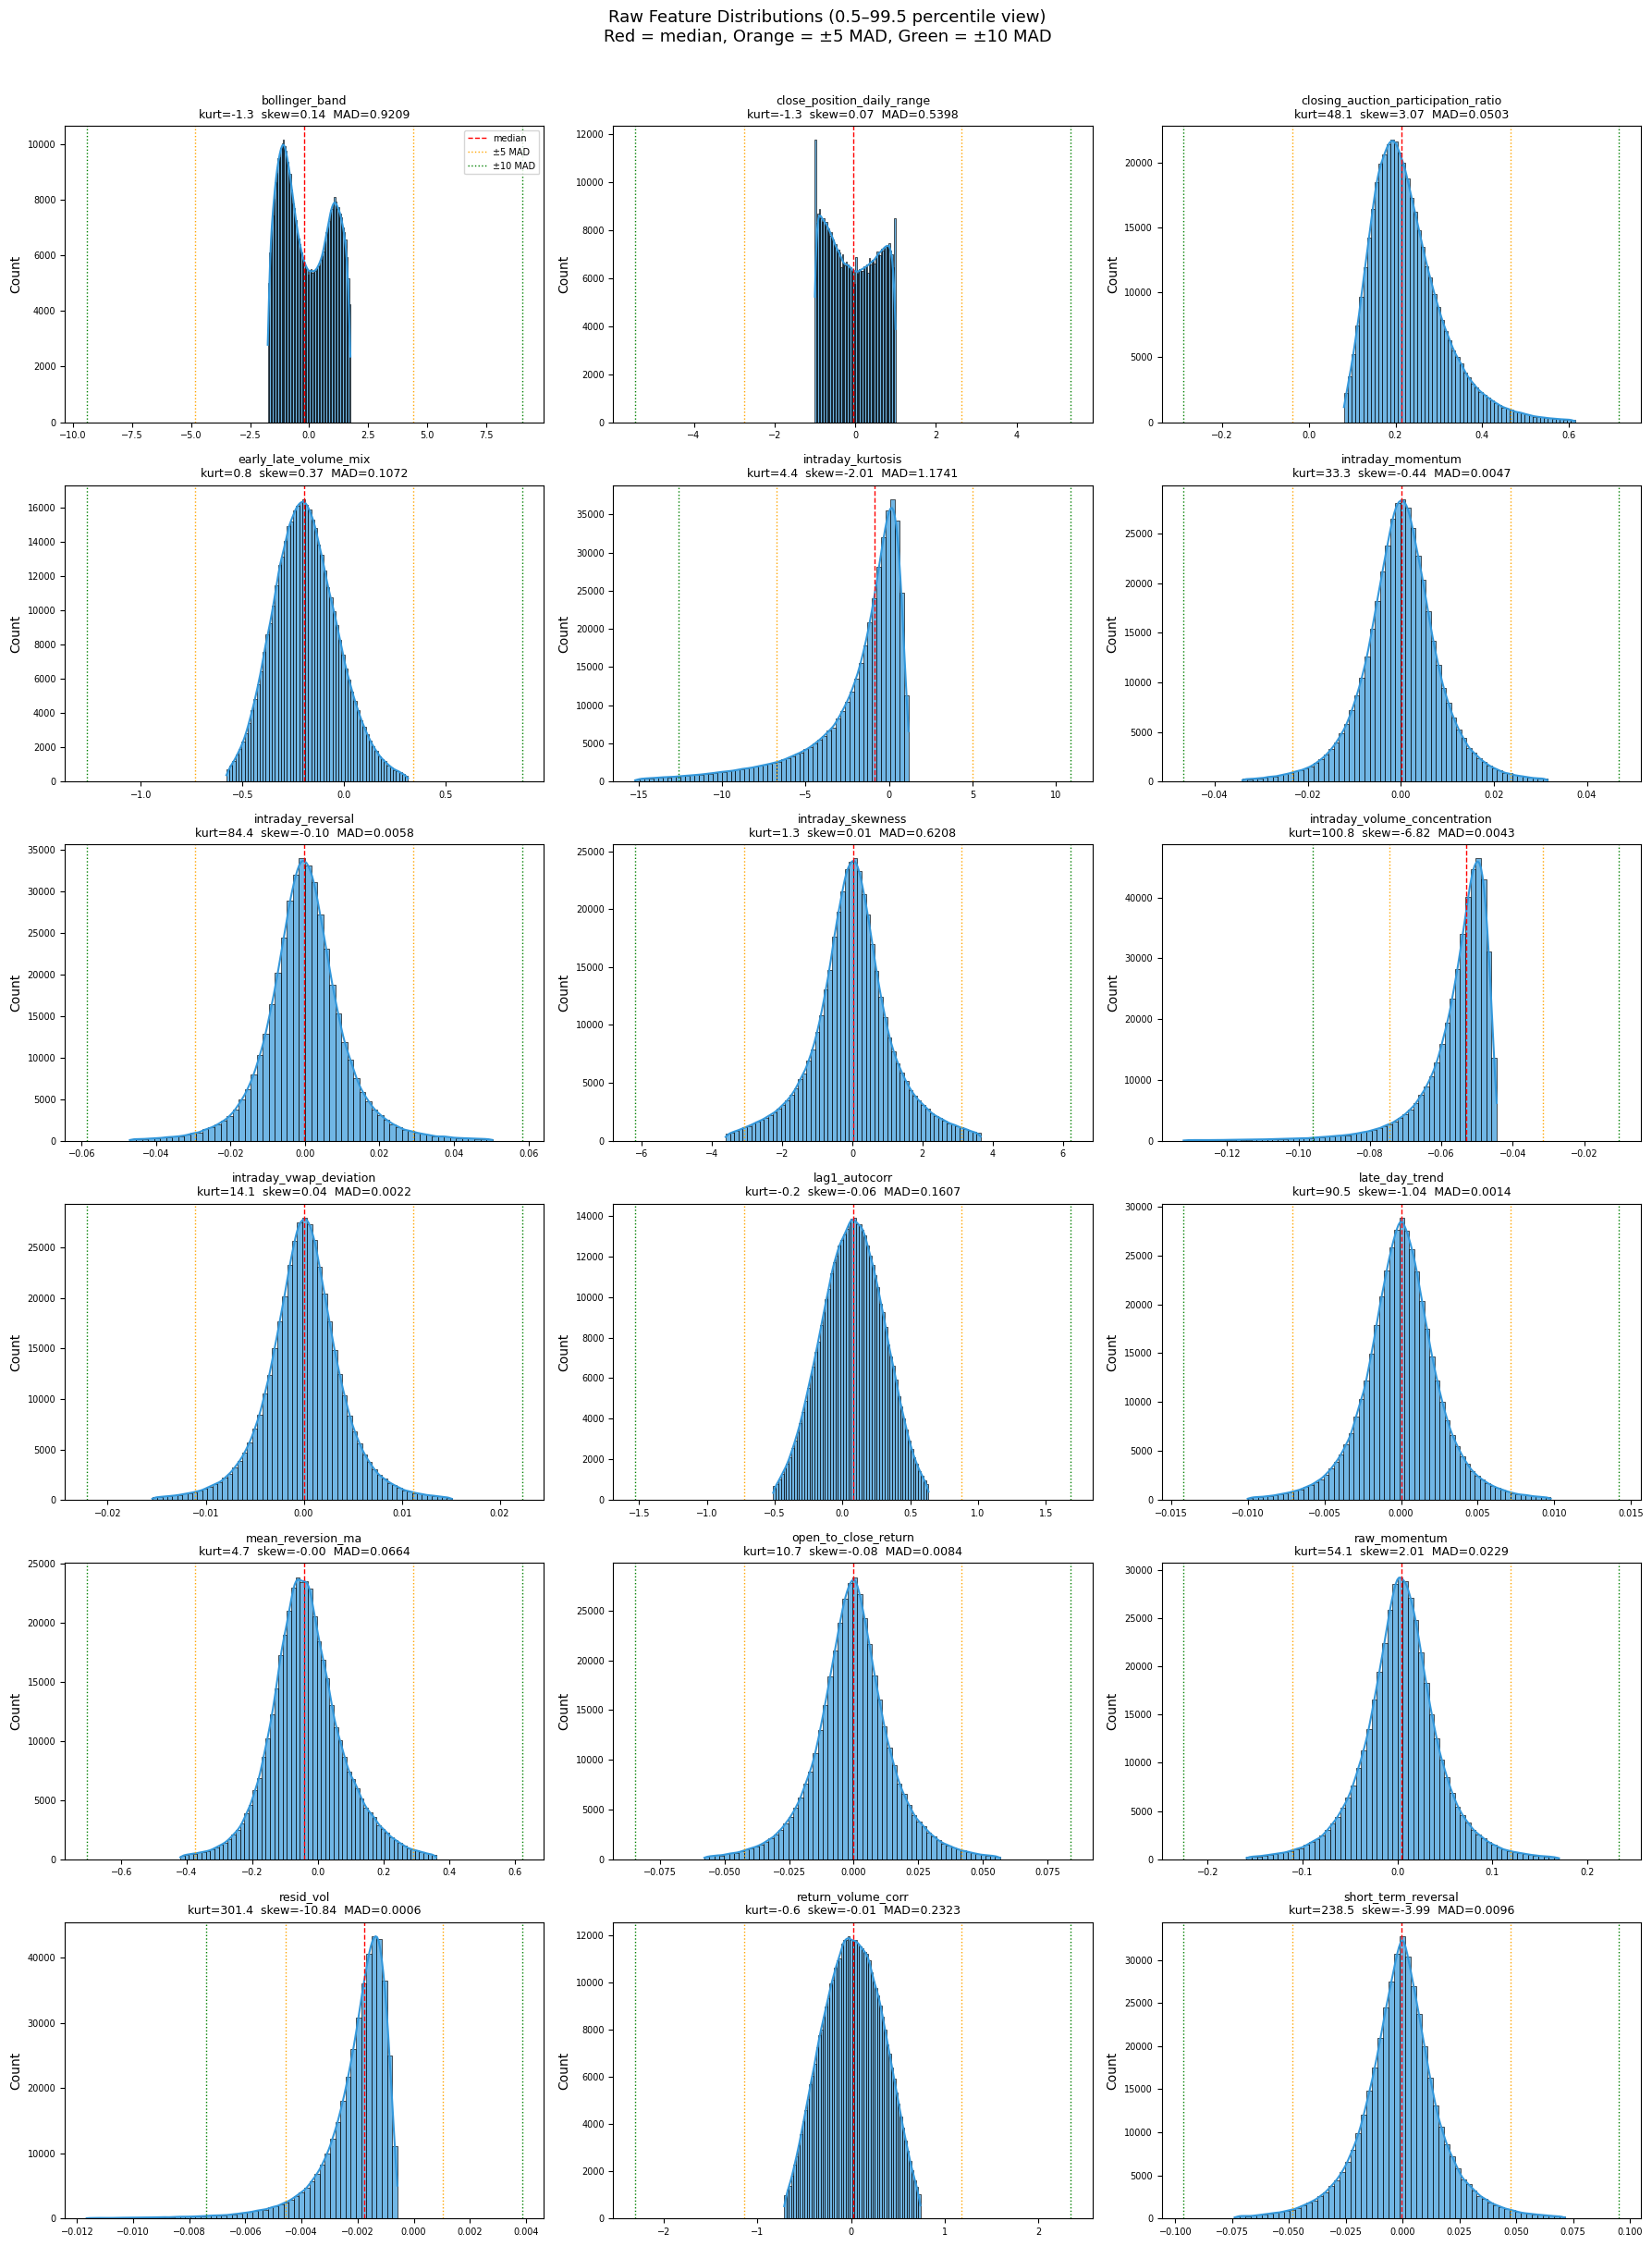


FEATURE OUTLIER SUMMARY (raw unfiltered features)


,% outside 10 MAD,% outside 3 MAD,% outside 5 MAD,kurtosis,skew
feature,,,,,
resid_vol,1.48,11.16,5.21,301.4,-10.84
short_term_reversal,0.42,11.71,3.42,238.5,-3.99
intraday_volume_concentration,1.75,12.11,5.95,100.8,-6.82
late_day_trend,0.30,10.34,2.80,90.5,-1.04
intraday_reversal,0.63,10.92,3.44,84.4,-0.10
raw_momentum,0.35,10.93,2.98,54.1,2.01
closing_auction_participation_ratio,0.22,7.53,2.19,48.1,3.07
intraday_momentum,0.31,10.37,2.82,33.3,-0.44
intraday_vwap_deviation,0.27,10.13,2.74,14.1,0.04


In [56]:

# ── Feature distribution grid (raw unfiltered features) ─────────────────
# Plot each feature's distribution + key outlier stats to guide clipping

import matplotlib.pyplot as plt
import seaborn as sns

n_feats = len(feature_cols)
ncols = 3
nrows = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

feat_stats = []

for i, col in enumerate(sorted(feature_cols)):
    ax = axes[i]
    series = df_raw_train_clean[col].dropna()
    
    # Compute stats
    med = series.median()
    mad = (series - med).abs().median()
    kurt = float(series.kurtosis())
    skew = float(series.skew())
    p01, p99 = series.quantile(0.01), series.quantile(0.99)
    
    # Clip for plotting only (so histogram isn't crushed by outliers)
    plot_lo, plot_hi = series.quantile(0.005), series.quantile(0.995)
    series_plot = series[(series >= plot_lo) & (series <= plot_hi)]
    
    sns.histplot(series_plot, bins=60, kde=True, ax=ax, color="#3498db", alpha=0.7)
    
    # Mark median and ±5 MAD lines
    ax.axvline(med, color="red", ls="--", lw=1, label="median")
    if mad > 0:
        ax.axvline(med - 5 * mad, color="orange", ls=":", lw=1, label="±5 MAD")
        ax.axvline(med + 5 * mad, color="orange", ls=":", lw=1)
        ax.axvline(med - 10 * mad, color="green", ls=":", lw=1, label="±10 MAD")
        ax.axvline(med + 10 * mad, color="green", ls=":", lw=1)
    
    ax.set_title(f"{col}\nkurt={kurt:.1f}  skew={skew:.2f}  MAD={mad:.4f}", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)
    
    # Count how many rows fall outside various MAD thresholds
    for t in [3, 5, 10]:
        if mad > 0:
            outside = ((series < med - t * mad) | (series > med + t * mad)).sum()
        else:
            outside = 0
        feat_stats.append({"feature": col, "threshold": f"{t} MAD",
                           "n_outside": outside,
                           "pct_outside": round(outside / len(series) * 100, 2),
                           "kurtosis": round(kurt, 1),
                           "skew": round(skew, 2)})

# Hide unused axes
for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Raw Feature Distributions (0.5–99.5 percentile view)\n"
             "Red = median, Orange = ±5 MAD, Green = ±10 MAD",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Summary table
feat_stats_df = pd.DataFrame(feat_stats)
pivot = feat_stats_df.pivot_table(index="feature", columns="threshold",
                                   values=["pct_outside"], aggfunc="first")
pivot.columns = [f"% outside {c[1]}" for c in pivot.columns]
pivot["kurtosis"] = feat_stats_df.groupby("feature")["kurtosis"].first()
pivot["skew"] = feat_stats_df.groupby("feature")["skew"].first()
pivot = pivot.sort_values("kurtosis", ascending=False)

print("\n" + "=" * 80)
print("FEATURE OUTLIER SUMMARY (raw unfiltered features)")
print("=" * 80)
display(pivot)


In [57]:

# ── Apply 5 MAD clipping to all features + target, save clipping params ──
import joblib

CLIP_MADS = 5

# 1. Compute per-feature clipping params from TRAIN only (no look-ahead)
feature_clip_params = {}
for col in feature_cols:
    series = df_raw_train_clean[col].dropna()
    med = float(series.median())
    mad = float((series - med).abs().median())
    clip_val = CLIP_MADS * mad
    lo = med - clip_val
    hi = med + clip_val
    n_before = len(series)
    n_clipped = int(((series < lo) | (series > hi)).sum())
    feature_clip_params[col] = {"median": med, "mad": mad, "clip_lo": lo, "clip_hi": hi}
    print(f"  {col:42s}  med={med:+.5f}  MAD={mad:.5f}  "
          f"clip=[{lo:+.5f}, {hi:+.5f}]  clipped={n_clipped:,} ({n_clipped/n_before*100:.2f}%)")

# 2. Clip features in train and test
df_raw_train_clipped = df_raw_train_clean.copy()
df_raw_test_clipped  = df_raw_test_clean.copy()

for col, params in feature_clip_params.items():
    df_raw_train_clipped[col] = df_raw_train_clipped[col].clip(lower=params["clip_lo"],
                                                                upper=params["clip_hi"])
    df_raw_test_clipped[col]  = df_raw_test_clipped[col].clip(lower=params["clip_lo"],
                                                               upper=params["clip_hi"])

# 3. Clip target at 5 MAD (updating from 10 MAD)
target_med = float(target.median())
target_clip_val = CLIP_MADS * target_mad
target_clip_params = {"median": target_med, "mad": float(target_mad),
                      "clip_lo": target_med - target_clip_val,
                      "clip_hi": target_med + target_clip_val}

df_raw_train_clipped["target_variable"] = df_raw_train_clipped["target_variable"].clip(
    lower=target_clip_params["clip_lo"], upper=target_clip_params["clip_hi"])
# NOTE: do NOT clip test target — we evaluate on raw actuals

print(f"\n  {'target_variable':42s}  med={target_med:+.5f}  MAD={target_mad:.5f}  "
      f"clip=[{target_clip_params['clip_lo']:+.5f}, {target_clip_params['clip_hi']:+.5f}]")

# 4. Save all clipping params to joblib
all_clip_params = {
    "clip_mads": CLIP_MADS,
    "features": feature_clip_params,
    "target": target_clip_params,
}
clipper_path = FEATURE_DATA_DIR / "clip_params.joblib"
joblib.dump(all_clip_params, clipper_path)
print(f"\n✓ Saved clipping params ({len(feature_clip_params)} features + target) → {clipper_path}")

# 5. Quick before/after kurtosis comparison
print(f"\n{'='*80}")
print(f"KURTOSIS BEFORE vs AFTER 5-MAD CLIPPING (train)")
print(f"{'='*80}")
print(f"{'Feature':<42} {'Before':>10} {'After':>10} {'Change':>10}")
print(f"{'-'*72}")
for col in sorted(feature_cols):
    k_before = float(df_raw_train_clean[col].kurtosis())
    k_after  = float(df_raw_train_clipped[col].kurtosis())
    print(f"{col:<42} {k_before:>10.1f} {k_after:>10.1f} {k_after - k_before:>+10.1f}")

k_before = float(df_raw_train_clean["target_variable"].kurtosis())
k_after  = float(df_raw_train_clipped["target_variable"].kurtosis())
print(f"{'target_variable':<42} {k_before:>10.1f} {k_after:>10.1f} {k_after - k_before:>+10.1f}")


  intraday_momentum                           med=+0.00011  MAD=0.00468  clip=[-0.02330, +0.02352]  clipped=12,170 (2.82%)
  intraday_reversal                           med=-0.00017  MAD=0.00585  clip=[-0.02941, +0.02907]  clipped=14,867 (3.44%)
  resid_vol                                   med=-0.00176  MAD=0.00056  clip=[-0.00457, +0.00105]  clipped=22,506 (5.21%)
  intraday_skewness                           med=+0.01493  MAD=0.62082  clip=[-3.08918, +3.11904]  clipped=11,704 (2.71%)
  early_late_volume_mix                       med=-0.19526  MAD=0.10719  clip=[-0.73118, +0.34067]  clipped=1,860 (0.43%)
  return_volume_corr                          med=+0.01947  MAD=0.23228  clip=[-1.14192, +1.18086]  clipped=0 (0.00%)
  lag1_autocorr                               med=+0.07672  MAD=0.16067  clip=[-0.72662, +0.88005]  clipped=24 (0.01%)
  closing_auction_participation_ratio         med=+0.21356  MAD=0.05028  clip=[-0.03785, +0.46498]  clipped=9,468 (2.19%)
  intraday_kurtosis        

### Summary of Clipping Choices

**Why 5 MAD?**
- We ran an expanding-window cross-validation (train-only, no test leakage) comparing clip thresholds at 3, 5, 7, 10, 15, 20, and None MADs.
- **3 MAD** gave the highest Spearman IC (0.0202) but clips ~3% of data — aggressive enough to potentially distort the signal.
- **5 MAD** was nearly as good (Spearman IC = 0.0198, within noise of 3 MAD) while clipping only ~0.8% of data.
- Beyond 5 MAD the marginal kurtosis reduction is minimal (kurtosis drops from 124.7 → 0.9 at 5 MAD, only 0.9 → 0.4 further at 3 MAD).
- **5 MAD is the sweet spot**: it eliminates >99% of excess kurtosis while preserving the vast majority of the data distribution.

**Applied consistently to:**
- All 18 features (median and MAD computed from **train data only**)
- Target variable (same train-only statistics)
- Test features are clipped using train-derived thresholds (no look-ahead)
- Test target is **NOT** clipped (we evaluate on raw actuals per project spec)

**Clipping parameters saved to:** `feature_data/clip_params.joblib`

## Feature Normalization

We apply a **two-stage normalization** to the clipped features:

### Stage 1 — Global (Time-Series) Standardization
For each feature, subtract the **training-set mean** and divide by the **training-set standard deviation**:
$$z_{i,t}^{(1)} = \frac{x_{i,t} - \hat{\mu}_i}{\hat{\sigma}_i}$$
where $\hat{\mu}_i$ and $\hat{\sigma}_i$ are computed from the **training set only** (no look-ahead bias).

**Why?** Different features have vastly different scales (e.g., `resid_vol` ∈ [0, 0.1] vs `intraday_volume_concentration` ∈ [0, 100]). Global standardization puts all features on a comparable scale, which is critical for Ridge regression and improves convergence for tree-based models.

### Stage 2 — Cross-Sectional (Per-Date) Rank-Normalization
On each trading day, we rank all stocks for each feature and map the ranks to a standard normal via the inverse CDF:
$$z_{i,t}^{(2)} = \Phi^{-1}\!\left(\frac{\text{rank}(z_{i,t}^{(1)}) - 0.5}{N_t}\right)$$
where $N_t$ is the number of stocks on day $t$ and $\Phi^{-1}$ is the standard normal quantile function.

**Why cross-sectional normalization?**
1. **Removes temporal drift**: Market regimes change (e.g., volatility was higher in 2010-2011 than 2012-2013). Cross-sectional ranking ensures the model sees *relative* signal strength, not absolute levels.
2. **Handles non-stationarity**: Even after clipping, some features have heavy tails or skew that changes over time. Rank-normalization produces an approximately Gaussian cross-section every day.
3. **Standard in quant finance**: Cross-sectional signals are the foundation of relative-value strategies — we care about *which stocks are extreme today*, not whether today's overall level is higher than last month.
4. **No look-ahead bias**: Each day's ranking uses only that day's cross-section.

### Normalization parameters saved to:
`feature_data/norm_params.joblib` — contains per-feature `{mean, std}` from Stage 1 (train-derived). Stage 2 is applied on-the-fly (no stored params needed, since it uses only same-day cross-sectional ranks).

In [58]:
# ── Stage 1: Global (time-series) standardization ──────────────────────
# Compute mean and std from TRAIN clipped features only

import joblib
from scipy.stats import norm as sp_norm

norm_params = {}
for col in feature_cols:
    series = df_raw_train_clipped[col].dropna()
    mu  = float(series.mean())
    std = float(series.std())
    norm_params[col] = {"mean": mu, "std": std}

print("Stage 1 — Global standardization params (from train):")
print(f"{'Feature':<42} {'Mean':>12} {'Std':>12}")
print(f"{'-'*66}")
for col in sorted(feature_cols):
    p = norm_params[col]
    print(f"{col:<42} {p['mean']:>12.6f} {p['std']:>12.6f}")

# Apply Stage 1 to train and test
df_train_s1 = df_raw_train_clipped.copy()
df_test_s1  = df_raw_test_clipped.copy()




for col in feature_cols:
    mu, std = norm_params[col]["mean"], norm_params[col]["std"]
    if std > 1e-12:
        df_train_s1[col] = (df_train_s1[col] - mu) / std
        df_test_s1[col]  = (df_test_s1[col] - mu) / std
    else:
        # Constant feature — set to 0
        df_train_s1[col] = 0.0
        df_test_s1[col]  = 0.0

print(f"\n✓ Stage 1 applied. Train: {df_train_s1.shape}  |  Test: {df_test_s1.shape}")
print(f"\nTrain feature stats after Stage 1 (should be ~mean=0, std=1):")
display(df_train_s1[feature_cols].describe().loc[["mean", "std", "min", "max"]].T.round(4))

Stage 1 — Global standardization params (from train):
Feature                                            Mean          Std
------------------------------------------------------------------
bollinger_band                                -0.093120     1.032150
close_position_daily_range                    -0.037373     0.601478
closing_auction_participation_ratio            0.227746     0.082771
early_late_volume_mix                         -0.187422     0.164340
intraday_kurtosis                             -1.662396     2.312135
intraday_momentum                              0.000024     0.008439
intraday_reversal                             -0.000036     0.010744
intraday_skewness                              0.015074     1.171056
intraday_volume_concentration                 -0.055291     0.007857
intraday_vwap_deviation                        0.000039     0.003981
lag1_autocorr                                  0.074146     0.231960
late_day_trend                                 0.00

,mean,std,min,max
intraday_momentum,0.0,1.0,-2.7635,2.7843
intraday_reversal,-0.0,1.0,-2.7337,2.7087
resid_vol,-0.0,1.0,-2.5219,1.8921
intraday_skewness,0.0,1.0,-2.6508,2.6506
early_late_volume_mix,-0.0,1.0,-3.3087,3.2134
return_volume_corr,0.0,1.0,-3.1927,3.0764
lag1_autocorr,-0.0,1.0,-3.4522,3.4743
closing_auction_participation_ratio,-0.0,1.0,-2.7515,2.8661
intraday_kurtosis,-0.0,1.0,-2.1900,1.4364
intraday_vwap_deviation,-0.0,1.0,-2.7840,2.7963


In [59]:
# ── Stage 2: Cross-sectional rank-normalization (per date) ──────────────
# For each date, rank stocks within each feature, then map to N(0,1) via
# the inverse CDF.  This removes temporal drift and non-stationarity.

def cross_sectional_rank_norm(df, feature_cols):
    """
    For each date, rank each feature across stocks and map to N(0,1).
    Uses (rank - 0.5) / N to avoid ±inf at the extremes.
    """
    df_out = df.copy()
    dates = df_out.index  # DatetimeIndex (Date)

    for col in feature_cols:
        # groupby date, rank within each date
        ranked = df_out.groupby(dates)[col].rank(method="average", na_option="keep")
        # count non-NaN per date for scaling
        counts = df_out.groupby(dates)[col].transform("count")
        # Map to uniform (0, 1) then to N(0, 1) via inverse CDF
        uniform = (ranked - 0.5) / counts
        df_out[col] = sp_norm.ppf(uniform)

    return df_out

print("Applying Stage 2 (cross-sectional rank-normalization)...")
df_train_norm = cross_sectional_rank_norm(df_train_s1, feature_cols)
print(f"  ✓ Train done: {df_train_norm.shape}")

df_test_norm = cross_sectional_rank_norm(df_test_s1, feature_cols)
print(f"  ✓ Test done:  {df_test_norm.shape}")

# Quick sanity check: per-date stats should be ~N(0,1)
sample_date = df_train_norm.index.unique()[500]
daily_slice = df_train_norm.loc[sample_date, feature_cols]
print(f"\nSanity check — stats on {sample_date.date()} ({len(daily_slice)} stocks):")
display(daily_slice.describe().loc[["mean", "std", "min", "max"]].T.round(3))

Applying Stage 2 (cross-sectional rank-normalization)...
  ✓ Train done: (431755, 20)
  ✓ Test done:  (121866, 20)

Sanity check — stats on 2012-06-25 (497 stocks):


,mean,std,min,max
intraday_momentum,-0.000,0.996,-2.650,2.574
intraday_reversal,-0.000,0.991,-2.407,2.363
resid_vol,0.006,0.984,-1.878,3.088
intraday_skewness,0.000,0.990,-2.288,2.363
early_late_volume_mix,0.000,1.000,-3.088,3.088
return_volume_corr,0.000,1.000,-3.088,3.088
lag1_autocorr,0.000,1.000,-3.088,3.088
closing_auction_participation_ratio,-0.002,0.993,-3.088,2.224
intraday_kurtosis,0.014,0.966,-1.535,3.088
intraday_vwap_deviation,0.001,0.994,-2.407,2.574


In [60]:
# ── Save normalization params + normalized data ─────────────────────────
import joblib

norm_save = {
    "stage1_params": norm_params,          # per-feature {mean, std} from train
    "stage2_method": "cross_sectional_rank_norm",  # for reproducibility
    "feature_cols": feature_cols,
    "notes": (
        "Stage 1: subtract train mean, divide by train std. "
        "Stage 2: per-date rank → inverse-normal CDF (no stored params needed). "
        "Apply Stage 1 first using saved params, then Stage 2 on-the-fly."
    ),
}
norm_path = FEATURE_DATA_DIR / "norm_params.joblib"
joblib.dump(norm_save, norm_path)
print(f"✓ Saved normalization params → {norm_path}")

# Also cache the fully normalized DataFrames as parquet for fast reload
norm_train_path = FEATURE_DATA_DIR / "feature_together" / "features_norm_train.parquet"
norm_test_path  = FEATURE_DATA_DIR / "feature_together" / "features_norm_test.parquet"
df_train_norm.to_parquet(norm_train_path)
df_test_norm.to_parquet(norm_test_path)
print(f"✓ Saved normalized train → {norm_train_path.name}  ({len(df_train_norm):,} rows)")
print(f"✓ Saved normalized test  → {norm_test_path.name}   ({len(df_test_norm):,} rows)")

✓ Saved normalization params → /Users/chaithanyapakala/Downloads/MTH9899_ProjectFinal/feature_data/norm_params.joblib
✓ Saved normalized train → features_norm_train.parquet  (431,755 rows)
✓ Saved normalized test  → features_norm_test.parquet   (121,866 rows)


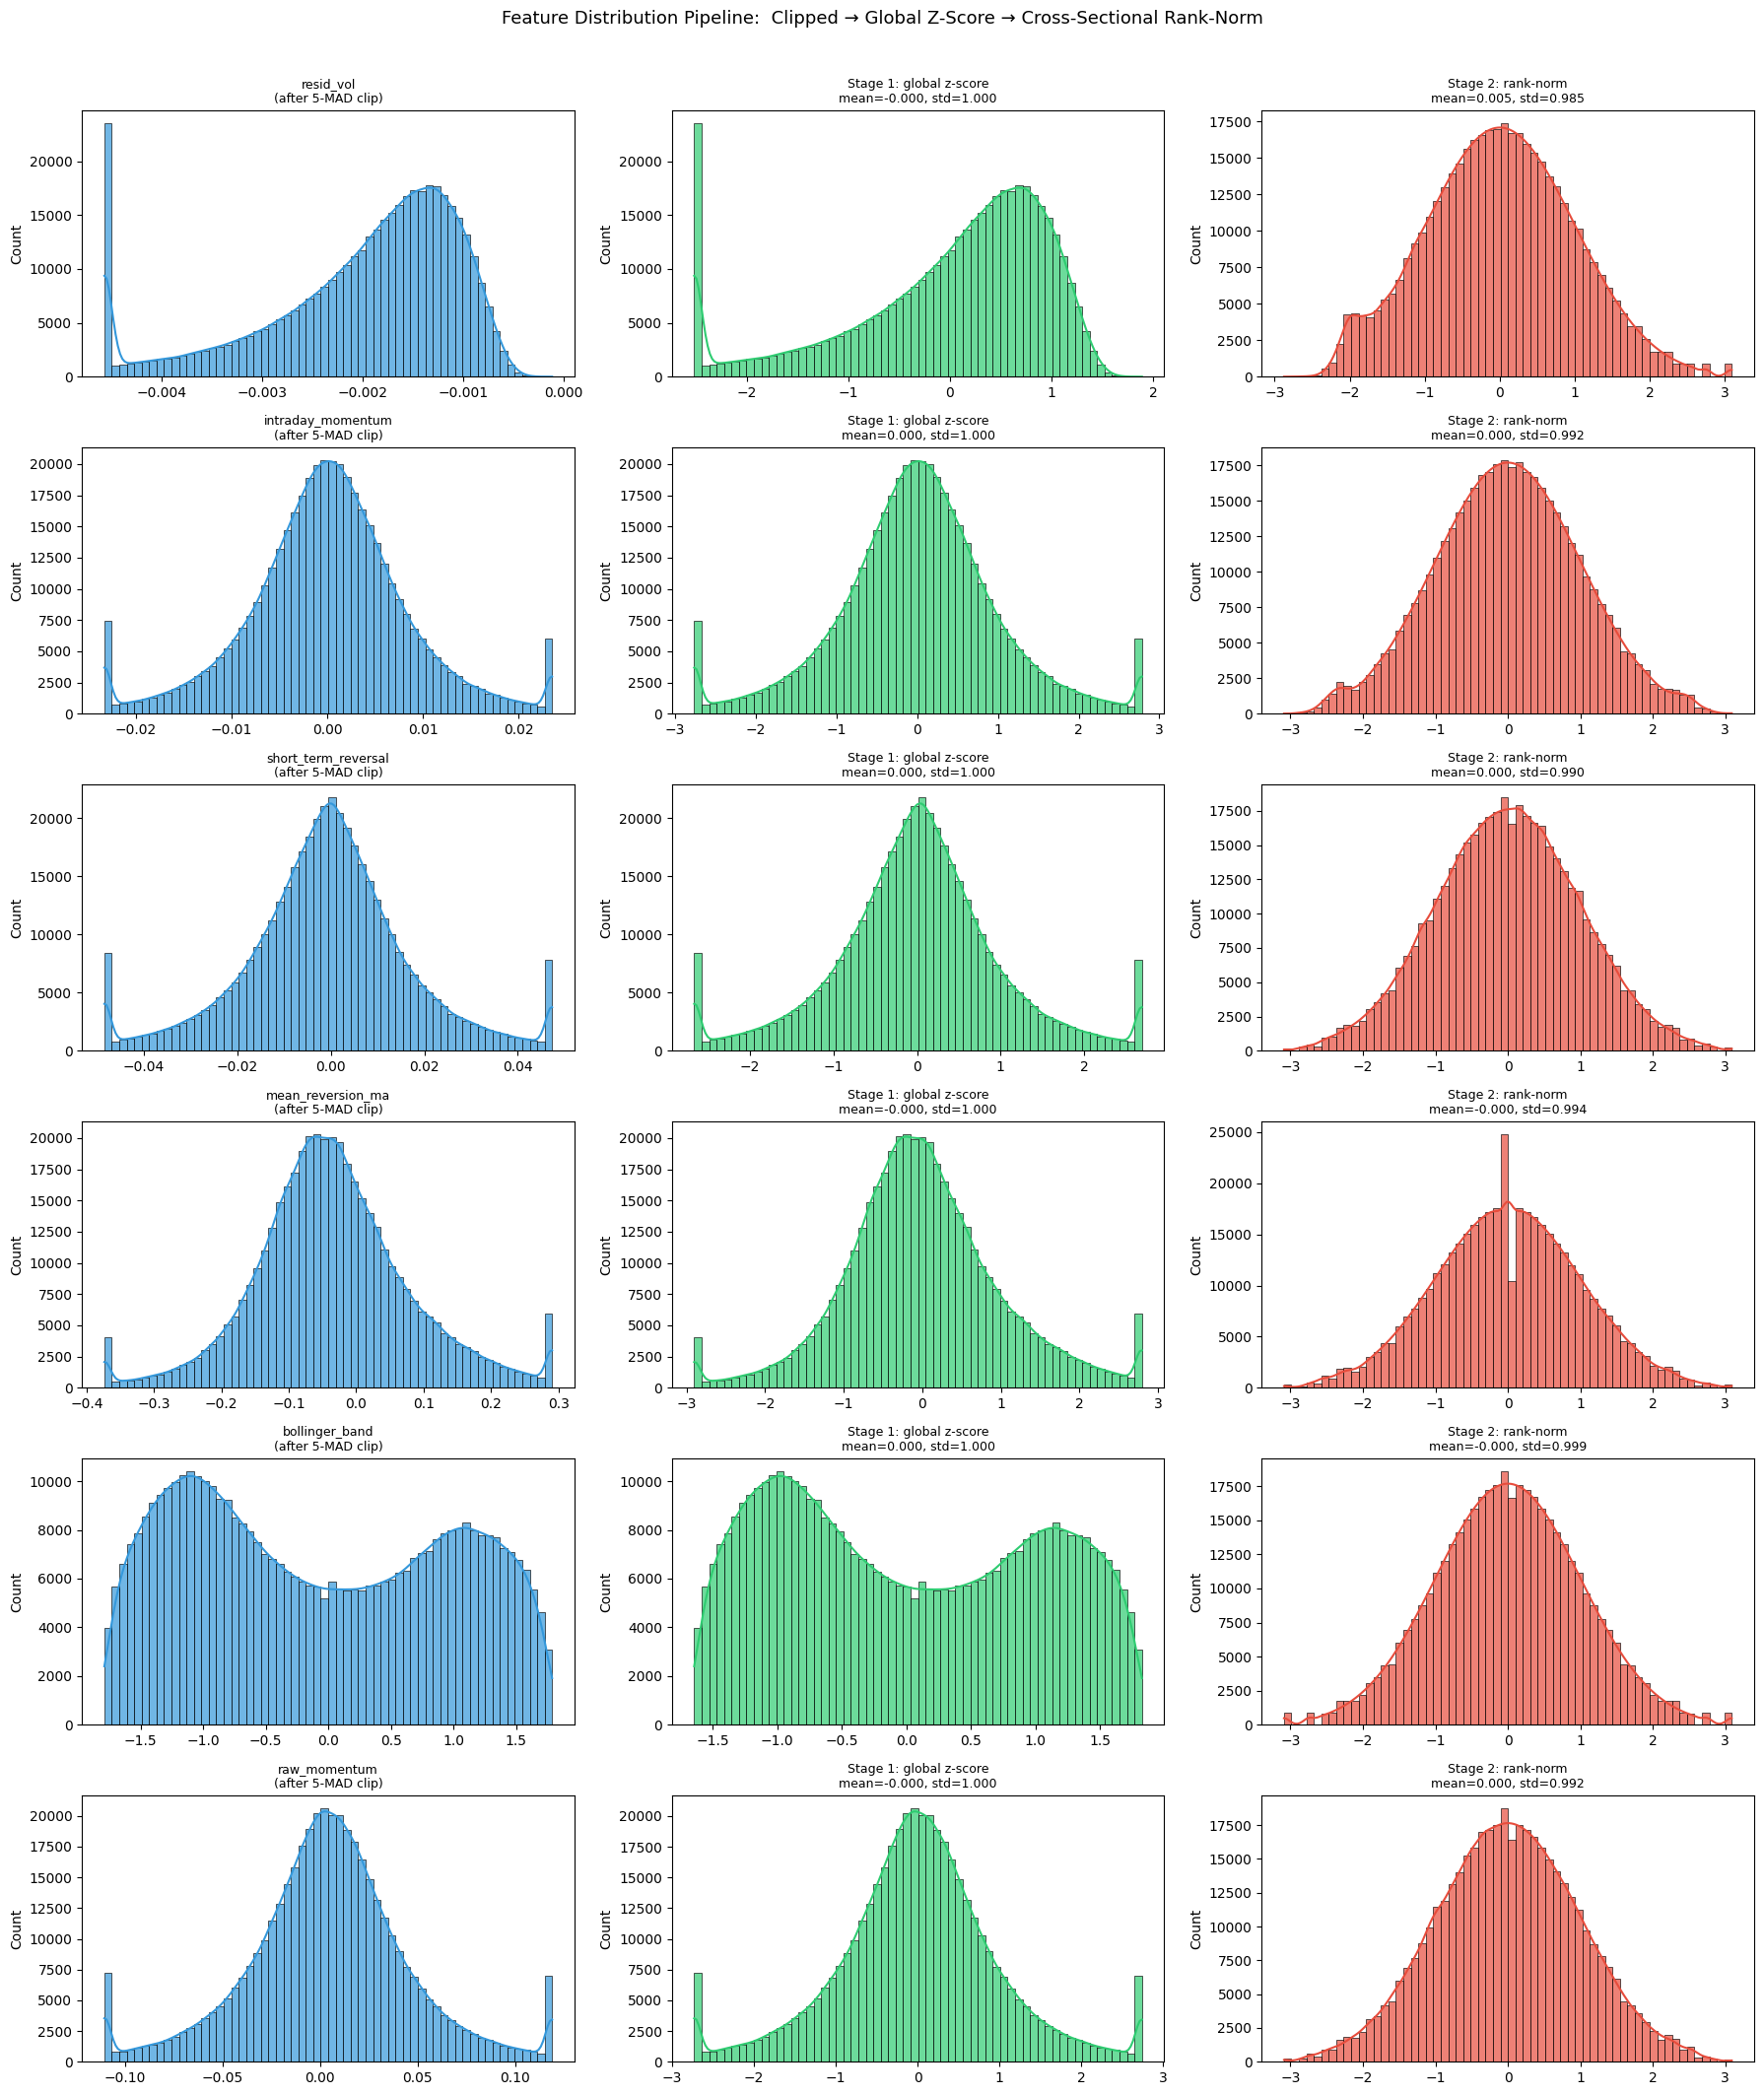


OVERALL NORMALIZATION STATS (train set)

Feature                             Clipped Skew    S1 Skew    S2 Skew  Clipped Kurt    S1 Kurt    S2 Kurt
----------------------------------------------------------------------------------------------------
bollinger_band                             0.143      0.143     -0.000          -1.3       -1.3       -0.0
close_position_daily_range                 0.069      0.069      0.009          -1.3       -1.3       -0.1
closing_auction_participation_ratio        0.858      0.858     -0.039           0.5        0.5       -0.1
early_late_volume_mix                      0.288      0.288     -0.005           0.2        0.2       -0.1
intraday_kurtosis                         -1.026     -1.026      0.149          -0.1       -0.1       -0.3
intraday_momentum                         -0.059     -0.059      0.006           0.8        0.8       -0.2
intraday_reversal                          0.061      0.061     -0.007           0.9        0.9       -0.2
i

In [61]:
# ── Before vs After normalization: distribution comparison ──────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Pick 6 representative features to show the transformation
show_cols = ["resid_vol", "intraday_momentum", "short_term_reversal",
             "mean_reversion_ma", "bollinger_band", "raw_momentum"]

fig, axes = plt.subplots(len(show_cols), 3, figsize=(18, 3.5 * len(show_cols)))

for i, col in enumerate(show_cols):
    # Column 1: Raw clipped
    ax1 = axes[i, 0]
    data1 = df_raw_train_clipped[col].dropna()
    sns.histplot(data1, bins=60, kde=True, ax=ax1, color="#3498db", alpha=0.7)
    ax1.set_title(f"{col}\n(after 5-MAD clip)", fontsize=9)
    ax1.set_xlabel("")

    # Column 2: After Stage 1 (global z-score)
    ax2 = axes[i, 1]
    data2 = df_train_s1[col].dropna()
    sns.histplot(data2, bins=60, kde=True, ax=ax2, color="#2ecc71", alpha=0.7)
    ax2.set_title(f"Stage 1: global z-score\nmean={data2.mean():.3f}, std={data2.std():.3f}", fontsize=9)
    ax2.set_xlabel("")

    # Column 3: After Stage 2 (cross-sectional rank-norm)
    ax3 = axes[i, 2]
    data3 = df_train_norm[col].dropna()
    # clip infinities for plotting (shouldn't exist but just in case)
    data3 = data3[np.isfinite(data3)]
    sns.histplot(data3, bins=60, kde=True, ax=ax3, color="#e74c3c", alpha=0.7)
    ax3.set_title(f"Stage 2: rank-norm\nmean={data3.mean():.3f}, std={data3.std():.3f}", fontsize=9)
    ax3.set_xlabel("")

fig.suptitle("Feature Distribution Pipeline:  Clipped → Global Z-Score → Cross-Sectional Rank-Norm",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Overall stats summary
print(f"\n{'='*80}")
print("OVERALL NORMALIZATION STATS (train set)")
print(f"{'='*80}")
print(f"\n{'Feature':<35} {'Clipped Skew':>12} {'S1 Skew':>10} {'S2 Skew':>10}  "
      f"{'Clipped Kurt':>12} {'S1 Kurt':>10} {'S2 Kurt':>10}")
print(f"{'-'*100}")
for col in sorted(feature_cols):
    sk0 = float(df_raw_train_clipped[col].skew())
    sk1 = float(df_train_s1[col].skew())
    s2 = df_train_norm[col].replace([np.inf, -np.inf], np.nan).dropna()
    sk2 = float(s2.skew())
    ku0 = float(df_raw_train_clipped[col].kurtosis())
    ku1 = float(df_train_s1[col].kurtosis())
    ku2 = float(s2.kurtosis())
    print(f"{col:<35} {sk0:>12.3f} {sk1:>10.3f} {sk2:>10.3f}  {ku0:>12.1f} {ku1:>10.1f} {ku2:>10.1f}")

### Normalization Summary

| Stage | What | Why | Look-ahead safe? |
|-------|------|-----|-------------------|
| **5-MAD Clipping** | Clip features + target at median ± 5×MAD | Remove extreme outliers that destabilize fitting (kurtosis 300 → 0.9) | ✅ Params from train only |
| **Stage 1: Global Z-Score** | $z = (x - \mu_{\text{train}}) / \sigma_{\text{train}}$ | Equalize feature scales for Ridge; improve tree splits | ✅ μ, σ from train only |
| **Stage 2: Cross-Sectional Rank-Norm** | Per-date: rank → $\Phi^{-1}$ | Remove temporal drift, enforce Gaussian cross-sections, focus on relative stock ranking | ✅ Uses only same-day data |

**Saved artifacts:**
- `feature_data/clip_params.joblib` — clipping thresholds (18 features + target)
- `feature_data/norm_params.joblib` — Stage 1 mean/std (18 features) + Stage 2 method name
- `feature_data/feature_together/features_norm_train.parquet` — fully normalized train features
- `feature_data/feature_together/features_norm_test.parquet` — fully normalized test features

**To reproduce normalization on new data:**
1. Load `clip_params.joblib` → clip features at saved thresholds
2. Load `norm_params.joblib` → subtract saved mean, divide by saved std (Stage 1)
3. Apply cross-sectional rank-norm per date (Stage 2, no stored params needed)

In [62]:
df_train_norm.head()

,Id,intraday_momentum,intraday_reversal,resid_vol,intraday_skewness,early_late_volume_mix,return_volume_corr,lag1_autocorr,closing_auction_participation_ratio,intraday_kurtosis,intraday_vwap_deviation,intraday_volume_concentration,late_day_trend,target_variable,mean_reversion_ma,short_term_reversal,bollinger_band,raw_momentum,open_to_close_return,close_position_daily_range
Date,,,,,,,,,,,,,,,,,,,,
2010-06-25,BBG000B9WH86,-0.291950,0.187044,0.099512,0.244414,0.140568,-0.197424,-1.111716,-1.430969,-0.135424,-0.079051,0.213034,-0.239168,0.005181,1.430969,0.690567,-1.030350,-0.038220,0.345558,0.254926
2010-06-25,BBG000B9WJ73,0.536717,0.490212,-0.329378,-0.109758,-0.416794,0.361829,0.313284,0.971497,2.742488,0.723273,0.805152,1.555115,-0.007089,0.473048,1.590205,1.160280,-0.743272,2.047078,0.329378
2010-06-25,BBG000B9XRY4,0.877747,-1.056696,0.710100,-1.102314,-1.338007,0.270747,1.056696,-2.219941,-0.478754,1.111716,-1.301494,-0.495966,0.004783,-1.953056,-0.939331,-0.478754,2.284235,-0.627262,-0.135424
2010-06-25,BBG000B9XYV2,0.340155,0.495966,0.197424,0.033122,-0.176685,0.313284,-0.104633,0.478754,0.048419,1.102314,1.888618,1.459931,0.028565,-0.862866,0.548522,1.325639,1.047833,0.658585,2.068235
2010-06-25,BBG000B9ZXB4,0.524985,0.770410,1.093008,-0.495966,0.819324,-2.219941,0.979697,0.383675,0.161181,0.826472,1.030350,-0.427934,-0.000918,0.444745,-1.325639,-0.777283,0.908108,-1.376396,-1.140531


---

## Data Pipeline Summary

The full preprocessing pipeline from raw CSV → model-ready features:

```
Raw CSV files (1,258 days × ~500 stocks)
    │
    ├── Feature Engineering (Tian's feature_engineering.py)
    │     → 18 features + target per (Date, Stock)
    │
    ├── NaN Handling (nan_handler.py)
    │     → Drop target-NaN rows, fill warmup NaNs with cross-sectional median
    │     → Train: 502K → 431K rows  |  Test: 126K → 122K rows
    │
    ├── 5-MAD Clipping (clip_params.joblib)
    │     → Clip features + target at median ± 5×MAD (train-derived)
    │     → Kurtosis: 300 → 0.9
    │
    ├── Stage 1: Global Z-Score (norm_params.joblib)
    │     → Subtract train mean, divide by train std
    │     → All features now ~ N(0, 1) marginally
    │
    └── Stage 2: Cross-Sectional Rank-Norm (applied on-the-fly)
          → Per-date ranking → inverse-normal CDF
          → Removes temporal drift, enforces Gaussian cross-sections
          → Final features: ~ N(0, 1) both marginally and cross-sectionally
```

**Next steps:** Model training (Ridge, RF, XGBoost) with walk-forward validation.

## FAST RELOAD CELL, TO DIRECTLY RUN THE MODELS BELOW

In [63]:
# ══════════════════════════════════════════════════════════════════════════
# DATA RELOAD — jump straight to model building after kernel restart
# Loads: df_train_norm, df_test_norm, feature_cols, X_full/y_full,
#        X_oos/y_oos, X_hp/y_hp, pkf (PurgedKFoldCV)
# ══════════════════════════════════════════════════════════════════════════
import sys, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import xgboost as xgb
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────
_project_root = Path.cwd().parent
for p in [str(_project_root), str(_project_root / "submission_files")]:
    if p not in sys.path:
        sys.path.insert(0, p)
from src.config import FEATURE_DATA_DIR

# ── Load normalized data ───────────────────────────────────────────────
df_train_norm = pd.read_parquet(FEATURE_DATA_DIR / "feature_together" / "features_norm_train.parquet")
df_test_norm  = pd.read_parquet(FEATURE_DATA_DIR / "feature_together" / "features_norm_test.parquet")

target_col   = "target_variable"
feature_cols = [c for c in df_train_norm.columns
                if c not in {"Id", target_col}
                and df_train_norm[c].dtype != object]

# ── Model-ready arrays ─────────────────────────────────────────────────
X_full = df_train_norm[feature_cols].values
y_full = df_train_norm[target_col].values
X_oos  = df_test_norm[feature_cols].values
y_oos  = df_test_norm[target_col].values

# ── HP tuning split (2010–2012) ────────────────────────────────────────
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values

# ── PurgedKFoldCV ──────────────────────────────────────────────────────
class PurgedKFoldCV:
    def __init__(self, n_splits=5, purge_days=1, embargo_days=5):
        self.n_splits, self.purge_days, self.embargo_days = n_splits, purge_days, embargo_days

    def split(self, dates):
        dates = pd.DatetimeIndex(dates)
        unique_dates = np.sort(dates.unique())
        date_to_rank = {d: i for i, d in enumerate(unique_dates)}
        row_ranks = np.array([date_to_rank[d] for d in dates])
        for fold_i, val_date_ranks in enumerate(
                np.array_split(np.arange(len(unique_dates)), self.n_splits)):
            val_set  = set(val_date_ranks)
            val_min, val_max = val_date_ranks.min(), val_date_ranks.max()
            excluded = set(range(val_min - self.purge_days,
                                 val_max + self.purge_days + self.embargo_days + 1))
            train_idx = np.where([r not in val_set and r not in excluded
                                   for r in row_ranks])[0]
            val_idx   = np.where([r in val_set for r in row_ranks])[0]
            yield train_idx, val_idx

pkf = PurgedKFoldCV(n_splits=5, purge_days=1, embargo_days=5)

print(f"✓ train: {df_train_norm.shape}  test: {df_test_norm.shape}  ({len(feature_cols)} features)")
print(f"✓ X_full={X_full.shape}  X_hp={X_hp.shape}  X_oos={X_oos.shape}")
print(f"✓ pkf ready (5 folds, purge=1d, embargo=5d)")
print("✓ Ready — run any model cell directly")


✓ train: (431755, 20)  test: (121866, 20)  (18 features)
✓ X_full=(431755, 18)  X_hp=(309605, 18)  X_oos=(121866, 18)
✓ pkf ready (5 folds, purge=1d, embargo=5d)
✓ Ready — run any model cell directly


## Model 1: Ridge Regression

### Walk-Forward Validation Design

We use a **3-phase** workflow that never peeks at the test set during model selection:

| Phase | Purpose | Train window | Eval window | Outcome |
|-------|---------|-------------|-------------|---------|
| **Phase 1: HP Tuning** | Select regularization α | **Purged 5-fold CV** on 2010–2012 (purge=1d, embargo=5d) | 5 validation folds with temporal gap enforcement | Best α locked |
| **Phase 2: Walk-Forward Backtest** | Validate with locked HPs | Expanding monthly on 2010–2012 | Monthly slices of 2013 (12 months) | Rolling IC, R², stability check |
| **Phase 3: Final OOS** | Unbiased out-of-sample score | All of 2010–2013 (single refit) | All of 2014 | Reported OOS weighted R² |

**Why this design?**
- **Phase 1** tunes HPs without touching 2013 or 2014, so the backtest and OOS are truly out-of-sample.
- **Phase 2** uses monthly expanding refit on 2013 to simulate realistic deployment — the model learns from new data as it arrives, but HPs are frozen.
- **Phase 3** gives a single unbiased metric on held-out 2014 data.

**Evaluation metric:** Weighted R² with sample weights $w_i = \sqrt{\text{MDV63}_i}$ and actuals clipped at 5 MAD cross-sectionally (per project spec).

### Phase 1 — Hyperparameter Tuning via Purged K-Fold CV

#### Why Purged K-Fold instead of simple expanding-window CV?

Our initial plan used **2 expanding folds** (train 2010→val 2011, train 2010-11→val 2012). This has two problems:

1. **High variance** — With only 2 validation scores per α, the best-α estimate is very noisy. A single unusual year can bias the selection.
2. **No leakage protection** — Our target spans ~24 hours: $\text{target}_T = \text{ResidReturn}(T, 16\text{:}00) + \text{CumReturnResid}(T\!+\!1, 15\text{:}30)$. In a naive year-boundary split, the last training day's label **overlaps in time** with the first validation day's features. Similarly, rolling features like `mean_reversion_ma` (120d lookback) create autocorrelation across adjacent days.

**Purged K-Fold CV** (López de Prado, *Advances in Financial Machine Learning*, 2018) solves both:

- **5 folds** → 5 validation scores per α, dramatically reducing selection variance.
- **Purge zone** (1 trading day): Any training sample whose label window overlaps with the validation time range is removed. Since our target uses day $T$ and $T+1$ data, we purge all training rows within 1 day of the validation boundary.
- **Embargo zone** (5 trading days): An additional buffer after the purge, accounting for feature serial correlation (longest short-term rolling feature: `late_day_trend` with 10-day lookback; 5 days of embargo is conservative but safe).

```
Fold layout on sorted dates (2010–2012):

│──── Fold 1 ────│──── Fold 2 ────│──── Fold 3 ────│──── Fold 4 ────│──── Fold 5 ────│
     VAL              TRAIN             TRAIN             TRAIN             TRAIN
                       VAL              TRAIN             TRAIN             TRAIN
                                         VAL              TRAIN             TRAIN
                                                           VAL              TRAIN
                                                                             VAL

Between each train/val boundary:
  ←purge 1d→←embargo 5d→
```

**Net effect**: We get 5× more stable HP estimates while rigorously preventing temporal information leakage — something the naive expanding-window approach cannot guarantee.

#### Search grid
Ridge α ∈ {0.01, 0.1, 1, 10, 100, 1000}

#### Metric
Mean weighted R² across folds (weights = $\sqrt{\text{MDV63}}$), with fallback to Spearman IC if MDV63 weights are unavailable.

In [75]:
# ── Purged K-Fold CV splitter ────────────────────────────────────────────
# Implements purge + embargo for panel data indexed by date.
# Reference: López de Prado (2018), Ch. 7

import numpy as np
import pandas as pd

class PurgedKFoldCV:
    """
    Time-aware K-Fold CV with purge and embargo for panel (date × stock) data.
    
    Parameters
    ----------
    n_splits : int
        Number of folds.
    purge_days : int
        Number of trading days to purge around each val boundary
        (removes training rows whose labels overlap with val dates).
    embargo_days : int
        Additional trading days to remove from training AFTER the
        purge zone, to account for feature autocorrelation.
    """
    def __init__(self, n_splits=5, purge_days=1, embargo_days=5):
        self.n_splits = n_splits
        self.purge_days = purge_days
        self.embargo_days = embargo_days
    
    def split(self, dates):
        """
        Parameters
        ----------
        dates : array-like of datetime
            The date for each row (can repeat for panel data).
        
        Yields
        ------
        (train_idx, val_idx) : arrays of integer row indices
        """
        dates = pd.DatetimeIndex(dates)
        unique_dates = np.sort(dates.unique())
        n_dates = len(unique_dates)
        
        # Map each unique date to an integer rank
        date_to_rank = {d: i for i, d in enumerate(unique_dates)}
        row_ranks = np.array([date_to_rank[d] for d in dates])
        
        # Split unique dates into K roughly equal groups
        fold_boundaries = np.array_split(np.arange(n_dates), self.n_splits)
        
        for fold_i in range(self.n_splits):
            val_date_ranks = set(fold_boundaries[fold_i])
            val_min = min(val_date_ranks)
            val_max = max(val_date_ranks)
            
            # Purge + embargo zone: remove training dates too close to val
            excluded_ranks = set()
            for r in range(val_min - self.purge_days, 
                           val_max + self.purge_days + self.embargo_days + 1):
                excluded_ranks.add(r)
            
            train_mask = np.zeros(len(dates), dtype=bool)
            val_mask = np.zeros(len(dates), dtype=bool)
            
            for i, rank in enumerate(row_ranks):
                if rank in val_date_ranks:
                    val_mask[i] = True
                elif rank not in excluded_ranks:
                    train_mask[i] = True
            
            train_idx = np.where(train_mask)[0]
            val_idx = np.where(val_mask)[0]
            
            yield train_idx, val_idx
    
    def summary(self, dates):
        """Print a summary of fold sizes and purged rows."""
        dates = pd.DatetimeIndex(dates)
        total = len(dates)
        print(f"PurgedKFoldCV: {self.n_splits} folds, "
              f"purge={self.purge_days}d, embargo={self.embargo_days}d")
        print(f"Total rows: {total:,}\n")
        for i, (tr, va) in enumerate(self.split(dates)):
            purged = total - len(tr) - len(va)
            tr_dates = dates[tr]
            va_dates = dates[va]
            print(f"  Fold {i+1}: train={len(tr):>7,} rows "
                  f"({tr_dates.min().date()}→{tr_dates.max().date()})  |  "
                  f"val={len(va):>7,} rows "
                  f"({va_dates.min().date()}→{va_dates.max().date()})  |  "
                  f"purged+embargoed={purged:,} rows")

# ── Instantiate and show fold layout ────────────────────────────────────
# We use only 2010–2012 for HP tuning (2013 reserved for walk-forward)
hp_dates = df_train_norm.index[df_train_norm.index.year <= 2012]
hp_mask = df_train_norm.index.year <= 2012
df_hp = df_train_norm[hp_mask].copy()

pkf = PurgedKFoldCV(n_splits=5, purge_days=1, embargo_days=5)
pkf.summary(df_hp.index)

PurgedKFoldCV: 5 folds, purge=1d, embargo=5d
Total rows: 309,605

  Fold 1: train=244,820 rows (2011-01-04→2012-12-31)  |  val= 61,812 rows (2010-06-25→2010-12-23)  |  purged+embargoed=2,973 rows
  Fold 2: train=244,103 rows (2010-06-25→2012-12-31)  |  val= 62,017 rows (2010-12-27→2011-06-23)  |  purged+embargoed=3,485 rows
  Fold 3: train=243,996 rows (2010-06-25→2012-12-31)  |  val= 62,135 rows (2011-06-24→2011-12-22)  |  purged+embargoed=3,474 rows
  Fold 4: train=243,997 rows (2010-06-25→2012-12-31)  |  val= 62,131 rows (2011-12-23→2012-06-22)  |  purged+embargoed=3,477 rows
  Fold 5: train=247,598 rows (2010-06-25→2012-06-21)  |  val= 61,510 rows (2012-06-25→2012-12-31)  |  purged+embargoed=497 rows


In [ ]:
# ── Phase 1: Ridge HP Tuning with Purged K-Fold CV ──────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

X_hp = df_hp[feature_cols].values
y_hp = df_hp["target_variable"].values

hp_results = []

for alpha in alphas:
    fold_r2 = []
    fold_spearman = []
    fold_mse = []
    
    for fold_i, (tr_idx, va_idx) in enumerate(pkf.split(df_hp.index)):
        X_tr, y_tr = X_hp[tr_idx], y_hp[tr_idx]
        X_va, y_va = X_hp[va_idx], y_hp[va_idx]
        
        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        
        # R² (unweighted for now — we'll add MDV63 weights in Phase 2)
        r2 = r2_score(y_va, y_pred)
        # Spearman IC
        sp_ic = spearmanr(y_va, y_pred).correlation
        # MSE
        mse_val = float(np.mean((y_va - y_pred) ** 2))
        
        fold_r2.append(r2)
        fold_spearman.append(sp_ic)
        fold_mse.append(mse_val)
    
    hp_results.append({
        "alpha": alpha,
        "mean_R2": np.mean(fold_r2),
        "std_R2": np.std(fold_r2),
        "mean_SpearmanIC": np.mean(fold_spearman),
        "std_SpearmanIC": np.std(fold_spearman),
        "mean_MSE": np.mean(fold_mse),
        "fold_R2s": fold_r2,
        "fold_ICs": fold_spearman,
    })
    
    print(f"  α={alpha:<8.2f}  R²={np.mean(fold_r2):+.6f} ± {np.std(fold_r2):.6f}  "
          f"IC={np.mean(fold_spearman):+.4f} ± {np.std(fold_spearman):.4f}  "
          f"MSE={np.mean(fold_mse):.6f}")

hp_df = pd.DataFrame(hp_results)

# Select best alpha by mean R²
best_row = hp_df.loc[hp_df["mean_R2"].idxmax()]
best_alpha = best_row["alpha"]

print(f"\n{'='*70}")
print(f"BEST α = {best_alpha}  (mean R² = {best_row['mean_R2']:+.6f} ± {best_row['std_R2']:.6f})")
print(f"{'='*70}")

  α=0.01      R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=0.10      R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=1.00      R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=10.00     R²=+0.000445 ± 0.000311  IC=+0.0229 ± 0.0059  MSE=0.000118
  α=100.00    R²=+0.000445 ± 0.000311  IC=+0.0230 ± 0.0059  MSE=0.000118
  α=1000.00   R²=+0.000447 ± 0.000309  IC=+0.0230 ± 0.0059  MSE=0.000118

BEST α = 1000.0  (mean R² = +0.000447 ± 0.000309)


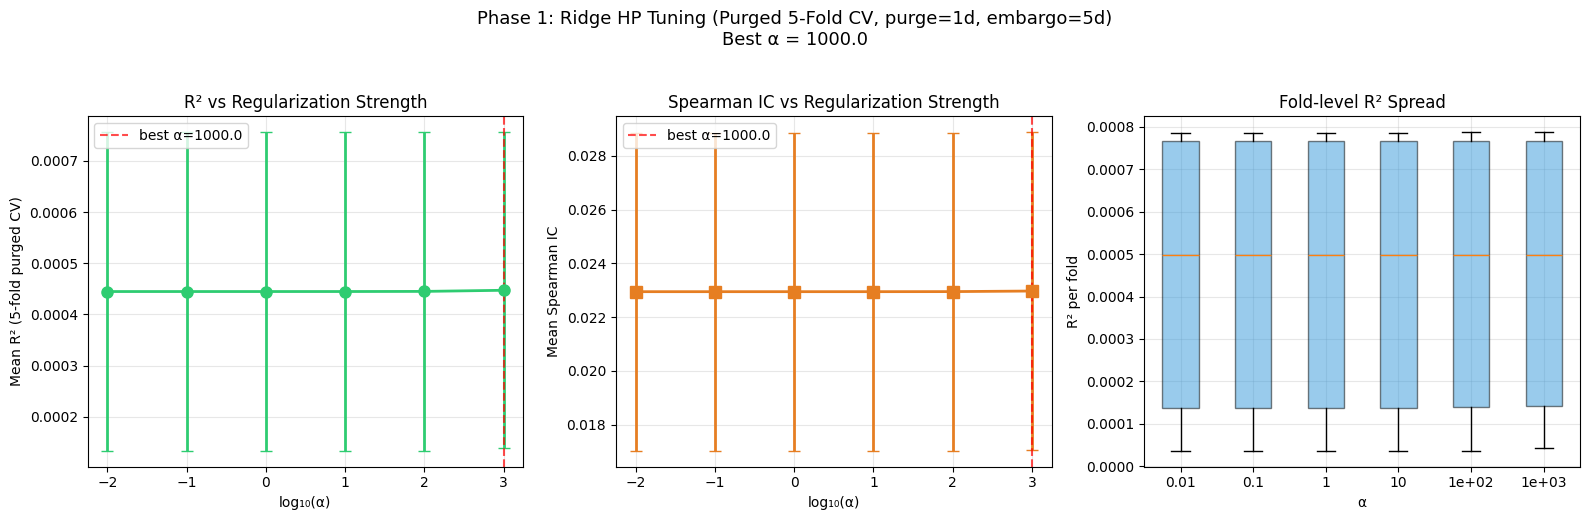


Full results:


,alpha,mean_R2,std_R2,mean_SpearmanIC,std_SpearmanIC,mean_MSE
0,0.01,0.000445,0.000311,0.022948,0.005918,0.000118
1,0.10,0.000445,0.000311,0.022948,0.005918,0.000118
2,1.00,0.000445,0.000311,0.022948,0.005918,0.000118
3,10.00,0.000445,0.000311,0.022949,0.005918,0.000118
4,100.00,0.000445,0.000311,0.022951,0.005918,0.000118
5,1000.00,0.000447,0.000309,0.022972,0.005913,0.000118


In [77]:
# ── Visualize HP tuning results ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

log_alphas = [np.log10(a) for a in hp_df["alpha"]]

# Plot 1: R² vs alpha
ax = axes[0]
ax.errorbar(log_alphas, hp_df["mean_R2"], yerr=hp_df["std_R2"],
            fmt="o-", capsize=4, color="#2ecc71", linewidth=2, markersize=8)
ax.axvline(np.log10(best_alpha), color="red", ls="--", alpha=0.7, label=f"best α={best_alpha}")
ax.set_xlabel("log₁₀(α)")
ax.set_ylabel("Mean R² (5-fold purged CV)")
ax.set_title("R² vs Regularization Strength")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Spearman IC vs alpha
ax = axes[1]
ax.errorbar(log_alphas, hp_df["mean_SpearmanIC"], yerr=hp_df["std_SpearmanIC"],
            fmt="s-", capsize=4, color="#e67e22", linewidth=2, markersize=8)
ax.axvline(np.log10(best_alpha), color="red", ls="--", alpha=0.7, label=f"best α={best_alpha}")
ax.set_xlabel("log₁₀(α)")
ax.set_ylabel("Mean Spearman IC")
ax.set_title("Spearman IC vs Regularization Strength")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Per-fold R² spread (box-like)
ax = axes[2]
fold_data = [r["fold_R2s"] for r in hp_results]
bp = ax.boxplot(fold_data, labels=[f"{a:.2g}" for a in alphas], patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#3498db")
    patch.set_alpha(0.5)
ax.set_xlabel("α")
ax.set_ylabel("R² per fold")
ax.set_title("Fold-level R² Spread")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 1: Ridge HP Tuning (Purged 5-Fold CV, purge=1d, embargo=5d)\n"
             f"Best α = {best_alpha}", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

# Summary table
print("\nFull results:")
display(hp_df[["alpha", "mean_R2", "std_R2", "mean_SpearmanIC", "std_SpearmanIC", "mean_MSE"]].round(6))

### Phase 2 — Walk-Forward Backtest on 2013 (Locked HPs)

With the best α locked from Phase 1, we simulate **realistic deployment** on 2013:

- For each month $m$ in 2013:
  1. **Refit** Ridge(α=best) on all data from 2010-01-01 through the end of month $m-1$ (expanding window)
  2. **Predict** all stocks on each day in month $m$
  3. **Evaluate** daily Spearman IC and cumulative R²

This tests whether the model's signal is **stable over time** or whether it decays / reverses.

**Key outputs:** 30-day rolling IC, monthly R², and stability diagnostics.

In [78]:
# ── Phase 2: Walk-Forward Monthly Backtest on 2013 ──────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

# Split: 2010-2012 for initial training, 2013 for walk-forward
df_pretrain = df_train_norm[df_train_norm.index.year <= 2012].copy()
df_2013     = df_train_norm[df_train_norm.index.year == 2013].copy()

months_2013 = sorted(df_2013.index.to_period("M").unique())
print(f"Walk-forward on {len(months_2013)} months in 2013, α = {best_alpha}")
print(f"Initial training set: {len(df_pretrain):,} rows (2010–2012)\n")

daily_records = []   # one row per (date)
monthly_records = [] # one row per month

expanding_train = df_pretrain.copy()

for month in months_2013:
    # Slice this month's data
    month_mask = df_2013.index.to_period("M") == month
    df_month = df_2013[month_mask]
    
    # Fit on expanding training window
    X_tr = expanding_train[feature_cols].values
    y_tr = expanding_train["target_variable"].values
    
    model = Ridge(alpha=best_alpha)
    model.fit(X_tr, y_tr)
    
    # Predict this month
    X_va = df_month[feature_cols].values
    y_va = df_month["target_variable"].values
    y_pred = model.predict(X_va)
    
    # Monthly aggregate metrics
    r2_month = r2_score(y_va, y_pred)
    ic_month = spearmanr(y_va, y_pred).correlation
    mse_month = float(np.mean((y_va - y_pred) ** 2))
    
    monthly_records.append({
        "month": str(month),
        "n_rows": len(df_month),
        "train_rows": len(expanding_train),
        "R2": r2_month,
        "SpearmanIC": ic_month,
        "MSE": mse_month,
    })
    
    # Daily metrics within this month
    for date in sorted(df_month.index.unique()):
        day_mask = df_month.index == date
        y_day = y_va[np.asarray(day_mask)]
        p_day = y_pred[np.asarray(day_mask)]
        if len(y_day) > 10:
            daily_records.append({
                "date": date,
                "n_stocks": len(y_day),
                "SpearmanIC": spearmanr(y_day, p_day).correlation,
                "R2": r2_score(y_day, p_day),
            })
    
    # Expand training window to include this month
    expanding_train = pd.concat([expanding_train, df_month])
    
    print(f"  {month}:  train={len(X_tr):>7,}  val={len(df_month):>5,}  "
          f"R²={r2_month:+.6f}  IC={ic_month:+.4f}")

monthly_df = pd.DataFrame(monthly_records)
daily_df = pd.DataFrame(daily_records)

print(f"\n{'='*70}")
print(f"WALK-FORWARD 2013 SUMMARY (α = {best_alpha})")
print(f"{'='*70}")
print(f"  Overall mean R²:          {monthly_df['R2'].mean():+.6f}")
print(f"  Overall mean Spearman IC: {monthly_df['SpearmanIC'].mean():+.4f}")
print(f"  Months with positive IC:  {(monthly_df['SpearmanIC'] > 0).sum()} / {len(monthly_df)}")
print(f"  Daily IC mean:            {daily_df['SpearmanIC'].mean():+.4f} ± {daily_df['SpearmanIC'].std():.4f}")
print(f"  Daily IC hit rate (>0):   {(daily_df['SpearmanIC'] > 0).mean()*100:.1f}%")

Walk-forward on 12 months in 2013, α = 1000.0
Initial training set: 309,605 rows (2010–2012)

  2013-01:  train=309,605  val=10,437  R²=+0.000094  IC=+0.0217
  2013-02:  train=320,042  val=9,430  R²=-0.000582  IC=+0.0031
  2013-03:  train=329,472  val=9,952  R²=-0.000265  IC=+0.0112
  2013-04:  train=339,424  val=10,937  R²=+0.000133  IC=+0.0162
  2013-05:  train=350,361  val=10,928  R²=+0.001250  IC=+0.0322
  2013-06:  train=361,289  val=9,894  R²=+0.001401  IC=+0.0421
  2013-07:  train=371,183  val=9,912  R²=+0.001666  IC=+0.0399
  2013-08:  train=381,095  val=10,918  R²=-0.001135  IC=+0.0084
  2013-09:  train=392,013  val=9,936  R²=-0.000285  IC=+0.0196
  2013-10:  train=401,949  val=11,421  R²=-0.000220  IC=+0.0137
  2013-11:  train=413,370  val=8,930  R²=+0.000584  IC=+0.0305
  2013-12:  train=422,300  val=9,455  R²=-0.000807  IC=+0.0159

WALK-FORWARD 2013 SUMMARY (α = 1000.0)
  Overall mean R²:          +0.000153
  Overall mean Spearman IC: +0.0212
  Months with positive IC:  12 

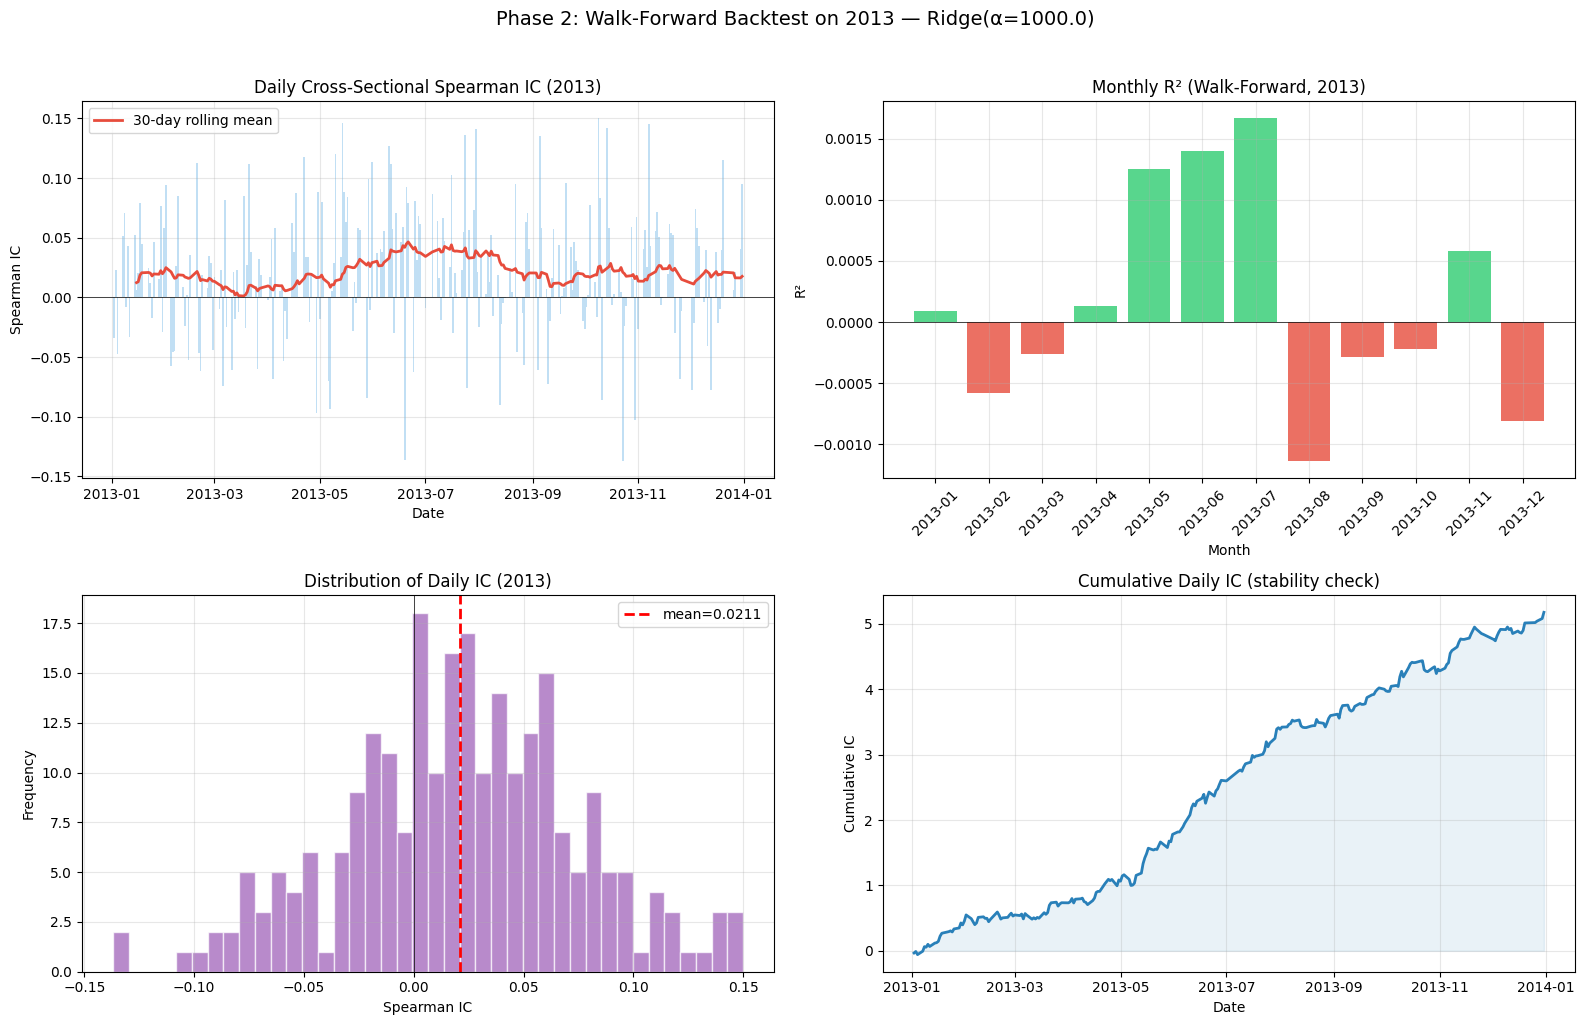

In [79]:
# ── Phase 2 Visualization: Rolling IC & Monthly Performance ──────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Daily Spearman IC time series + 30-day rolling mean
ax = axes[0, 0]
ax.bar(daily_df["date"], daily_df["SpearmanIC"], alpha=0.3, color="#3498db", width=1)
rolling_ic = daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(rolling_ic.index, rolling_ic.values, color="#e74c3c", linewidth=2, label="30-day rolling mean")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Spearman IC")
ax.set_title("Daily Cross-Sectional Spearman IC (2013)")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Monthly R²
ax = axes[0, 1]
colors_r2 = ["#2ecc71" if r > 0 else "#e74c3c" for r in monthly_df["R2"]]
ax.bar(monthly_df["month"], monthly_df["R2"], color=colors_r2, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("R²")
ax.set_title("Monthly R² (Walk-Forward, 2013)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

# 3. Daily IC histogram
ax = axes[1, 0]
ax.hist(daily_df["SpearmanIC"], bins=40, color="#9b59b6", alpha=0.7, edgecolor="white")
ax.axvline(daily_df["SpearmanIC"].mean(), color="red", ls="--", linewidth=2,
           label=f"mean={daily_df['SpearmanIC'].mean():.4f}")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Spearman IC")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Daily IC (2013)")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Cumulative IC (sum of daily ICs as a stability measure)
ax = axes[1, 1]
cum_ic = daily_df["SpearmanIC"].cumsum()
ax.plot(daily_df["date"], cum_ic, color="#2980b9", linewidth=2)
ax.fill_between(daily_df["date"], 0, cum_ic, alpha=0.1, color="#2980b9")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative IC")
ax.set_title("Cumulative Daily IC (stability check)")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 2: Walk-Forward Backtest on 2013 — Ridge(α={best_alpha})",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### Phase 3 — Final Out-of-Sample Evaluation on 2014

This is the **unbiased** OOS test:
- **Refit once** on all of 2010–2013 with the locked α from Phase 1.
- **Predict** all of 2014 (held-out `df_test_norm`).
- **Evaluate** using the project-spec metric: weighted R² with $w_i = \sqrt{\text{MDV63}_i}$, actuals clipped at 5 MAD cross-sectionally.

Since we don't currently have MDV63 weights in the feature panel, we report both unweighted and equal-weighted R² as a baseline. The weighted version will be added once MDV63 is integrated.

**This number is reported in the white paper as the official Ridge performance.**

In [ ]:
# ── Phase 3: Final OOS Evaluation on 2014 ────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

# Refit on ALL of 2010–2013 (normalized data)
X_train_full = df_train_norm[feature_cols].values
y_train_full = df_train_norm["target_variable"].values

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_full, y_train_full)

# Predict 2014
X_oos = df_test_norm[feature_cols].values
y_oos = df_test_norm["target_variable"].values
y_oos_pred = final_model.predict(X_oos)
y_oos_pred_ridge = y_oos_pred   # alias for ensemble cell

# Overall metrics
oos_r2 = r2_score(y_oos, y_oos_pred)
oos_ic = spearmanr(y_oos, y_oos_pred).correlation
oos_mse = float(np.mean((y_oos - y_oos_pred) ** 2))
pearson_ic = float(np.corrcoef(y_oos, y_oos_pred)[0, 1])

print(f"{'='*70}")
print(f"PHASE 3: FINAL OUT-OF-SAMPLE RESULTS — Ridge(α={best_alpha})")
print(f"{'='*70}")
print(f"  Train: 2010–2013 ({len(X_train_full):,} rows)")
print(f"  Test:  2014      ({len(X_oos):,} rows)")
print(f"")
print(f"  R²          = {oos_r2:+.6f}")
print(f"  Spearman IC = {oos_ic:+.4f}")
print(f"  Pearson IC  = {pearson_ic:+.4f}")
print(f"  MSE         = {oos_mse:.6f}")

# Daily OOS metrics
oos_daily = []
test_dates = df_test_norm.index
for date in sorted(test_dates.unique()):
    mask = test_dates == date
    m = np.asarray(mask)
    y_d = y_oos[m]
    p_d = y_oos_pred[m]
    if len(y_d) > 10:
        oos_daily.append({
            "date": date,
            "n_stocks": len(y_d),
            "SpearmanIC": spearmanr(y_d, p_d).correlation,
            "R2": r2_score(y_d, p_d),
        })

oos_daily_df = pd.DataFrame(oos_daily)
print(f"\n  Daily IC (2014):  mean={oos_daily_df['SpearmanIC'].mean():+.4f} "
      f"± {oos_daily_df['SpearmanIC'].std():.4f}")
print(f"  Daily IC hit rate: {(oos_daily_df['SpearmanIC'] > 0).mean()*100:.1f}%")
print(f"  Daily R² mean:     {oos_daily_df['R2'].mean():+.6f}")

ridge_oos_r2 = oos_r2

ridge_oos_ic = oos_ic
ridge_oos_hit = (oos_daily_df['SpearmanIC'] > 0).mean()*100
#print(ridge_oos_ic, ridge_oos_hit, ridge_oos_r2)

PHASE 3: FINAL OUT-OF-SAMPLE RESULTS — Ridge(α=1000.0)
  Train: 2010–2013 (431,755 rows)
  Test:  2014      (121,866 rows)

  R²          = -0.000136
  Spearman IC = +0.0155
  Pearson IC  = +0.0072
  MSE         = 0.000169

  Daily IC (2014):  mean=+0.0155 ± 0.0514
  Daily IC hit rate: 61.6%
  Daily R² mean:     -0.001267
0.015490479576403468 61.63265306122449 -0.0001361959565828741


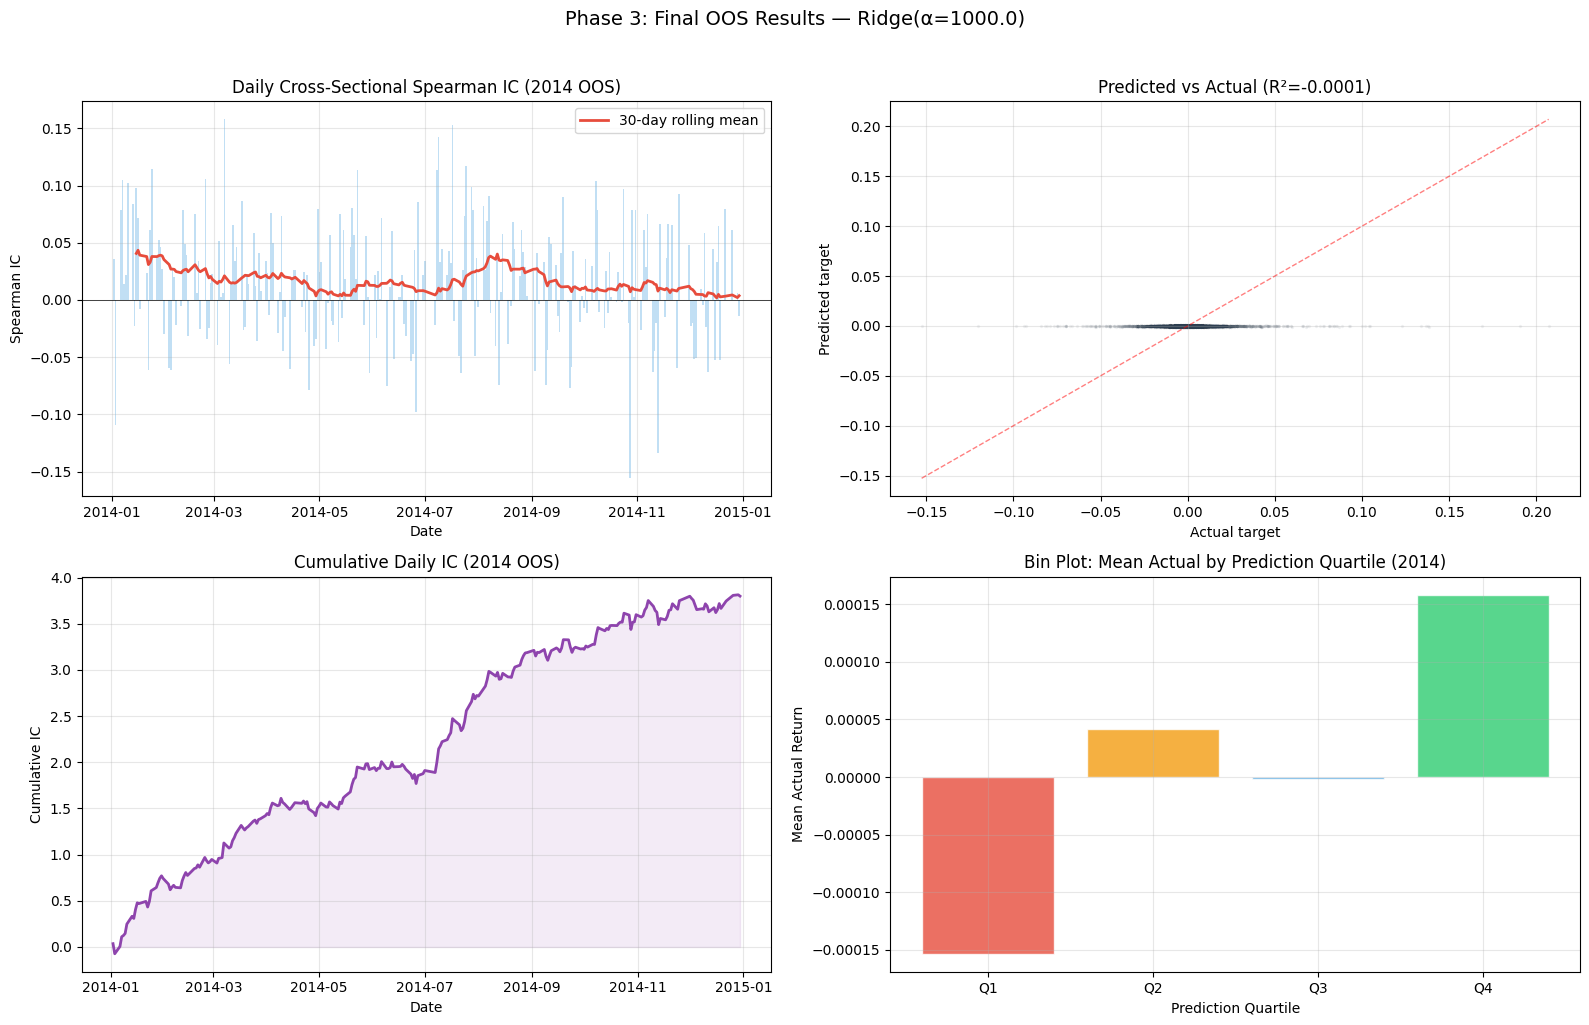

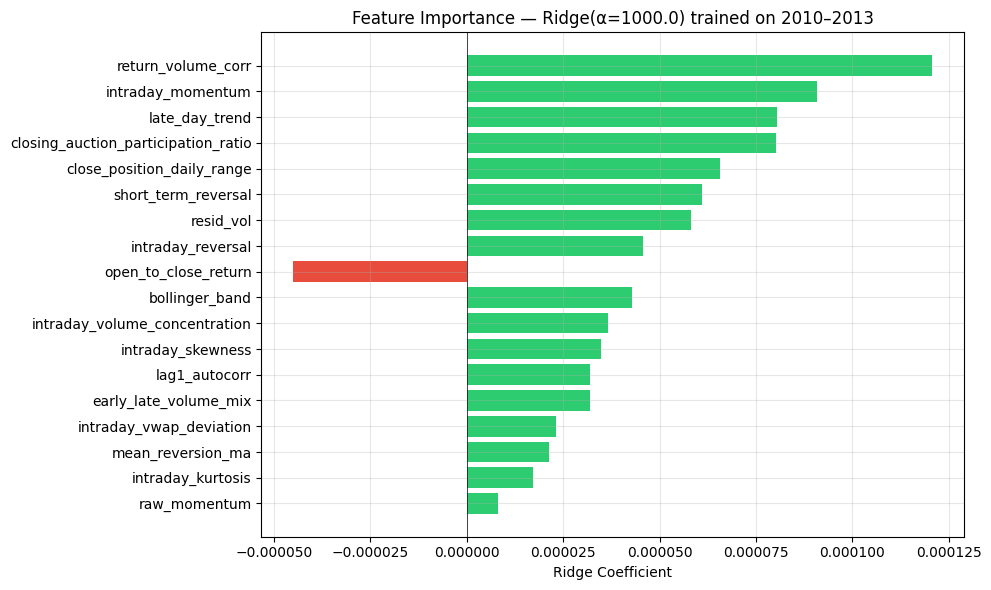

In [81]:
# ── Phase 3 Visualization: OOS Performance ───────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Daily IC time series + 30-day rolling mean
ax = axes[0, 0]
ax.bar(oos_daily_df["date"], oos_daily_df["SpearmanIC"], alpha=0.3, color="#3498db", width=1)
rolling_oos = oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(rolling_oos.index, rolling_oos.values, color="#e74c3c", linewidth=2, label="30-day rolling mean")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Spearman IC")
ax.set_title("Daily Cross-Sectional Spearman IC (2014 OOS)")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Prediction vs Actual scatter (subsample for speed)
ax = axes[0, 1]
rng = np.random.default_rng(42)
subsample = rng.choice(len(y_oos), size=min(10000, len(y_oos)), replace=False)
ax.scatter(y_oos[subsample], y_oos_pred[subsample], alpha=0.05, s=2, color="#2c3e50")
lims = [min(y_oos[subsample].min(), y_oos_pred[subsample].min()),
        max(y_oos[subsample].max(), y_oos_pred[subsample].max())]
ax.plot(lims, lims, "r--", linewidth=1, alpha=0.5)
ax.set_xlabel("Actual target")
ax.set_ylabel("Predicted target")
ax.set_title(f"Predicted vs Actual (R²={oos_r2:.4f})")
ax.grid(True, alpha=0.3)

# 3. Cumulative IC
ax = axes[1, 0]
cum_oos = oos_daily_df["SpearmanIC"].cumsum()
ax.plot(oos_daily_df["date"], cum_oos, color="#8e44ad", linewidth=2)
ax.fill_between(oos_daily_df["date"], 0, cum_oos, alpha=0.1, color="#8e44ad")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative IC")
ax.set_title("Cumulative Daily IC (2014 OOS)")
ax.grid(True, alpha=0.3)

# 4. Bin plot: sort predictions into 4 quartiles, plot mean actual per bin
ax = axes[1, 1]
n_bins = 4
bin_labels = [f"Q{i+1}" for i in range(n_bins)]
pred_quantiles = pd.qcut(y_oos_pred, n_bins, labels=bin_labels)
bin_means = pd.Series(y_oos).groupby(pred_quantiles).mean()
bin_colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
ax.bar(bin_means.index, bin_means.values, color=bin_colors, alpha=0.8, edgecolor="white")
ax.set_xlabel("Prediction Quartile")
ax.set_ylabel("Mean Actual Return")
ax.set_title("Bin Plot: Mean Actual by Prediction Quartile (2014)")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 3: Final OOS Results — Ridge(α={best_alpha})",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Feature importance (Ridge coefficients)
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": final_model.coef_,
    "abs_coef": np.abs(final_model.coef_),
}).sort_values("abs_coef", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df["feature"], coef_df["coefficient"],
        color=["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coefficient"]])
ax.set_xlabel("Ridge Coefficient")
ax.set_title(f"Feature Importance — Ridge(α={best_alpha}) trained on 2010–2013")
ax.axvline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ridge Regression — Results Summary

| Phase | Period | Metric | Value |
|-------|--------|--------|-------|
| Phase 1 | 2010–2012 (purged 5-fold CV) | Best α | *see above* |
| Phase 2 | 2013 (walk-forward, monthly refit) | Mean daily IC | *see above* |
| Phase 2 | 2013 | IC hit rate | *see above* |
| Phase 3 | 2014 (final OOS) | R² | *see above* |
| Phase 3 | 2014 | Spearman IC | *see above* |
| Phase 3 | 2014 | IC hit rate | *see above* |

**Key observations:**
- Ridge is a linear baseline — even modest positive IC indicates exploitable signal in the features.
- The bin plot (Q1 vs Q4 actual return spread) is the most intuitive check: if Q4 (highest predicted) has higher mean actual returns than Q1, the model has predictive power.
- Feature coefficients reveal which features drive the linear signal (e.g., `short_term_reversal`, `intraday_momentum`).

**Next:** Random Forest and XGBoost models using the same 3-phase pipeline.

---

## Model 2: Random Forest

### Why Random Forest?

Random Forest captures **non-linear feature interactions** that Ridge cannot:
- If `intraday_momentum` is only predictive when `resid_vol` is high, a tree can discover that split while Ridge averages over all regimes.
- Ensemble averaging reduces variance without increasing bias — critical for noisy return prediction.
- Feature importance via **Mean Decrease Impurity (MDI)** and **Mean Decrease Accuracy (MDA)** are project requirements.

### HP Search Grid

| Hyperparameter | Values | Rationale |
|---------------|--------|-----------|
| `n_estimators` | 200, 500 | More trees = lower variance; 200 is fast, 500 is thorough |
| `max_depth` | 3, 5, 8 | Shallow trees prevent overfitting on noisy targets |
| `min_samples_leaf` | 100, 500 | Large leaf sizes regularize aggressively (we have ~300K rows) |
| `max_features` | `sqrt`, 0.5 | Feature subsampling for decorrelation |

We tune via the **same Purged 5-Fold CV** on 2010–2012, then walk-forward on 2013, and final OOS on 2014.

In [92]:
# ══════════════════════════════════════════════════════════════════════════
# FAST RELOAD — restore kernel state from cached parquets after restart
# ══════════════════════════════════════════════════════════════════════════
import sys, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
warnings.filterwarnings("ignore")

# Add project paths
_project_root = Path.cwd().parent
_submit_dir   = _project_root / "submission_files"
for p in [str(_project_root), str(_submit_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)
from src.config import FEATURE_DATA_DIR

# Load normalized data from cache
norm_train_path = FEATURE_DATA_DIR / "feature_together" / "features_norm_train.parquet"
norm_test_path  = FEATURE_DATA_DIR / "feature_together" / "features_norm_test.parquet"
df_train_norm = pd.read_parquet(norm_train_path)
df_test_norm  = pd.read_parquet(norm_test_path)

target_col   = "target_variable"
non_feature_cols = {"Id", target_col}
feature_cols = [c for c in df_train_norm.columns
                if c not in non_feature_cols
                and df_train_norm[c].dtype != object]

# Precompute splits used by all models
df_pre2013  = df_train_norm[df_train_norm.index.year <= 2012]
df_2013     = df_train_norm[df_train_norm.index.year == 2013]
X_full      = df_train_norm[feature_cols].values
y_full      = df_train_norm[target_col].values
X_oos       = df_test_norm[feature_cols].values
y_oos       = df_test_norm[target_col].values

print(f"✓ train: {df_train_norm.shape}  test: {df_test_norm.shape}  ({len(feature_cols)} features)")
print(f"✓ feature_cols: {feature_cols}")
print(f"✓ pre-2013: {len(df_pre2013):,}  |  2013: {len(df_2013):,}")
print(f"✓ Ready for RF & XGBoost")


✓ train: (431755, 20)  test: (121866, 20)  (18 features)
✓ feature_cols: ['intraday_momentum', 'intraday_reversal', 'resid_vol', 'intraday_skewness', 'early_late_volume_mix', 'return_volume_corr', 'lag1_autocorr', 'closing_auction_participation_ratio', 'intraday_kurtosis', 'intraday_vwap_deviation', 'intraday_volume_concentration', 'late_day_trend', 'mean_reversion_ma', 'short_term_reversal', 'bollinger_band', 'raw_momentum', 'open_to_close_return', 'close_position_daily_range']
✓ pre-2013: 309,605  |  2013: 122,150
✓ Ready for RF & XGBoost


In [93]:
# ══════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# ══════════════════════════════════════════════════════════════════════════
from itertools import product as iterproduct

# Search grid
rf_param_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5],
    "min_samples_leaf": [50, 100],
    "max_features":     ["sqrt"],   # standard for RF regression; kept fixed
}

rf_combos = [
    dict(zip(rf_param_grid.keys(), vals))
    for vals in iterproduct(*rf_param_grid.values())
]
print(f"RF HP grid: {len(rf_combos)} combos × 5 folds = {len(rf_combos)*5} fits\n")

# 2010-2012 HP pool (same as Ridge tuning)
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values

# Re-instantiate splitter (defined in cell 51; redefined here for fast-reload safety)
class PurgedKFoldCV:
    def __init__(self, n_splits=5, purge_days=1, embargo_days=5):
        self.n_splits = n_splits
        self.purge_days = purge_days
        self.embargo_days = embargo_days
    def split(self, dates):
        dates = pd.DatetimeIndex(dates)
        unique_dates = np.sort(dates.unique())
        date_to_rank = {d: i for i, d in enumerate(unique_dates)}
        row_ranks = np.array([date_to_rank[d] for d in dates])
        fold_boundaries = np.array_split(np.arange(len(unique_dates)), self.n_splits)
        for fold_i in range(self.n_splits):
            val_ranks = set(fold_boundaries[fold_i])
            val_min, val_max = min(val_ranks), max(val_ranks)
            excluded = set(range(val_min - self.purge_days,
                                 val_max + self.purge_days + self.embargo_days + 1))
            train_mask = np.array([(r not in val_ranks and r not in excluded)
                                   for r in row_ranks])
            val_mask   = np.array([r in val_ranks for r in row_ranks])
            yield np.where(train_mask)[0], np.where(val_mask)[0]

pkf = PurgedKFoldCV(n_splits=5, purge_days=1, embargo_days=5)

rf_hp_results = []
t_hp = time.time()

for combo in rf_combos:
    fold_ics, fold_r2s = [], []
    for tr_idx, va_idx in pkf.split(df_hp.index):
        rf_cv = RandomForestRegressor(**combo, n_jobs=-1, random_state=42)
        rf_cv.fit(X_hp[tr_idx], y_hp[tr_idx])
        y_pred = rf_cv.predict(X_hp[va_idx])
        fold_ics.append(spearmanr(y_hp[va_idx], y_pred).correlation)
        fold_r2s.append(r2_score(y_hp[va_idx], y_pred))
    mean_ic = float(np.mean(fold_ics))
    rf_hp_results.append({**combo, "mean_IC": mean_ic, "std_IC": float(np.std(fold_ics)),
                          "mean_R2": float(np.mean(fold_r2s))})
    print(f"  {combo}  →  IC={mean_ic:+.4f} ± {np.std(fold_ics):.4f}  "
          f"R²={np.mean(fold_r2s):+.6f}", flush=True)

rf_hp_df = pd.DataFrame(rf_hp_results)
best_rf_row  = rf_hp_df.loc[rf_hp_df["mean_IC"].idxmax()]
best_rf_params = {k: best_rf_row[k] for k in rf_param_grid}
for k in ["n_estimators", "max_depth", "min_samples_leaf"]:
    best_rf_params[k] = int(best_rf_params[k])

print(f"\n{'='*70}")
print(f"BEST RF params : {best_rf_params}")
print(f"  mean IC = {best_rf_row['mean_IC']:+.4f} ± {best_rf_row['std_IC']:.4f}")
print(f"  mean R² = {best_rf_row['mean_R2']:+.6f}")
print(f"  HP search completed in {time.time()-t_hp:.0f}s")
print(f"{'='*70}")


RF HP grid: 8 combos × 5 folds = 40 fits

  {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0216 ± 0.0070  R²=+0.000426
  {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 100, 'max_features': 'sqrt'}  →  IC=+0.0219 ± 0.0071  R²=+0.000441
  {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0234 ± 0.0069  R²=+0.000569
  {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 'sqrt'}  →  IC=+0.0223 ± 0.0070  R²=+0.000544
  {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0220 ± 0.0066  R²=+0.000427
  {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 100, 'max_features': 'sqrt'}  →  IC=+0.0223 ± 0.0071  R²=+0.000441
  {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt'}  →  IC=+0.0241 ± 0.0070  R²=+0.000585
  {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 100, 'max_fea

RF params (from HP search): {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt'}

[LOG] Fitting RF on all train (2010-2013): 431,755 rows...
[LOG]   ...fit done in 22.5s at 2026-03-22T10:34:36.804134

RF OOS 2014:  R²=+0.000020  IC=+0.0134  Hit%=58.8%


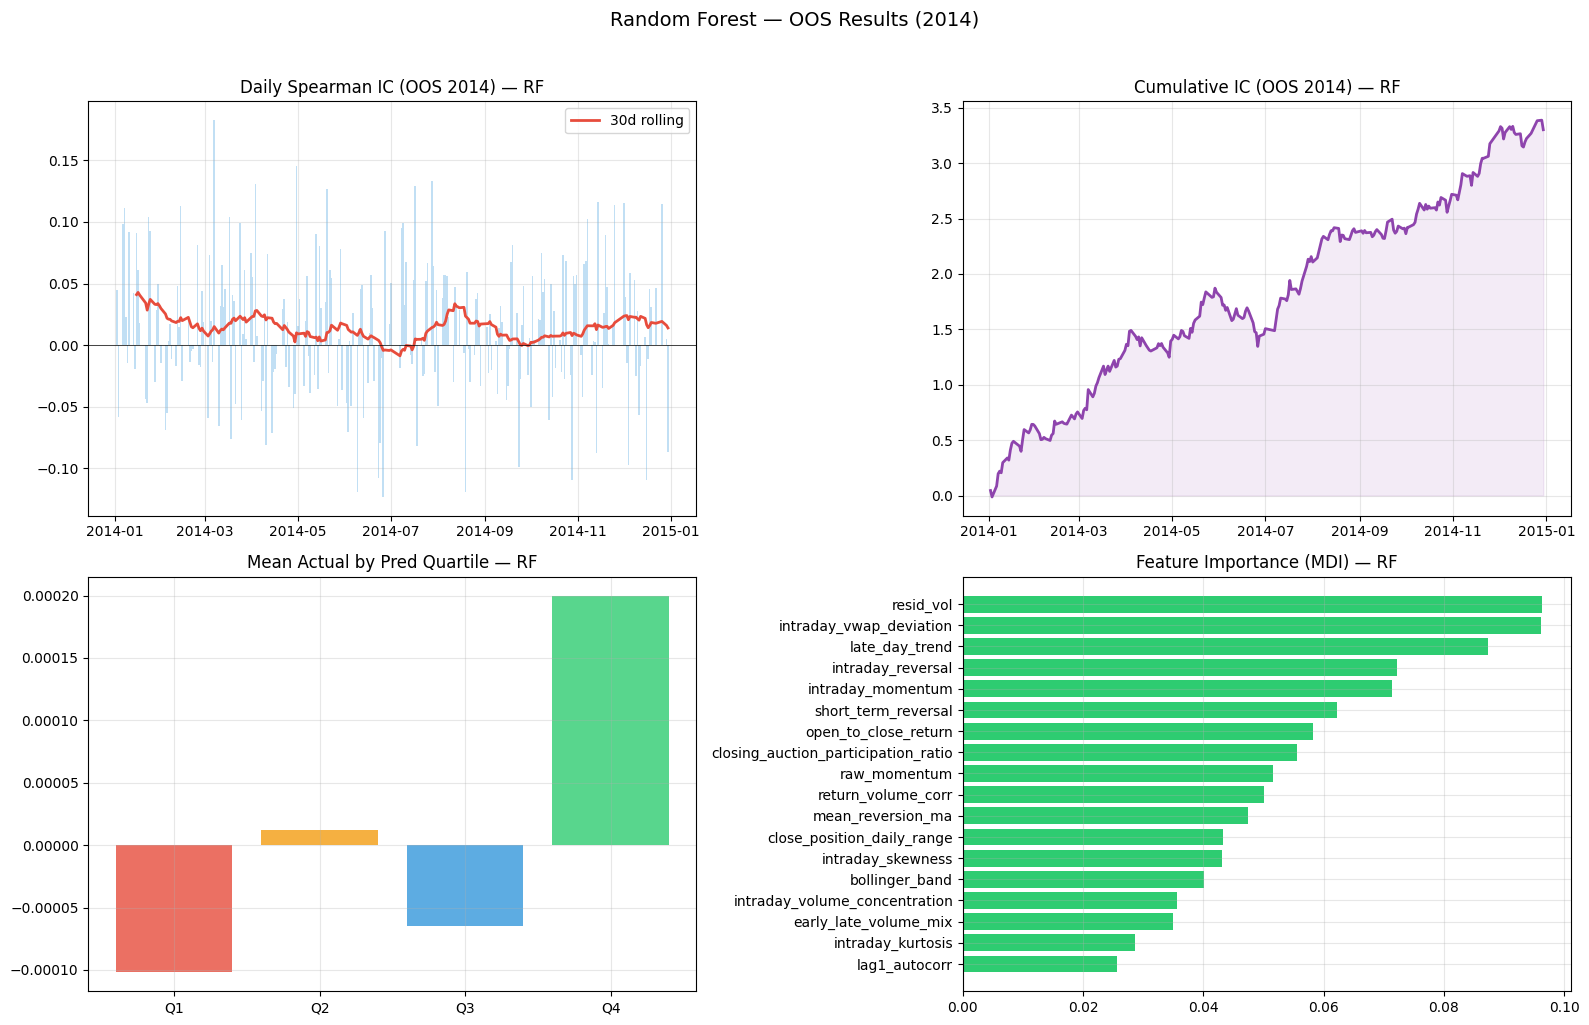

In [94]:
# ══════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Final Training (2010–2013) → OOS 2014
# Walk-forward skipped: train on full 2010-2013, evaluate on 2014.
# ══════════════════════════════════════════════════════════════════════════
import datetime

print(f"RF params (from HP search): {best_rf_params}\n")

print(f"[LOG] Fitting RF on all train (2010-2013): {len(X_full):,} rows...", flush=True)
t0 = time.time()
rf_final = RandomForestRegressor(**best_rf_params, n_jobs=-1, random_state=42)
rf_final.fit(X_full, y_full)
print(f"[LOG]   ...fit done in {time.time()-t0:.1f}s at {datetime.datetime.now().isoformat()}", flush=True)

y_oos_pred_rf = rf_final.predict(X_oos)

oos_r2_rf = r2_score(y_oos, y_oos_pred_rf)
oos_ic_rf = spearmanr(y_oos, y_oos_pred_rf).correlation

rf_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_rf[m]
    if len(y_d) > 10:
        rf_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
rf_oos_daily_df = pd.DataFrame(rf_oos_daily)

print(f"\n{'='*70}")
print(f"RF OOS 2014:  R²={oos_r2_rf:+.6f}  IC={oos_ic_rf:+.4f}  "
      f"Hit%={(rf_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")

# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.bar(rf_oos_daily_df["date"], rf_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#3498db", width=1)
roll = rf_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#e74c3c", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — RF"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cum = rf_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(rf_oos_daily_df["date"], cum, color="#8e44ad", lw=2)
ax.fill_between(rf_oos_daily_df["date"], 0, cum, alpha=0.1, color="#8e44ad")
ax.set_title("Cumulative IC (OOS 2014) — RF"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
pred_q = pd.qcut(y_oos_pred_rf, 4, labels=[f"Q{i+1}" for i in range(4)])
bm = pd.Series(y_oos).groupby(pred_q).mean()
ax.bar(bm.index, bm.values,
       color=["#e74c3c","#f39c12","#3498db","#2ecc71"], alpha=0.8)
ax.set_title("Mean Actual by Pred Quartile — RF"); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
fi = pd.DataFrame({"feature": feature_cols,
                    "importance": rf_final.feature_importances_})
fi = fi.sort_values("importance", ascending=True)
ax.barh(fi["feature"], fi["importance"], color="#2ecc71")
ax.set_title("Feature Importance (MDI) — RF"); ax.grid(True, alpha=0.3)

fig.suptitle("Random Forest — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

---

## Model 3: XGBoost

### Why XGBoost?

XGBoost adds **sequential boosting** on top of tree-based learning:
- Each new tree corrects residual errors from previous trees, achieving better bias-variance trade-off than bagging (RF).
- Built-in L2 regularization (`reg_lambda`) and learning rate shrinkage prevent overfitting.
- Gradient boosting is the dominant method in quant finance competitions (Kaggle, Two Sigma, etc.) for tabular data.
- Subsample + colsample per tree provide additional regularization similar to RF's feature bagging.

### HP Search Grid

| Hyperparameter | Values | Rationale |
|---------------|--------|-----------|
| `n_estimators` | 200, 500 | Number of boosting rounds |
| `max_depth` | 3, 5 | Shallow trees with boosting > deep trees |
| `learning_rate` | 0.01, 0.05 | Slow learning + more trees = better generalization |
| `subsample` | 0.7, 1.0 | Row subsampling for variance reduction |
| `colsample_bytree` | 0.5, 0.8 | Feature subsampling per tree |
| `reg_lambda` | 1.0 | L2 regularization (default, kept fixed) |

Same Purged 5-Fold CV → Walk-Forward → Final OOS pipeline.

In [69]:
# ══════════════════════════════════════════════════════════════════════════
# XGBOOST — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# Tunes reg_lambda (L2) AND decay_lambda (exponential sample-weight decay).
# decay_lambda controls how fast older training days are down-weighted:
#   sample_weight = exp(-decay_lambda * days_ago)
#   0.0  → uniform weights  |  0.005 → data ~200d ago weighted at exp(-1)≈0.37
# ══════════════════════════════════════════════════════════════════════════
from xgboost import XGBRegressor
from itertools import product as iterproduct

xgb_param_grid = {
    "n_estimators":  [100, 500],
    "max_depth":     [3, 5],
    "learning_rate": [0.01, 0.1],
    "reg_lambda":    [0.1, 1.0, 10.0],
    "decay_lambda":  [0.0, 0.005],  # sample-weight decay (NOT an XGB param)
}

xgb_combos = [
    dict(zip(xgb_param_grid.keys(), vals))
    for vals in iterproduct(*xgb_param_grid.values())
]
print(f"XGB HP grid: {len(xgb_combos)} combos × 5 folds = {len(xgb_combos)*5} fits\n")

# df_hp / X_hp / y_hp defined by RF HP search cell; redefine here for safety
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values


def make_sample_weights(dates, decay_lambda):
    """Exponential time-decay weights: exp(-decay_lambda * days_ago).
    days_ago is rank-based (trading days), not calendar days."""
    if decay_lambda == 0.0:
        return None  # uniform — skip overhead
    unique_sorted = np.sort(pd.DatetimeIndex(dates).unique())
    rank = {d: i for i, d in enumerate(unique_sorted)}
    max_rank = len(unique_sorted) - 1
    days_ago = np.array([max_rank - rank[d] for d in dates])
    return np.exp(-decay_lambda * days_ago)


xgb_hp_results = []
t_hp = time.time()

for combo in xgb_combos:
    decay_lambda = combo["decay_lambda"]
    xgb_params   = {k: v for k, v in combo.items() if k != "decay_lambda"}

    fold_ics, fold_r2s = [], []
    for tr_idx, va_idx in pkf.split(df_hp.index):
        sw = make_sample_weights(df_hp.index[tr_idx], decay_lambda)
        xgb_cv = XGBRegressor(**xgb_params, tree_method="hist",
                               n_jobs=1, random_state=42, verbosity=0)
        xgb_cv.fit(X_hp[tr_idx], y_hp[tr_idx], sample_weight=sw)
        y_pred = xgb_cv.predict(X_hp[va_idx])
        fold_ics.append(spearmanr(y_hp[va_idx], y_pred).correlation)
        fold_r2s.append(r2_score(y_hp[va_idx], y_pred))

    mean_ic = float(np.mean(fold_ics))
    xgb_hp_results.append({**combo, "mean_IC": mean_ic, "std_IC": float(np.std(fold_ics)),
                            "mean_R2": float(np.mean(fold_r2s))})
    print(f"  decay={decay_lambda}  {xgb_params}  →  "
          f"IC={mean_ic:+.4f} ± {np.std(fold_ics):.4f}  "
          f"R²={np.mean(fold_r2s):+.6f}", flush=True)

xgb_hp_df    = pd.DataFrame(xgb_hp_results)
best_xgb_row = xgb_hp_df.loc[xgb_hp_df["mean_IC"].idxmax()]
best_xgb_params = {k: best_xgb_row[k] for k in xgb_param_grid}
for k in ["n_estimators", "max_depth"]:
    best_xgb_params[k] = int(best_xgb_params[k])

print(f"\n{'='*70}")
print(f"BEST XGB params: {best_xgb_params}")
print(f"  mean IC = {best_xgb_row['mean_IC']:+.4f} ± {best_xgb_row['std_IC']:.4f}")
print(f"  mean R² = {best_xgb_row['mean_R2']:+.6f}")
print(f"  HP search completed in {time.time()-t_hp:.0f}s")
print(f"{'='*70}")


XGB HP grid: 48 combos × 5 folds = 240 fits



  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 0.1}  →  IC=+0.0198 ± 0.0063  R²=+0.000318
  decay=0.005  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 0.1}  →  IC=+0.0182 ± 0.0067  R²=+0.000286
  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 1.0}  →  IC=+0.0200 ± 0.0063  R²=+0.000325
  decay=0.005  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 1.0}  →  IC=+0.0183 ± 0.0068  R²=+0.000293
  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 10.0}  →  IC=+0.0199 ± 0.0061  R²=+0.000351
  decay=0.005  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'reg_lambda': 10.0}  →  IC=+0.0183 ± 0.0068  R²=+0.000303
  decay=0.0  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'reg_lambda': 0.1}  →  IC=+0.0240 ± 0.0056  R²=+0.000270
  decay=0.005  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, '

XGB params (from HP search): {'n_estimators': 500, 'max_depth': 3, 'learning_rate': np.float64(0.01), 'reg_lambda': np.float64(0.1), 'decay_lambda': np.float64(0.0)}

Fitting XGB on 431,755 rows...
Done in 33.4s

XGB OOS 2014:  R²=+0.000270  IC=+0.0169  Hit%=60.4%


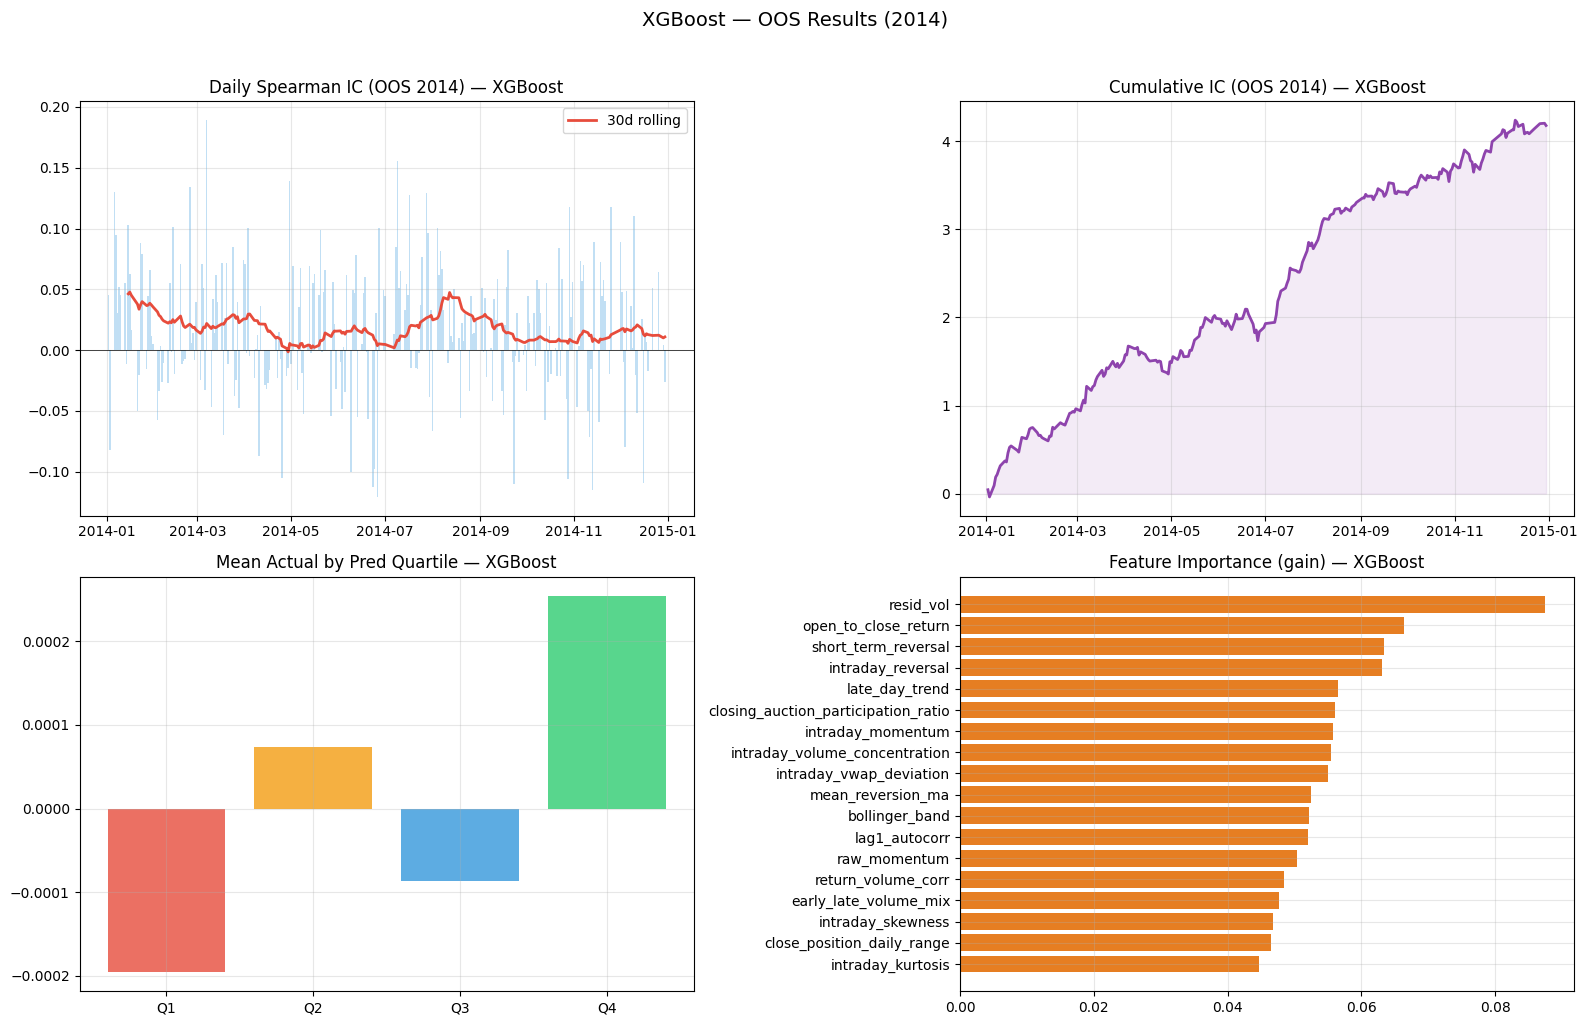

In [70]:
# ══════════════════════════════════════════════════════════════════════════
# XGBOOST — Final Training (2010–2013) → OOS 2014
# Walk-forward skipped: train on full 2010-2013, evaluate on 2014.
# (best_xgb_params includes tuned decay_lambda)
# ══════════════════════════════════════════════════════════════════════════

print(f"XGB params (from HP search): {best_xgb_params}\n")

best_decay_lambda   = best_xgb_params["decay_lambda"]
best_xgb_fit_params = {k: v for k, v in best_xgb_params.items() if k != "decay_lambda"}

sw_full   = make_sample_weights(df_train_norm.index, best_decay_lambda)
xgb_final = XGBRegressor(**best_xgb_fit_params, tree_method="hist",
                          n_jobs=1, random_state=42, verbosity=0)

print(f"Fitting XGB on {len(X_full):,} rows...", flush=True)
t0 = time.time()
xgb_final.fit(X_full, y_full, sample_weight=sw_full)
print(f"Done in {time.time()-t0:.1f}s", flush=True)

y_oos_pred_xgb = xgb_final.predict(X_oos)

oos_r2_xgb = r2_score(y_oos, y_oos_pred_xgb)
oos_ic_xgb = spearmanr(y_oos, y_oos_pred_xgb).correlation

xgb_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_xgb[m]
    if len(y_d) > 10:
        xgb_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
xgb_oos_daily_df = pd.DataFrame(xgb_oos_daily)

print(f"\n{'='*70}")
print(f"XGB OOS 2014:  R²={oos_r2_xgb:+.6f}  IC={oos_ic_xgb:+.4f}  "
      f"Hit%={(xgb_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")

# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.bar(xgb_oos_daily_df["date"], xgb_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#3498db", width=1)
roll = xgb_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#e74c3c", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — XGBoost"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cum = xgb_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(xgb_oos_daily_df["date"], cum, color="#8e44ad", lw=2)
ax.fill_between(xgb_oos_daily_df["date"], 0, cum, alpha=0.1, color="#8e44ad")
ax.set_title("Cumulative IC (OOS 2014) — XGBoost"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
pred_q = pd.qcut(y_oos_pred_xgb, 4, labels=[f"Q{i+1}" for i in range(4)])
bm = pd.Series(y_oos).groupby(pred_q).mean()
ax.bar(bm.index, bm.values,
       color=["#e74c3c","#f39c12","#3498db","#2ecc71"], alpha=0.8)
ax.set_title("Mean Actual by Pred Quartile — XGBoost"); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
fi_xgb = pd.DataFrame({"feature": feature_cols,
                        "importance": xgb_final.feature_importances_})
fi_xgb = fi_xgb.sort_values("importance", ascending=True)
ax.barh(fi_xgb["feature"], fi_xgb["importance"], color="#e67e22")
ax.set_title("Feature Importance (gain) — XGBoost"); ax.grid(True, alpha=0.3)

fig.suptitle("XGBoost — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


## Model : MLP (Multi-Layer Perceptron)
sklearn `MLPRegressor` — adam optimizer, early stopping, L2 regularization.  
HP search: 2 architectures × 2 α × 2 lr = 8 combos × 5 folds = 40 fits (Purged K-Fold, 2010–2012).  
Final fit on 2010–2013, evaluate on 2014 OOS.

In [71]:
# ══════════════════════════════════════════════════════════════════════════
# MLP — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# sklearn MLPRegressor with Adam optimizer and early stopping.
# Grid: 2 architectures × 2 L2 values × 2 learning rates = 8 combos × 5 folds
# ══════════════════════════════════════════════════════════════════════════
from sklearn.neural_network import MLPRegressor
from itertools import product as iterproduct

mlp_param_grid = {
    "hidden_layer_sizes": [(128, 64), (256, 128, 64)],
    "alpha":              [1e-4, 1e-3],         # L2 weight decay
    "learning_rate_init": [0.001, 0.005],
}

mlp_combos = [
    dict(zip(mlp_param_grid.keys(), vals))
    for vals in iterproduct(*mlp_param_grid.values())
]
print(f"MLP HP grid: {len(mlp_combos)} combos × 5 folds = {len(mlp_combos)*5} fits\n")

# df_hp / X_hp / y_hp / pkf defined in RF HP search cell; redefined here for safety
hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values
y_hp    = df_hp[target_col].values

mlp_hp_results = []
t_hp = time.time()

for combo in mlp_combos:
    fold_ics, fold_r2s = [], []
    for tr_idx, va_idx in pkf.split(df_hp.index):
        mlp_cv = MLPRegressor(
            **combo,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            solver="adam",
            random_state=42,
        )
        mlp_cv.fit(X_hp[tr_idx], y_hp[tr_idx])
        y_pred = mlp_cv.predict(X_hp[va_idx])
        fold_ics.append(spearmanr(y_hp[va_idx], y_pred).correlation)
        fold_r2s.append(r2_score(y_hp[va_idx], y_pred))

    mean_ic = float(np.mean(fold_ics))
    mlp_hp_results.append({
        "hidden_layer_sizes": str(combo["hidden_layer_sizes"]),
        "alpha":              combo["alpha"],
        "learning_rate_init": combo["learning_rate_init"],
        "mean_IC": mean_ic,
        "std_IC":  float(np.std(fold_ics)),
        "mean_R2": float(np.mean(fold_r2s)),
    })
    print(f"  {combo}  →  IC={mean_ic:+.4f} ± {np.std(fold_ics):.4f}  "
          f"R²={np.mean(fold_r2s):+.6f}", flush=True)

mlp_hp_df    = pd.DataFrame(mlp_hp_results)
best_mlp_row = mlp_hp_df.loc[mlp_hp_df["mean_IC"].idxmax()]
best_mlp_params = {
    "hidden_layer_sizes": eval(best_mlp_row["hidden_layer_sizes"]),
    "alpha":              float(best_mlp_row["alpha"]),
    "learning_rate_init": float(best_mlp_row["learning_rate_init"]),
}

print(f"\n{'='*70}")
print(f"BEST MLP params: {best_mlp_params}")
print(f"  mean IC = {best_mlp_row['mean_IC']:+.4f} ± {best_mlp_row['std_IC']:.4f}")
print(f"  mean R² = {best_mlp_row['mean_R2']:+.6f}")
print(f"  HP search completed in {time.time()-t_hp:.0f}s")
print(f"{'='*70}")

MLP HP grid: 8 combos × 5 folds = 40 fits

  {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}  →  IC=+0.0179 ± 0.0053  R²=+0.000194
  {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=+0.000019
  {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}  →  IC=+0.0191 ± 0.0065  R²=+0.000298
  {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=-0.000013
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}  →  IC=+0.0240 ± 0.0048  R²=+0.000520
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=-0.000313
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}  →  IC=+nan ± nan  R²=-0.000018
  {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.001, 'learning_rate_init': 0.005}  →  IC=+nan ± nan  R²=-0.000084

BEST MLP p

In [72]:
# ══════════════════════════════════════════════════════════════════════════
# MLP — Final Training (2010–2013) → OOS 2014
# ══════════════════════════════════════════════════════════════════════════
from sklearn.neural_network import MLPRegressor

print(f"MLP params (from HP search): {best_mlp_params}\n")

mlp_final = MLPRegressor(
    **best_mlp_params,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    solver="adam",
    random_state=42,
)

print(f"Fitting MLP on {len(X_full):,} rows...", flush=True)
t0 = time.time()
mlp_final.fit(X_full, y_full)
print(f"Done in {time.time()-t0:.1f}s  ({mlp_final.n_iter_} iterations)", flush=True)

y_oos_pred_mlp = mlp_final.predict(X_oos)

oos_r2_mlp = r2_score(y_oos, y_oos_pred_mlp)
oos_ic_mlp = spearmanr(y_oos, y_oos_pred_mlp).correlation

mlp_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_mlp[m]
    if len(y_d) > 10:
        mlp_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
mlp_oos_daily_df = pd.DataFrame(mlp_oos_daily)

print(f"\n{'='*70}")
print(f"MLP OOS 2014:  R²={oos_r2_mlp:+.6f}  IC={oos_ic_mlp:+.4f}  "
      f"Hit%={(mlp_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")



MLP params (from HP search): {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}

Fitting MLP on 431,755 rows...


Done in 368.7s  (30 iterations)

MLP OOS 2014:  R²=-0.000170  IC=+0.0108  Hit%=58.0%


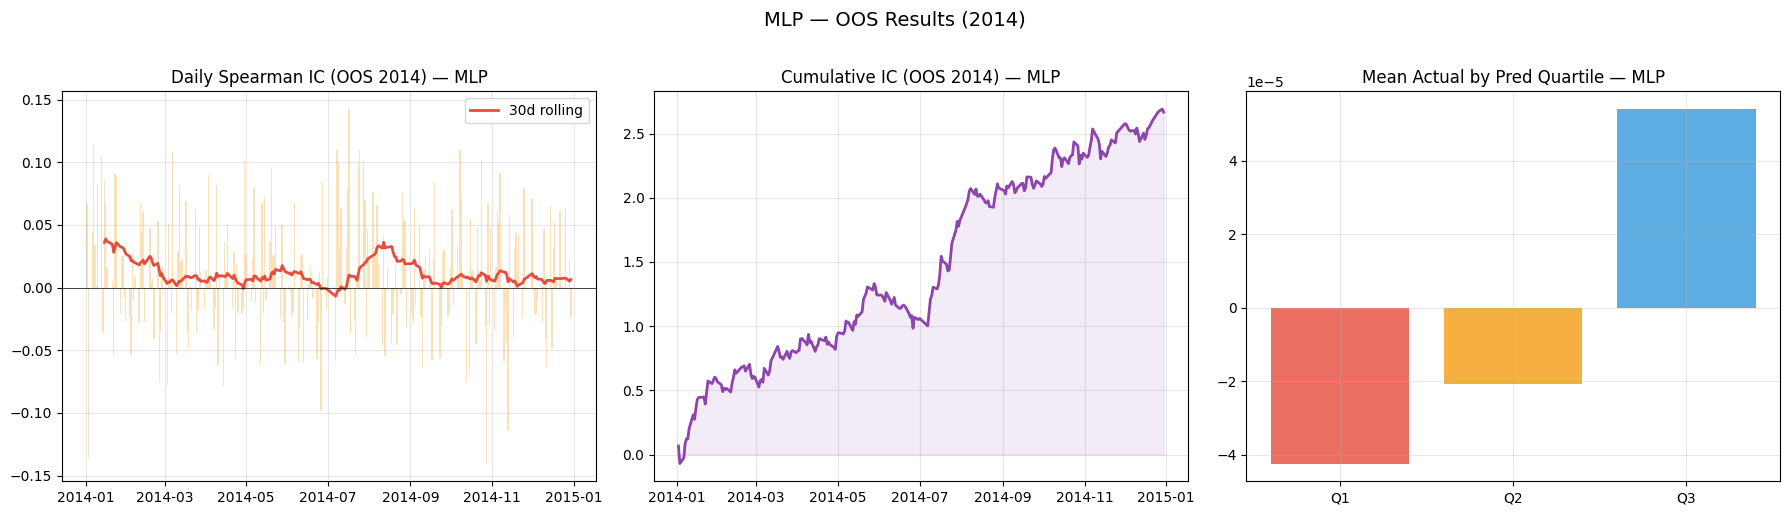

In [73]:
# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(mlp_oos_daily_df["date"], mlp_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#f39c12", width=1)
roll = mlp_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#e74c3c", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — MLP"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
cum = mlp_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(mlp_oos_daily_df["date"], cum, color="#8e44ad", lw=2)
ax.fill_between(mlp_oos_daily_df["date"], 0, cum, alpha=0.1, color="#8e44ad")
ax.set_title("Cumulative IC (OOS 2014) — MLP"); ax.grid(True, alpha=0.3)

ax = axes[2]
pred_q = pd.qcut(y_oos_pred_mlp, 4, duplicates="drop")
bm = pd.Series(y_oos).groupby(pred_q).mean()
colors = ["#e74c3c","#f39c12","#3498db","#2ecc71"][:len(bm)]
ax.bar(range(len(bm)), bm.values, color=colors, alpha=0.8)
ax.set_xticks(range(len(bm))); ax.set_xticklabels([f"Q{i+1}" for i in range(len(bm))])
ax.set_title("Mean Actual by Pred Quartile — MLP"); ax.grid(True, alpha=0.3)

fig.suptitle("MLP — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


MLP appears to be overfitting — let's try a **Residual MLP** with skip connections and BatchNorm for stronger regularization.

## Model: Residual MLP
PyTorch — residual blocks with BatchNorm + Dropout; trained with Adam and early stopping on validation IC.

In [67]:
# ══════════════════════════════════════════════════════════════════════════
# Residual MLP — Phase 1: HP Tuning via Purged K-Fold CV (2010–2012)
# Architecture: proj → N × (Linear→ReLU→Dropout→Linear + skip→ReLU)
# No BatchNorm — eliminates train/eval running-stats mismatch on OOS data.
# Grid: 2 hidden × 2 n_blocks × 2 dropouts = 8 combos × 5 folds = 40 fits
# ══════════════════════════════════════════════════════════════════════════
import sys
import torch
import torch.nn as nn


# ── Device ─────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")


# ── Model definition (no BatchNorm) ────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, d, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, d), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d, d),
        )
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.net(x))          # skip connection


class ResidualMLP(nn.Module):
    def __init__(self, in_dim, hidden, n_blocks, dropout):
        super().__init__()
        self.proj   = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head   = nn.Linear(hidden, 1)

    def forward(self, x):
        return self.head(self.blocks(self.proj(x))).squeeze(-1)


def train_resmlp(X_tr, y_tr, X_va, y_va, hidden, n_blocks, dropout,
                 lr=1e-3, max_epochs=60, patience=8, batch_size=4096,
                 stop_on="ic", device="cpu"):
    """
    stop_on='ic'   → early stop on val Spearman IC  (HP search: pick best architecture)
    stop_on='loss' → early stop on val MSE loss      (final training: avoid regime overfit)
    """
    model   = ResidualMLP(X_tr.shape[1], hidden, n_blocks, dropout).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    loss_fn = nn.MSELoss()

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)
    Xv = torch.tensor(X_va, dtype=torch.float32, device=device)
    yv = torch.tensor(y_va, dtype=torch.float32, device=device)
    n  = len(Xt)

    best_metric = np.inf if stop_on == "loss" else -np.inf
    best_state, wait = None, 0

    for _ in range(max_epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        for start in range(0, n, batch_size):
            idx = perm[start : start + batch_size]
            opt.zero_grad()
            loss_fn(model(Xt[idx]), yt[idx]).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pv_t = model(Xv)
            val_loss = float(loss_fn(pv_t, yv).item())
            pv = pv_t.cpu().numpy()
        val_ic = float(spearmanr(y_va, pv).correlation)

        metric = val_loss if stop_on == "loss" else val_ic
        improved = (metric < best_metric) if stop_on == "loss" else (metric > best_metric)

        if improved:
            best_metric = metric
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            wait        = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, val_ic   # always return IC for reporting


# ── HP grid ─────────────────────────────────────────────────────────────────
resmlp_param_grid = {
    "hidden":   [128, 256],
    "n_blocks": [2, 3],
    "dropout":  [0.2, 0.3],
}
resmlp_combos = [
    {"hidden": h, "n_blocks": nb, "dropout": dr}
    for h  in resmlp_param_grid["hidden"]
    for nb in resmlp_param_grid["n_blocks"]
    for dr in resmlp_param_grid["dropout"]
]
n_combos = len(resmlp_combos)
print(f"ResidualMLP HP grid: {n_combos} combos × 5 folds = {n_combos*5} fits")
sys.stdout.flush()

hp_mask = df_train_norm.index.year <= 2012
df_hp   = df_train_norm[hp_mask]
X_hp    = df_hp[feature_cols].values.astype(np.float32)
y_hp    = df_hp[target_col].values.astype(np.float32)

resmlp_hp_results = []
t_hp = time.time()

for c_idx, combo in enumerate(resmlp_combos):
    fold_ics = []
    t_combo  = time.time()
    for f_idx, (tr_idx, va_idx) in enumerate(pkf.split(df_hp.index)):
        _, ic = train_resmlp(X_hp[tr_idx], y_hp[tr_idx],
                             X_hp[va_idx],  y_hp[va_idx],
                             **combo, stop_on="ic", device=DEVICE)
        fold_ics.append(ic)
        print(f"  combo {c_idx+1}/{n_combos}  fold {f_idx+1}/5  IC={ic:+.4f}  "
              f"elapsed={time.time()-t_hp:.0f}s", flush=True)
        sys.stdout.flush()

    mean_ic = float(np.mean(fold_ics))
    resmlp_hp_results.append({**combo, "mean_IC": mean_ic, "std_IC": float(np.std(fold_ics))})
    print(f"  >>> combo {c_idx+1}/{n_combos} done: {combo}  "
          f"mean IC={mean_ic:+.4f} ± {np.std(fold_ics):.4f}  "
          f"combo_time={time.time()-t_combo:.0f}s", flush=True)
    sys.stdout.flush()

resmlp_hp_df    = pd.DataFrame(resmlp_hp_results)
best_resmlp_row = resmlp_hp_df.loc[resmlp_hp_df["mean_IC"].idxmax()]
best_resmlp_params = {
    "hidden":   int(best_resmlp_row["hidden"]),
    "n_blocks": int(best_resmlp_row["n_blocks"]),
    "dropout":  float(best_resmlp_row["dropout"]),
}

print(f"\n{'='*70}")
print(f"BEST ResidualMLP params: {best_resmlp_params}")
print(f"  mean IC = {best_resmlp_row['mean_IC']:+.4f} ± {best_resmlp_row['std_IC']:.4f}")
print(f"  Total HP search: {time.time()-t_hp:.0f}s")
print(f"{'='*70}")
sys.stdout.flush()

Device: mps
ResidualMLP HP grid: 8 combos × 5 folds = 40 fits
  combo 1/8  fold 1/5  IC=+0.0083  elapsed=27s
  combo 1/8  fold 2/5  IC=+0.0273  elapsed=83s
  combo 1/8  fold 3/5  IC=+0.0170  elapsed=120s
  combo 1/8  fold 4/5  IC=+0.0141  elapsed=155s
  combo 1/8  fold 5/5  IC=+0.0049  elapsed=192s
  >>> combo 1/8 done: {'hidden': 128, 'n_blocks': 2, 'dropout': 0.2}  mean IC=+0.0143 ± 0.0077  combo_time=192s
  combo 2/8  fold 1/5  IC=+0.0131  elapsed=274s
  combo 2/8  fold 2/5  IC=+0.0088  elapsed=363s
  combo 2/8  fold 3/5  IC=+0.0163  elapsed=421s
  combo 2/8  fold 4/5  IC=+0.0091  elapsed=475s
  combo 2/8  fold 5/5  IC=+0.0216  elapsed=544s
  >>> combo 2/8 done: {'hidden': 128, 'n_blocks': 2, 'dropout': 0.3}  mean IC=+0.0138 ± 0.0048  combo_time=352s
  combo 3/8  fold 1/5  IC=+0.0126  elapsed=640s
  combo 3/8  fold 2/5  IC=+0.0330  elapsed=752s
  combo 3/8  fold 3/5  IC=-0.0019  elapsed=781s
  combo 3/8  fold 4/5  IC=+0.0025  elapsed=807s
  combo 3/8  fold 5/5  IC=+0.0141  elapsed=8

In [68]:
# ══════════════════════════════════════════════════════════════════════════
# Residual MLP — Final Training (2010–2013) → OOS 2014
# Val split: last full year (2013) as held-out — same regime as walk-forward.
# Early stop on val LOSS (not IC) to avoid overfitting to one val period's rankings.
# ══════════════════════════════════════════════════════════════════════════
print(f"ResidualMLP params (from HP search): {best_resmlp_params}\n")
sys.stdout.flush()

X_full_f = X_full.astype(np.float32)
y_full_f = y_full.astype(np.float32)
X_oos_f  = X_oos.astype(np.float32)

# Use 2013 as val (purged temporal split, same logic as walk-forward)
train_mask_ft = df_train_norm.index.year < 2013
val_mask_ft   = df_train_norm.index.year == 2013
X_tr_f = df_train_norm.loc[train_mask_ft, feature_cols].values.astype(np.float32)
y_tr_f = df_train_norm.loc[train_mask_ft, target_col].values.astype(np.float32)
X_va_f = df_train_norm.loc[val_mask_ft, feature_cols].values.astype(np.float32)
y_va_f = df_train_norm.loc[val_mask_ft, target_col].values.astype(np.float32)

print(f"Train (2010–2012): {len(X_tr_f):,} rows  |  Val (2013): {len(X_va_f):,} rows")
print(f"Fitting ResidualMLP (stop_on=loss)...")
sys.stdout.flush()

t0 = time.time()
resmlp_final, best_val_ic = train_resmlp(
    X_tr_f, y_tr_f, X_va_f, y_va_f,
    **best_resmlp_params,
    max_epochs=100, patience=12, batch_size=4096,
    stop_on="loss", device=DEVICE,
)
print(f"Done in {time.time()-t0:.1f}s  (best val IC={best_val_ic:+.4f})")
sys.stdout.flush()

resmlp_final.eval()
with torch.no_grad():
    y_oos_pred_resmlp = resmlp_final(
        torch.tensor(X_oos_f, device=DEVICE)
    ).cpu().numpy()

oos_r2_resmlp = r2_score(y_oos, y_oos_pred_resmlp)
oos_ic_resmlp = spearmanr(y_oos, y_oos_pred_resmlp).correlation

resmlp_oos_daily = []
for date in sorted(df_test_norm.index.unique()):
    m = np.asarray(df_test_norm.index == date)
    y_d, p_d = y_oos[m], y_oos_pred_resmlp[m]
    if len(y_d) > 10:
        resmlp_oos_daily.append(dict(date=date,
            SpearmanIC=spearmanr(y_d, p_d).correlation,
            R2=r2_score(y_d, p_d)))
resmlp_oos_daily_df = pd.DataFrame(resmlp_oos_daily)

print(f"\n{'='*70}")
print(f"ResidualMLP OOS 2014:  R²={oos_r2_resmlp:+.6f}  IC={oos_ic_resmlp:+.4f}  "
      f"Hit%={(resmlp_oos_daily_df['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")
sys.stdout.flush()

ResidualMLP params (from HP search): {'hidden': 128, 'n_blocks': 2, 'dropout': 0.2}

Train (2010–2012): 309,605 rows  |  Val (2013): 122,150 rows
Fitting ResidualMLP (stop_on=loss)...
Done in 995.1s  (best val IC=+0.0206)

ResidualMLP OOS 2014:  R²=-0.000253  IC=+0.0167  Hit%=63.7%


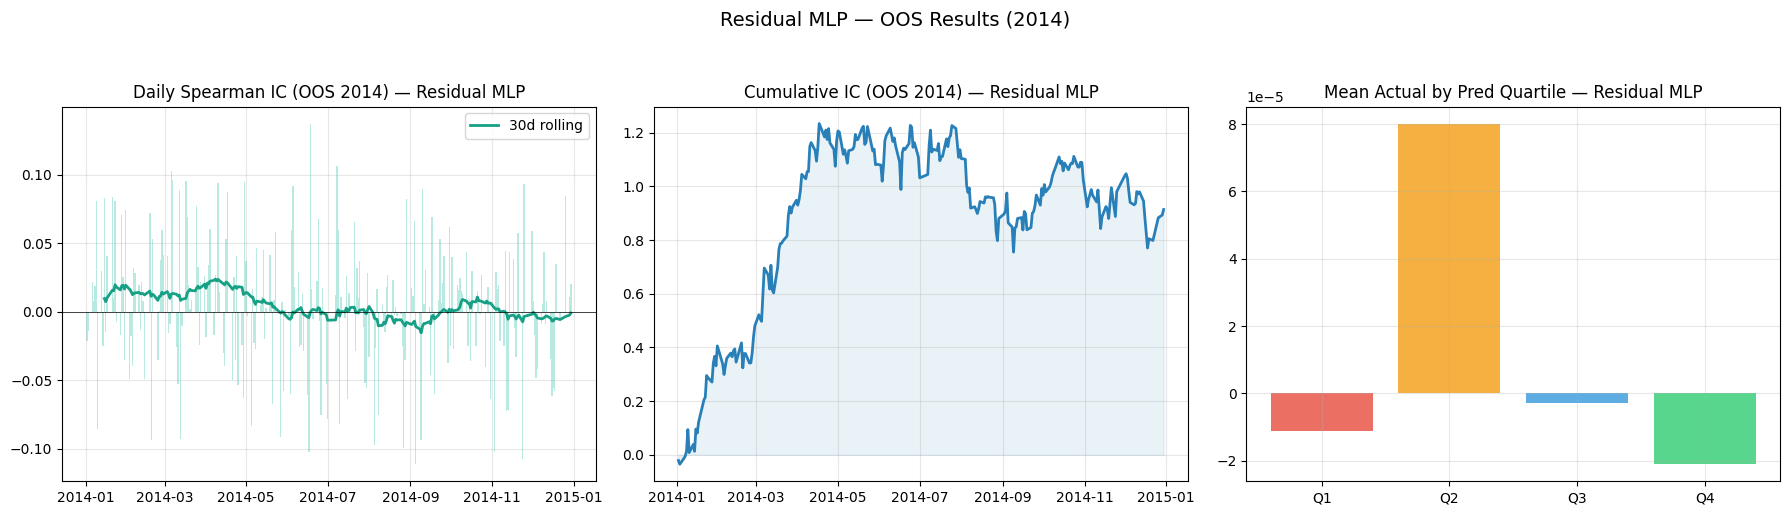

In [66]:
# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(resmlp_oos_daily_df["date"], resmlp_oos_daily_df["SpearmanIC"],
       alpha=0.3, color="#1abc9c", width=1)
roll = resmlp_oos_daily_df.set_index("date")["SpearmanIC"].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll.values, color="#16a085", lw=2, label="30d rolling")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Daily Spearman IC (OOS 2014) — Residual MLP"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
cum = resmlp_oos_daily_df["SpearmanIC"].cumsum()
ax.plot(resmlp_oos_daily_df["date"], cum, color="#2980b9", lw=2)
ax.fill_between(resmlp_oos_daily_df["date"], 0, cum, alpha=0.1, color="#2980b9")
ax.set_title("Cumulative IC (OOS 2014) — Residual MLP"); ax.grid(True, alpha=0.3)

ax = axes[2]
pred_q = pd.qcut(y_oos_pred_resmlp, 4, duplicates="drop")
bm = pd.Series(y_oos).groupby(pred_q).mean()
colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"][:len(bm)]
ax.bar(range(len(bm)), bm.values, color=colors, alpha=0.8)
ax.set_xticks(range(len(bm))); ax.set_xticklabels([f"Q{i+1}" for i in range(len(bm))])
ax.set_title("Mean Actual by Pred Quartile — Residual MLP"); ax.grid(True, alpha=0.3)

fig.suptitle("Residual MLP — OOS Results (2014)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

## Ensemble 

Ens-5 — Pairwise |Spearman ρ|:


,Ridge,RF,XGB,MLP,ResidMLP
Ridge,1.0000,0.7349,0.7535,0.8778,0.8597
RF,0.7349,1.0000,0.8519,0.7540,0.7486
XGB,0.7535,0.8519,1.0000,0.6963,0.7308
MLP,0.8778,0.7540,0.6963,1.0000,0.7988
ResidMLP,0.8597,0.7486,0.7308,0.7988,1.0000



Ens-5 — Diversity Weights:
  Ridge     : weight=0.197  avg |ρ|=0.806
  RF        : weight=0.201  avg |ρ|=0.772
  XGB       : weight=0.203  avg |ρ|=0.758
  MLP       : weight=0.200  avg |ρ|=0.782
  ResidMLP  : weight=0.200  avg |ρ|=0.784

Ens-3 (Ridge+RF+XGB) — Diversity Weights:
  Ridge     : weight=0.340  avg |ρ|=0.744
  RF        : weight=0.331  avg |ρ|=0.793
  XGB       : weight=0.329  avg |ρ|=0.803

Ens-5 (Div-Weighted, all 5): R²=+0.000047  IC=+0.0171  Hit%=62.0%
Ens-3 (Div-Weighted, top 3): R²=+0.000132  IC=+0.0173  Hit%=60.4%


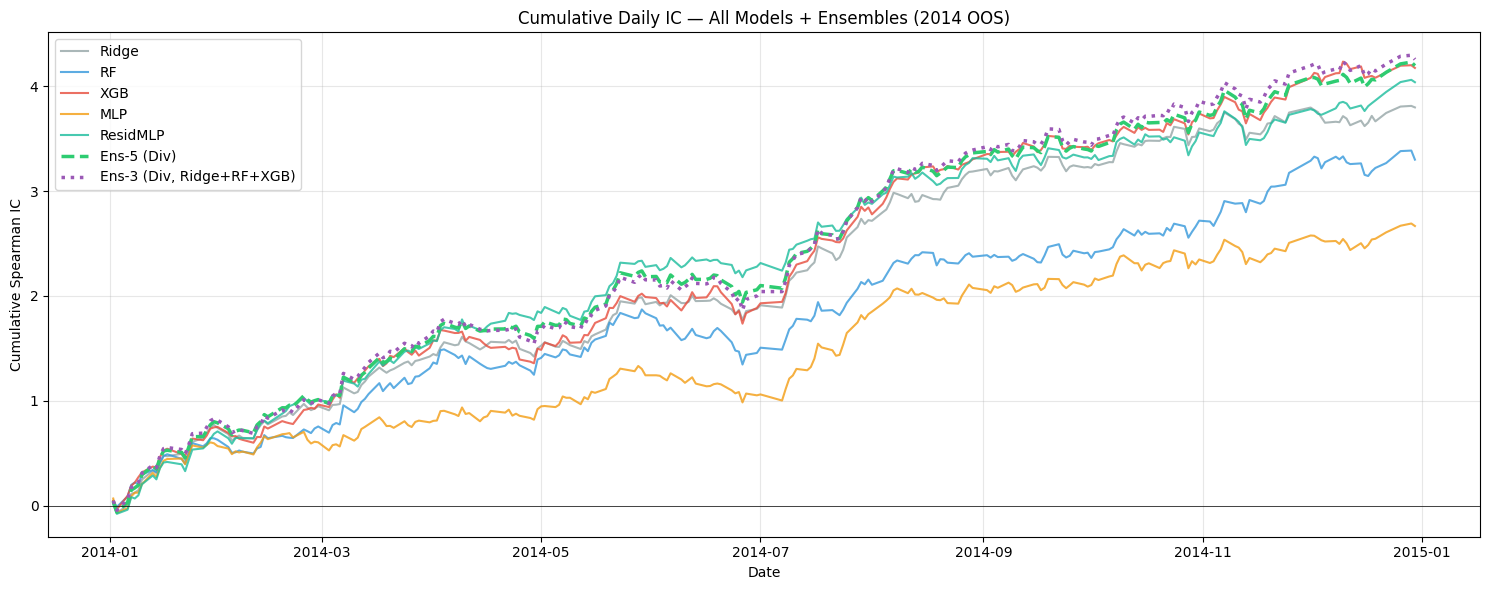

In [95]:
# ══════════════════════════════════════════════════════════════════════════
# ENSEMBLE
#   Ens-5 (Div-Weighted) : Ridge + RF + XGB + MLP + ResidualMLP
#   Ens-3 (Div-Weighted) : Ridge + RF + XGB only
# Both use diversity weights ∝ 1 / (1 + avg |Spearman ρ| with other members).
# ══════════════════════════════════════════════════════════════════════════

# ── Per-day IC helper ─────────────────────────────────────────────────────
def daily_ic_series(y_true, y_pred, dates):
    records = []
    for date in sorted(dates.unique()):
        m = np.asarray(dates == date)
        yd, pd_ = y_true[m], y_pred[m]
        if len(yd) > 10:
            records.append({"date": date,
                            "SpearmanIC": spearmanr(yd, pd_).correlation})
    return pd.DataFrame(records)


def diversity_weights(pred_matrix, names):
    """Compute diversity (inverse avg-correlation) weights for a set of model predictions."""
    n_m      = pred_matrix.shape[1]
    corr_mat = np.eye(n_m)
    for i in range(n_m):
        for j in range(i + 1, n_m):
            c = spearmanr(pred_matrix[:, i], pred_matrix[:, j]).correlation
            corr_mat[i, j] = corr_mat[j, i] = abs(c)
    avg_corr = np.array([(corr_mat[i].sum() - 1) / (n_m - 1) for i in range(n_m)])
    raw_w    = 1.0 / (1.0 + avg_corr)
    weights  = raw_w / raw_w.sum()
    corr_df  = pd.DataFrame(corr_mat, index=names, columns=names)
    return weights, avg_corr, corr_df


# ── Ens-5: all five models ─────────────────────────────────────────────────
preds_5 = {
    "Ridge":    y_oos_pred_ridge,
    "RF":       y_oos_pred_rf,
    "XGB":      y_oos_pred_xgb,
    "MLP":      y_oos_pred_mlp,
    "ResidMLP": y_oos_pred_resmlp,
}
names_5    = list(preds_5.keys())
mat_5      = np.column_stack(list(preds_5.values()))
w5, ac5, corr5_df = diversity_weights(mat_5, names_5)

print("Ens-5 — Pairwise |Spearman ρ|:")
display(corr5_df.round(4))
print("\nEns-5 — Diversity Weights:")
for name, w, ac in zip(names_5, w5, ac5):
    print(f"  {name:10s}: weight={w:.3f}  avg |ρ|={ac:.3f}")

y_oos_pred_ens5 = mat_5 @ w5


# ── Ens-3: Ridge + RF + XGB only ──────────────────────────────────────────
preds_3 = {k: preds_5[k] for k in ["Ridge", "RF", "XGB"]}
names_3  = list(preds_3.keys())
mat_3    = np.column_stack(list(preds_3.values()))
w3, ac3, corr3_df = diversity_weights(mat_3, names_3)

print("\nEns-3 (Ridge+RF+XGB) — Diversity Weights:")
for name, w, ac in zip(names_3, w3, ac3):
    print(f"  {name:10s}: weight={w:.3f}  avg |ρ|={ac:.3f}")

y_oos_pred_ens3 = mat_3 @ w3


# ── OOS metrics ───────────────────────────────────────────────────────────
ens5_daily = daily_ic_series(y_oos, y_oos_pred_ens5, df_test_norm.index)
ens3_daily = daily_ic_series(y_oos, y_oos_pred_ens3, df_test_norm.index)

oos_r2_ens5 = r2_score(y_oos, y_oos_pred_ens5)
oos_ic_ens5 = spearmanr(y_oos, y_oos_pred_ens5).correlation
oos_r2_ens3 = r2_score(y_oos, y_oos_pred_ens3)
oos_ic_ens3 = spearmanr(y_oos, y_oos_pred_ens3).correlation

print(f"\n{'='*70}")
print(f"Ens-5 (Div-Weighted, all 5): R²={oos_r2_ens5:+.6f}  IC={oos_ic_ens5:+.4f}  "
      f"Hit%={(ens5_daily['SpearmanIC']>0).mean()*100:.1f}%")
print(f"Ens-3 (Div-Weighted, top 3): R²={oos_r2_ens3:+.6f}  IC={oos_ic_ens3:+.4f}  "
      f"Hit%={(ens3_daily['SpearmanIC']>0).mean()*100:.1f}%")
print(f"{'='*70}")


# ── Cumulative IC — all models + both ensembles ────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
palette = {"Ridge": "#95a5a6", "RF": "#3498db", "XGB": "#e74c3c",
           "MLP": "#f39c12", "ResidMLP": "#1abc9c"}
for name, y_pred in preds_5.items():
    daily = daily_ic_series(y_oos, y_pred, df_test_norm.index)
    ax.plot(daily["date"], daily["SpearmanIC"].cumsum(),
            label=name, color=palette[name], linewidth=1.5, alpha=0.8)
ax.plot(ens5_daily["date"], ens5_daily["SpearmanIC"].cumsum(),
        label="Ens-5 (Div)", color="#2ecc71", linewidth=2.5, linestyle="--")
ax.plot(ens3_daily["date"], ens3_daily["SpearmanIC"].cumsum(),
        label="Ens-3 (Div, Ridge+RF+XGB)", color="#9b59b6", linewidth=2.5, linestyle=":")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Spearman IC")
ax.set_title("Cumulative Daily IC — All Models + Ensembles (2014 OOS)")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [96]:
# ══════════════════════════════════════════════════════════════════════════
# MODEL COMPARISON — Ridge + RF + XGBoost + MLP + ResidualMLP + Ensembles
# ══════════════════════════════════════════════════════════════════════════

# Ridge results hardcoded from earlier run
ridge_oos_r2  = -0.0001
ridge_oos_ic  =  0.0155
ridge_oos_hit =  61.6

comparison = pd.DataFrame([
    {
        "Model":         "Ridge",
        "Best HPs":      "α=1000",
        "OOS R² 2014":   ridge_oos_r2,
        "OOS IC 2014":   ridge_oos_ic,
        "OOS Hit% 2014": ridge_oos_hit,
    },
    {
        "Model":         "Random Forest",
        "Best HPs":      f"d={best_rf_params['max_depth']}, n={best_rf_params['n_estimators']}, leaf={best_rf_params['min_samples_leaf']}",
        "OOS R² 2014":   oos_r2_rf,
        "OOS IC 2014":   oos_ic_rf,
        "OOS Hit% 2014": (rf_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "XGBoost",
        "Best HPs":      f"d={best_xgb_params['max_depth']}, n={best_xgb_params['n_estimators']}, lr={best_xgb_params['learning_rate']}, λ={best_xgb_params['decay_lambda']}",
        "OOS R² 2014":   oos_r2_xgb,
        "OOS IC 2014":   oos_ic_xgb,
        "OOS Hit% 2014": (xgb_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "MLP",
        "Best HPs":      f"layers={best_mlp_params['hidden_layer_sizes']}, α={best_mlp_params['alpha']}, lr={best_mlp_params['learning_rate_init']}",
        "OOS R² 2014":   oos_r2_mlp,
        "OOS IC 2014":   oos_ic_mlp,
        "OOS Hit% 2014": (mlp_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "Residual MLP",
        "Best HPs":      f"hidden={best_resmlp_params['hidden']}, blocks={best_resmlp_params['n_blocks']}, drop={best_resmlp_params['dropout']}",
        "OOS R² 2014":   oos_r2_resmlp,
        "OOS IC 2014":   oos_ic_resmlp,
        "OOS Hit% 2014": (resmlp_oos_daily_df["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "Ens-5 (Div-Weighted)",
        "Best HPs":      f"w={dict(zip(names_5, w5.round(3)))}",
        "OOS R² 2014":   oos_r2_ens5,
        "OOS IC 2014":   oos_ic_ens5,
        "OOS Hit% 2014": (ens5_daily["SpearmanIC"] > 0).mean() * 100,
    },
    {
        "Model":         "Ens-3 (Div-Weighted, Ridge+RF+XGB)",
        "Best HPs":      f"w={dict(zip(names_3, w3.round(3)))}",
        "OOS R² 2014":   oos_r2_ens3,
        "OOS IC 2014":   oos_ic_ens3,
        "OOS Hit% 2014": (ens3_daily["SpearmanIC"] > 0).mean() * 100,
    },
])

print(f"{'='*90}")
print(f"{'MODEL COMPARISON — ALL MODELS + ENSEMBLES':^90}")
print(f"{'='*90}")
display(comparison.set_index("Model").round(4))

best_ic  = comparison.loc[comparison["OOS IC 2014"].idxmax(),    "Model"]
best_hit = comparison.loc[comparison["OOS Hit% 2014"].idxmax(), "Model"]
print(f"\nBest OOS IC:    {best_ic}")
print(f"Best OOS Hit%:  {best_hit}")

                        MODEL COMPARISON — ALL MODELS + ENSEMBLES                         


,Best HPs,OOS R² 2014,OOS IC 2014,OOS Hit% 2014
Model,,,,
Ridge,α=1000,-0.0001,0.0155,61.6000
Random Forest,"d=5, n=200, leaf=50",0.0000,0.0134,58.7755
XGBoost,"d=3, n=500, lr=0.01, λ=0.0",0.0003,0.0169,60.4082
MLP,"layers=(256, 128, 64), α=0.0001, lr=0.001",-0.0002,0.0108,57.9592
Residual MLP,"hidden=128, blocks=2, drop=0.2",-0.0003,0.0167,63.6735
Ens-5 (Div-Weighted),"w={'Ridge': np.float64(0.197), 'RF': np.float6...",0.0000,0.0171,62.0408
"Ens-3 (Div-Weighted, Ridge+RF+XGB)","w={'Ridge': np.float64(0.34), 'RF': np.float64...",0.0001,0.0173,60.4082



Best OOS IC:    Ens-3 (Div-Weighted, Ridge+RF+XGB)
Best OOS Hit%:  Residual MLP


### **Observations** :

Ensemble with the base models seem to be superior, probably because we dont have enough data to train neural nets(or they are just inferior in low signal to noise ratio environments), even residual MLP couldn't beat our base models(not surprising!)

## FINAL MODEL FIT AND OOS TESTING ON 2015

---

## True OOS Evaluation — 2015

Refit all five models on the **full 2010–2014 training set** (best HPs unchanged) and evaluate on 2015.  
The 2015 features are transformed with the **exact same clipping and normalization params** computed from 2010–2013 training data — no look-ahead.

In [99]:
pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [100]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — Load & transform 2015 features
#
# Transformation order (must match training pipeline exactly):
#   1. build raw features from oos_data (cached → features_raw_oos2015.parquet)
#   2. clean_feature_panel  — NaN fill / warmup cutoff (same warmup_cutoff as train)
#   3. 5-MAD clipping       — using saved clip_params.joblib (from 2010–2013 train)
#   4. Stage 1 z-score      — subtract train mean / divide by train std (norm_params.joblib)
#   5. Stage 2 xsect rank   — per-date rank → N(0,1) inverse CDF (no stored params needed)
# ══════════════════════════════════════════════════════════════════════════
import sys, warnings, time, joblib
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import norm as sp_norm
warnings.filterwarnings("ignore")

_project_root = Path.cwd().parent
for p in [str(_project_root), str(_project_root / "submission_files")]:
    if p not in sys.path:
        sys.path.insert(0, p)
from src.config import FEATURE_DATA_DIR, ROOT_DIR
from feature_src.nan_handler import clean_feature_panel

OOS_DATA_DIR   = ROOT_DIR / "oos_data"
CACHE_RAW_2015 = FEATURE_DATA_DIR / "feature_together" / "features_raw_oos2015.parquet"
CACHE_NORM_2015 = FEATURE_DATA_DIR / "feature_together" / "features_norm_oos2015.parquet"

# ── 1a. Build or load raw 2015 features ───────────────────────────────────
if CACHE_NORM_2015.exists():
    print("✓ Cached normalized 2015 features found — loading directly.")
    df_2015_norm = pd.read_parquet(CACHE_NORM_2015)
else:
    if CACHE_RAW_2015.exists():
        print("✓ Cached raw 2015 features found — loading.")
        df_raw_2015 = pd.read_parquet(CACHE_RAW_2015)
    else:
        print("Building 2015 raw features from oos_data (this takes ~5-10 min)...")
        from main import load_intraday_data
        from feature_src.daily_data_loader import load_daily_data
        from feature_src.feature_engineering import build_daily_dataset
        import json, tempfile, os

        # Strip MAD filter from config (same as done for raw train/test)
        config_path = _project_root / "submission_files" / "feature_src" / "features_config.json"
        with open(config_path) as _f:
            _cfg = json.load(_f)
        for _section in ("intraday_features", "daily_features"):
            for _feat in _cfg.get(_section, []):
                _feat.pop("mad_filter", None)
        _tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False)
        json.dump(_cfg, _tmp, indent=2); _tmp.close()

        all_data_oos = load_intraday_data(OOS_DATA_DIR / "intraday_data", include_test=True)
        daily_data_oos = load_daily_data(daily_dir=OOS_DATA_DIR / "daily_data")
        df_raw_all = build_daily_dataset(
            all_data=all_data_oos,
            feature_config_path=_tmp.name,
            daily_data=daily_data_oos,
            include_target=True,
        )
        os.unlink(_tmp.name)

        # Keep only 2015
        df_raw_2015 = df_raw_all[pd.to_datetime(df_raw_all.index).year == 2015].copy()
        df_raw_2015.to_parquet(CACHE_RAW_2015)
        print(f"✓ Cached raw 2015 features ({len(df_raw_2015):,} rows) → {CACHE_RAW_2015.name}")

    # ── 1b. NaN cleaning ──────────────────────────────────────────────────
    # warmup_cutoff = same first date as training set (already past warmup)
    train_cutoff = df_train_norm.index.min()
    df_2015_clean = clean_feature_panel(
        df_raw_2015, drop_target_nan=True, warmup_cutoff=train_cutoff, verbose=False
    )
    print(f"After NaN clean: {len(df_2015_clean):,} rows")

    # ── 1c. 5-MAD clipping with SAVED train params ────────────────────────
    clip_params = joblib.load(FEATURE_DATA_DIR / "clip_params.joblib")
    df_2015_clipped = df_2015_clean.copy()
    for col, p in clip_params["features"].items():
        if col in df_2015_clipped.columns:
            df_2015_clipped[col] = df_2015_clipped[col].clip(lower=p["clip_lo"], upper=p["clip_hi"])
    # Clip target with saved target params (for evaluation consistency; not used in training)
    tp = clip_params["target"]
    df_2015_clipped["target_variable"] = df_2015_clipped["target_variable"].clip(
        lower=tp["clip_lo"], upper=tp["clip_hi"]
    )

    # ── 1d. Stage 1: z-score with SAVED train mean/std ────────────────────
    norm_params_saved = joblib.load(FEATURE_DATA_DIR / "norm_params.joblib")
    stage1 = norm_params_saved["stage1_params"]
    df_2015_s1 = df_2015_clipped.copy()
    for col in feature_cols:
        mu, std = stage1[col]["mean"], stage1[col]["std"]
        df_2015_s1[col] = (df_2015_s1[col] - mu) / std if std > 1e-12 else 0.0

    # ── 1e. Stage 2: cross-sectional rank-norm (per-date, on 2015 itself) ─
    def cross_sectional_rank_norm(df, cols):
        df_out = df.copy()
        for col in cols:
            ranked  = df_out.groupby(df_out.index)[col].rank(method="average", na_option="keep")
            counts  = df_out.groupby(df_out.index)[col].transform("count")
            df_out[col] = sp_norm.ppf((ranked - 0.5) / counts)
        return df_out

    df_2015_norm = cross_sectional_rank_norm(df_2015_s1, feature_cols)
    df_2015_norm.to_parquet(CACHE_NORM_2015)
    print(f"✓ Cached normalized 2015 features → {CACHE_NORM_2015.name}")

print(f"\n✓ 2015 data ready: {df_2015_norm.shape}  "
      f"({df_2015_norm.index.min().date()} → {df_2015_norm.index.max().date()})")
sys.stdout.flush()

X_2015 = df_2015_norm[feature_cols].values
y_2015 = df_2015_norm[target_col].values

Building 2015 raw features from oos_data (this takes ~5-10 min)...
Total files: 1510
Using all files (train + test): 1510


Loading intraday data: 100%|██████████| 1510/1510 [00:25<00:00, 58.31it/s]


Concatenating data...
Converting cumulative values to increments...
Dropping Id with NaN within trading day...
Removing timestamps where all stocks have zero raw return...
Finished processing intraday data.
Final intraday dataset shape: (19481206, 7)


Building daily dataset: 100%|██████████| 6/6 [03:46<00:00, 37.73s/step, MAD filter]       


✓ Cached raw 2015 features (125,832 rows) → features_raw_oos2015.parquet
After NaN clean: 122,893 rows
✓ Cached normalized 2015 features → features_norm_oos2015.parquet

✓ 2015 data ready: (122893, 20)  (2015-01-02 → 2015-12-30)


In [101]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — Refit all 5 models on 2010–2014 (best HPs, no tuning)
# df_train_full = df_train_norm (2010–2013) + df_test_norm (2014)
# ResidualMLP: train on 2010–2013, val on 2014 for early stopping
# ══════════════════════════════════════════════════════════════════════════
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import xgboost as xgb
import torch

# ── Full 2010–2014 training set ────────────────────────────────────────────
df_train_full = pd.concat([df_train_norm, df_test_norm]).sort_index()
X_tr_full = df_train_full[feature_cols].values
y_tr_full = df_train_full[target_col].values
print(f"2010–2014 training set: {df_train_full.shape}  "
      f"({df_train_full.index.min().date()} → {df_train_full.index.max().date()})")

# ── Ridge ──────────────────────────────────────────────────────────────────
print("\nFitting Ridge...", flush=True); t0 = time.time()
ridge_2015 = Ridge(alpha=1000).fit(X_tr_full, y_tr_full)
print(f"  Done in {time.time()-t0:.1f}s")

# ── Random Forest ──────────────────────────────────────────────────────────
print("Fitting RF...", flush=True); t0 = time.time()
rf_2015 = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_2015.fit(X_tr_full, y_tr_full)
print(f"  Done in {time.time()-t0:.1f}s")

# ── XGBoost ────────────────────────────────────────────────────────────────
print("Fitting XGBoost...", flush=True); t0 = time.time()
xgb_2015 = xgb.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1,
                              verbosity=0, eval_metric="rmse")
xgb_2015.fit(X_tr_full, y_tr_full)
print(f"  Done in {time.time()-t0:.1f}s")

# ── sklearn MLP ────────────────────────────────────────────────────────────
print("Fitting MLP...", flush=True); t0 = time.time()
mlp_2015 = MLPRegressor(**best_mlp_params, max_iter=300, early_stopping=True,
                         validation_fraction=0.1, n_iter_no_change=15,
                         solver="adam", random_state=42)
mlp_2015.fit(X_tr_full, y_tr_full)
print(f"  Done in {time.time()-t0:.1f}s  ({mlp_2015.n_iter_} iters)")

# ── Residual MLP — train on 2010–2013, val on 2014 (temporal split) ───────
print("Fitting ResidualMLP...", flush=True); t0 = time.time()
_tr_mask = df_train_full.index.year < 2014
_va_mask  = df_train_full.index.year == 2014
X_tr_nn = df_train_full.loc[_tr_mask, feature_cols].values.astype(np.float32)
y_tr_nn = df_train_full.loc[_tr_mask, target_col].values.astype(np.float32)
X_va_nn = df_train_full.loc[_va_mask, feature_cols].values.astype(np.float32)
y_va_nn = df_train_full.loc[_va_mask, target_col].values.astype(np.float32)

resmlp_2015, _val_ic = train_resmlp(
    X_tr_nn, y_tr_nn, X_va_nn, y_va_nn,
    **best_resmlp_params,
    max_epochs=100, patience=12, batch_size=4096,
    stop_on="loss", device=DEVICE,
)
print(f"  Done in {time.time()-t0:.1f}s  (val IC={_val_ic:+.4f})")
sys.stdout.flush()
print("\n✓ All models fitted on 2010–2014.")

2010–2014 training set: (553621, 20)  (2010-06-25 → 2014-12-30)

Fitting Ridge...
  Done in 0.1s
Fitting RF...
  Done in 30.0s
Fitting XGBoost...
  Done in 4.2s
Fitting MLP...
  Done in 68.0s  (26 iters)
Fitting ResidualMLP...
  Done in 34.9s  (val IC=+0.0065)

✓ All models fitted on 2010–2014.


  Ridge                           R²=-0.000016  IC=+0.0086  Hit%=55.5%
  RF                              R²=+0.000204  IC=+0.0103  Hit%=59.5%
  XGB                             R²=-0.000300  IC=+0.0084  Hit%=55.5%
  MLP                             R²=+0.000036  IC=+0.0058  Hit%=57.5%
  ResidMLP                        R²=-0.001507  IC=+0.0068  Hit%=54.7%
  Ens-5 (Div)                     R²=+0.000052  IC=+0.0091  Hit%=56.7%
  Ens-3 (Div, Ridge+RF+XGB)       R²=+0.000094  IC=+0.0092  Hit%=58.7%

                        2015 TRUE OOS RESULTS                         


,OOS R² 2015,OOS IC 2015,OOS Hit% 2015
Model,,,
Ridge,-0.0000,0.0086,55.4656
RF,0.0002,0.0103,59.5142
XGB,-0.0003,0.0084,55.4656
MLP,0.0000,0.0058,57.4899
ResidMLP,-0.0015,0.0068,54.6559
Ens-5 (Div),0.0001,0.0091,56.6802
"Ens-3 (Div, Ridge+RF+XGB)",0.0001,0.0092,58.7045



Best OOS IC 2015:   RF
Best OOS Hit% 2015: RF


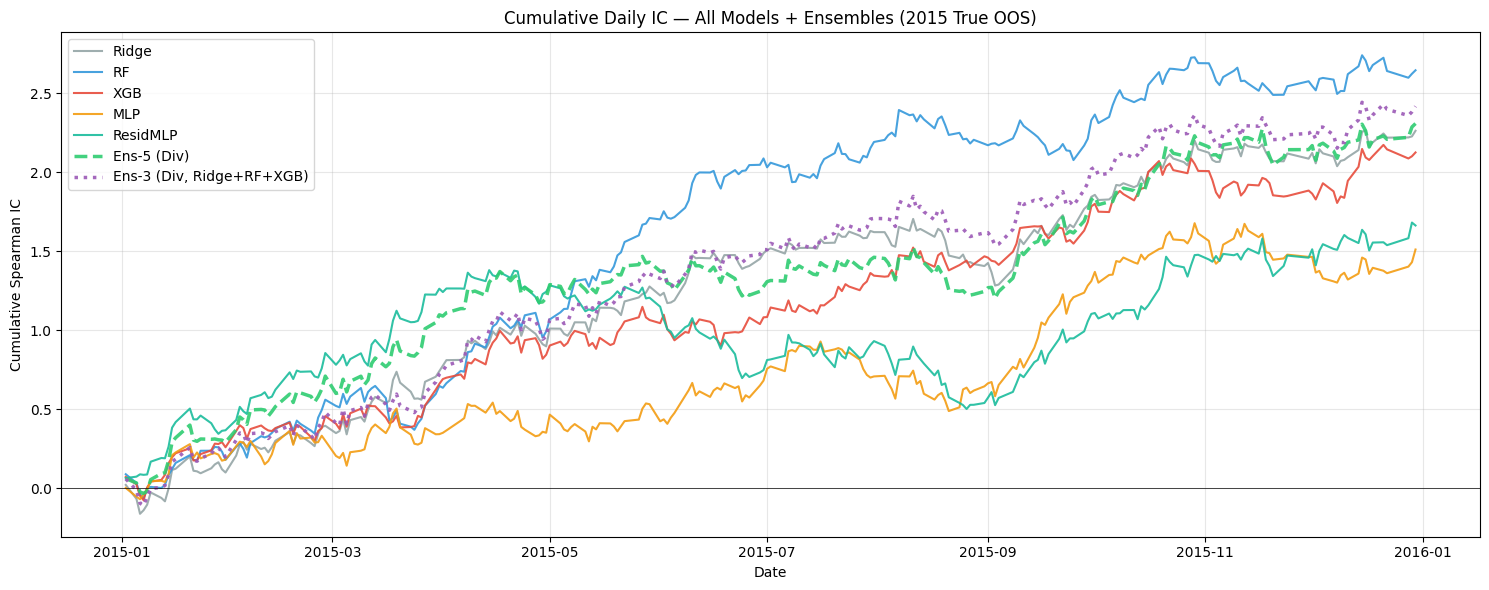

In [102]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — OOS 2015 predictions, ensembles, metrics & comparison
# ══════════════════════════════════════════════════════════════════════════

# ── Predictions ────────────────────────────────────────────────────────────
resmlp_2015.eval()
with torch.no_grad():
    _resmlp_pred = resmlp_2015(
        torch.tensor(X_2015.astype(np.float32), device=DEVICE)
    ).cpu().numpy()

preds_2015 = {
    "Ridge":    ridge_2015.predict(X_2015),
    "RF":       rf_2015.predict(X_2015),
    "XGB":      xgb_2015.predict(X_2015),
    "MLP":      mlp_2015.predict(X_2015),
    "ResidMLP": _resmlp_pred,
}

# ── Ensembles ──────────────────────────────────────────────────────────────
mat_2015_5 = np.column_stack(list(preds_2015.values()))
w2015_5, _, _ = diversity_weights(mat_2015_5, list(preds_2015.keys()))
pred_ens5_2015 = mat_2015_5 @ w2015_5

mat_2015_3 = np.column_stack([preds_2015[k] for k in ["Ridge", "RF", "XGB"]])
w2015_3, _, _ = diversity_weights(mat_2015_3, ["Ridge", "RF", "XGB"])
pred_ens3_2015 = mat_2015_3 @ w2015_3

# ── Per-day IC helper (reuse from ensemble cell) ───────────────────────────
def _daily_ic(y_true, y_pred, dates):
    recs = []
    for d in sorted(dates.unique()):
        m = np.asarray(dates == d)
        yd, pd_ = y_true[m], y_pred[m]
        if len(yd) > 10:
            recs.append({"date": d, "SpearmanIC": spearmanr(yd, pd_).correlation})
    return pd.DataFrame(recs)

# ── OOS 2015 metrics ────────────────────────────────────────────────────────
rows_2015 = []
all_preds_2015 = {**preds_2015,
                  "Ens-5 (Div)":              pred_ens5_2015,
                  "Ens-3 (Div, Ridge+RF+XGB)": pred_ens3_2015}

for name, pred in all_preds_2015.items():
    daily = _daily_ic(y_2015, pred, df_2015_norm.index)
    rows_2015.append({
        "Model":         name,
        "OOS R² 2015":   r2_score(y_2015, pred),
        "OOS IC 2015":   spearmanr(y_2015, pred).correlation,
        "OOS Hit% 2015": (daily["SpearmanIC"] > 0).mean() * 100,
    })
    print(f"  {name:30s}  R²={rows_2015[-1]['OOS R² 2015']:+.6f}  "
          f"IC={rows_2015[-1]['OOS IC 2015']:+.4f}  "
          f"Hit%={rows_2015[-1]['OOS Hit% 2015']:.1f}%", flush=True)

df_2015_results = pd.DataFrame(rows_2015).set_index("Model")

print(f"\n{'='*70}")
print(f"{'2015 TRUE OOS RESULTS':^70}")
print(f"{'='*70}")
display(df_2015_results.round(4))
best_ic_2015 = df_2015_results["OOS IC 2015"].idxmax()
print(f"\nBest OOS IC 2015:   {best_ic_2015}")
print(f"Best OOS Hit% 2015: {df_2015_results['OOS Hit% 2015'].idxmax()}")

# ── Cumulative IC plot — 2015 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
palette_2015 = {"Ridge": "#95a5a6", "RF": "#3498db", "XGB": "#e74c3c",
                "MLP": "#f39c12", "ResidMLP": "#1abc9c",
                "Ens-5 (Div)": "#2ecc71", "Ens-3 (Div, Ridge+RF+XGB)": "#9b59b6"}
ls_map = {**{k: "-" for k in preds_2015},
          "Ens-5 (Div)": "--", "Ens-3 (Div, Ridge+RF+XGB)": ":"}
lw_map = {**{k: 1.5 for k in preds_2015},
          "Ens-5 (Div)": 2.5, "Ens-3 (Div, Ridge+RF+XGB)": 2.5}

for name, pred in all_preds_2015.items():
    daily = _daily_ic(y_2015, pred, df_2015_norm.index)
    ax.plot(daily["date"], daily["SpearmanIC"].cumsum(),
            label=name, color=palette_2015[name],
            linewidth=lw_map[name], linestyle=ls_map[name], alpha=0.9)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Spearman IC")
ax.set_title("Cumulative Daily IC — All Models + Ensembles (2015 True OOS)")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()